In [23]:
# ============================================================
# Notebook 01: Data Quality Assessment
# پروژه: سیستم هوشمند تحلیل و پیش‌بینی هواشناسی
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# تنظیمات
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ============================================================
# ۱. بارگذاری داده خام
# ============================================================
file_path = r"C:\Users\mosal\Desktop\Meteorology\Meteorology For Report\Meteorology - Amin.xlsx"
df = pd.read_excel(file_path, sheet_name='Tabelle1')
df.columns = df.columns.str.strip()

print("="*80)
print("۱. اطلاعات کلی دیتاست")
print("="*80)
print(f"ابعاد: {df.shape[0]:,} ردیف × {df.shape[1]} ستون")
print(f"بازه Date_M: {df['Date_M'].min()} تا {df['Date_M'].max()}")
print(f"\nستون‌ها:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col} ({df[col].dtype})")

۱. اطلاعات کلی دیتاست
ابعاد: 3,065 ردیف × 29 ستون
بازه Date_M: 2018-01-01 00:00:00 تا 2026-05-23 00:00:00

ستون‌ها:
   1. Date_M (datetime64[ns])
   2. Date_S (object)
   3. Volume_m3 (float64)
   4. Surface_Area_m2 (float64)
   5. Water Level(m) (float64)
   6. Meter_Reading_m3 (float64)
   7. Wind_dir_Min (float64)
   8. Wind_dir_Max (float64)
   9. Wind_dir_Avg (float64)
  10. Wind_Kmh_Min (float64)
  11. Wind_Kmh_Max (float64)
  12. Wind_Kmh_Avg (float64)
  13. Humidity_Min (float64)
  14. Humidity_Max (float64)
  15. Humidity_Avg (float64)
  16. Temperature_Min (float64)
  17. Temperature_Max (float64)
  18. Temperature_Avg (float64)
  19. Evapo_mm_Min (float64)
  20. Evapo_mm_Max (float64)
  21. Evapo_mm_Avg (float64)
  22. Baro_KPa_Min (float64)
  23. Baro_KPa_Max (float64)
  24. Baro_KPa_Avg (float64)
  25. Watts_m2_Min (float64)
  26. Watts_m2_Max (float64)
  27. Watts_m2_Avg (float64)
  28. Rain_mm_Tot (float64)
  29. Rain_S (float64)


In [24]:
# ============================================================
# ۲. پروفایلینگ خودکار (Data Profiling)
# ============================================================

def profile_dataframe(df):
    """پروفایل جامع دیتاست"""
    profile = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notna().sum(),
        'null': df.isna().sum(),
        'null_pct': (df.isna().sum() / len(df) * 100).round(2),
        'unique': df.nunique(),
        'mean': df.select_dtypes(include=[np.number]).mean(),
        'std': df.select_dtypes(include=[np.number]).std(),
        'min': df.select_dtypes(include=[np.number]).min(),
        'max': df.select_dtypes(include=[np.number]).max(),
    })
    return profile

profile = profile_dataframe(df)
print("="*80)
print("۲. پروفایل دیتاست")
print("="*80)
print(profile.to_string())

# ذخیره
output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
import os
os.makedirs(f"{output_dir}/reports", exist_ok=True)
os.makedirs(f"{output_dir}/data/raw", exist_ok=True)
os.makedirs(f"{output_dir}/data/processed", exist_ok=True)

profile.to_excel(f"{output_dir}/reports/data_profile.xlsx")
print(f"\n✅ پروفایل ذخیره شد")

۲. پروفایل دیتاست
                           dtype  non_null  null  null_pct  unique         mean          std        min           max
Baro_KPa_Avg             float64      3065     0      0.00    3065        85.10         0.95      82.18         87.67
Baro_KPa_Max             float64      3065     0      0.00    3065        85.13         0.95      82.22         87.70
Baro_KPa_Min             float64      3065     0      0.00    3065        85.07         0.95      82.13         87.65
Date_M            datetime64[ns]      3065     0      0.00    3065          NaN          NaN        NaN           NaN
Date_S                    object      3065     0      0.00    3065          NaN          NaN        NaN           NaN
Evapo_mm_Avg             float64      3065     0      0.00    3064       104.71        66.91     -10.27        239.43
Evapo_mm_Max             float64      3065     0      0.00    3065       105.87        66.12      -2.17        239.46
Evapo_mm_Min             float64      

۳. مقادیر گمشده
            ستون  تعداد گمشده  درصد نوع داده
Meter_Reading_m3          154  5.02  float64
       Volume_m3           67  2.19  float64
 Surface_Area_m2           67  2.19  float64
  Water Level(m)           65  2.12  float64


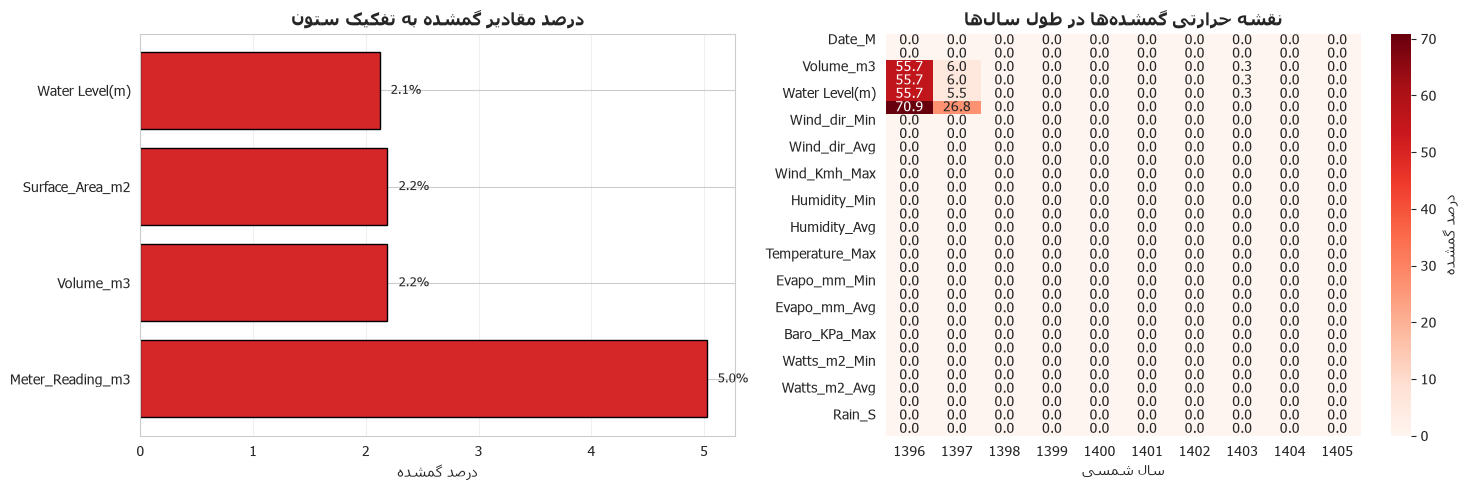

In [25]:
# ============================================================
# ۳. تحلیل مقادیر گمشده
# ============================================================

# جدول گمشده‌ها
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'ستون': missing.index,
    'تعداد گمشده': missing.values,
    'درصد': missing_pct.values,
    'نوع داده': [df[c].dtype for c in missing.index]
})

print("="*80)
print("۳. مقادیر گمشده")
print("="*80)
print(missing_df.to_string(index=False))

# ============================================================
# نمودار گمشده‌ها
# ============================================================
if len(missing) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # نمودار میله‌ای
    axes[0].barh(missing.index, missing_pct.values, color='#d62728', edgecolor='black')
    axes[0].set_xlabel('درصد گمشده')
    axes[0].set_title('درصد مقادیر گمشده به تفکیک ستون', fontweight='bold')
    for i, v in enumerate(missing_pct.values):
        axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Heatmap گمشده‌ها در طول زمان
    df_temp = df.copy()
    df_temp['Year_S'] = df_temp['Date_S'].str.split('/').str[0].astype(int)
    missing_by_year = df_temp.groupby('Year_S').apply(
        lambda x: x.isna().sum() / len(x) * 100
    )
    
    sns.heatmap(missing_by_year.T, cmap='Reds', annot=True, fmt='.1f',
                cbar_kws={'label': 'درصد گمشده'}, ax=axes[1])
    axes[1].set_title('نقشه حرارتی گمشده‌ها در طول سال‌ها', fontweight='bold')
    axes[1].set_xlabel('سال شمسی')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/reports/missing_values.png", dpi=150, bbox_inches='tight')
    plt.show()

۴. گزارش Outlierها
            ستون  IQR_outliers  Zscore_outliers  IQR_pct  Zscore_pct
     Rain_mm_Tot           450               65    14.68        2.12
    Wind_Kmh_Max            65               56     2.12        1.83
       Volume_m3            64               17     2.09        0.55
    Wind_Kmh_Avg            38               41     1.24        1.34
    Wind_Kmh_Min            10               26     0.33        0.85
    Humidity_Min             6                0     0.20        0.00
    Watts_m2_Min             2                6     0.07        0.20
Meter_Reading_m3             1                1     0.03        0.03
    Baro_KPa_Min             1                1     0.03        0.03
    Wind_dir_Min             1                3     0.03        0.10
  Water Level(m)             1                1     0.03        0.03
    Watts_m2_Max             1                2     0.03        0.07
    Baro_KPa_Max             1                1     0.03        0.03
    Baro_KPa_Av

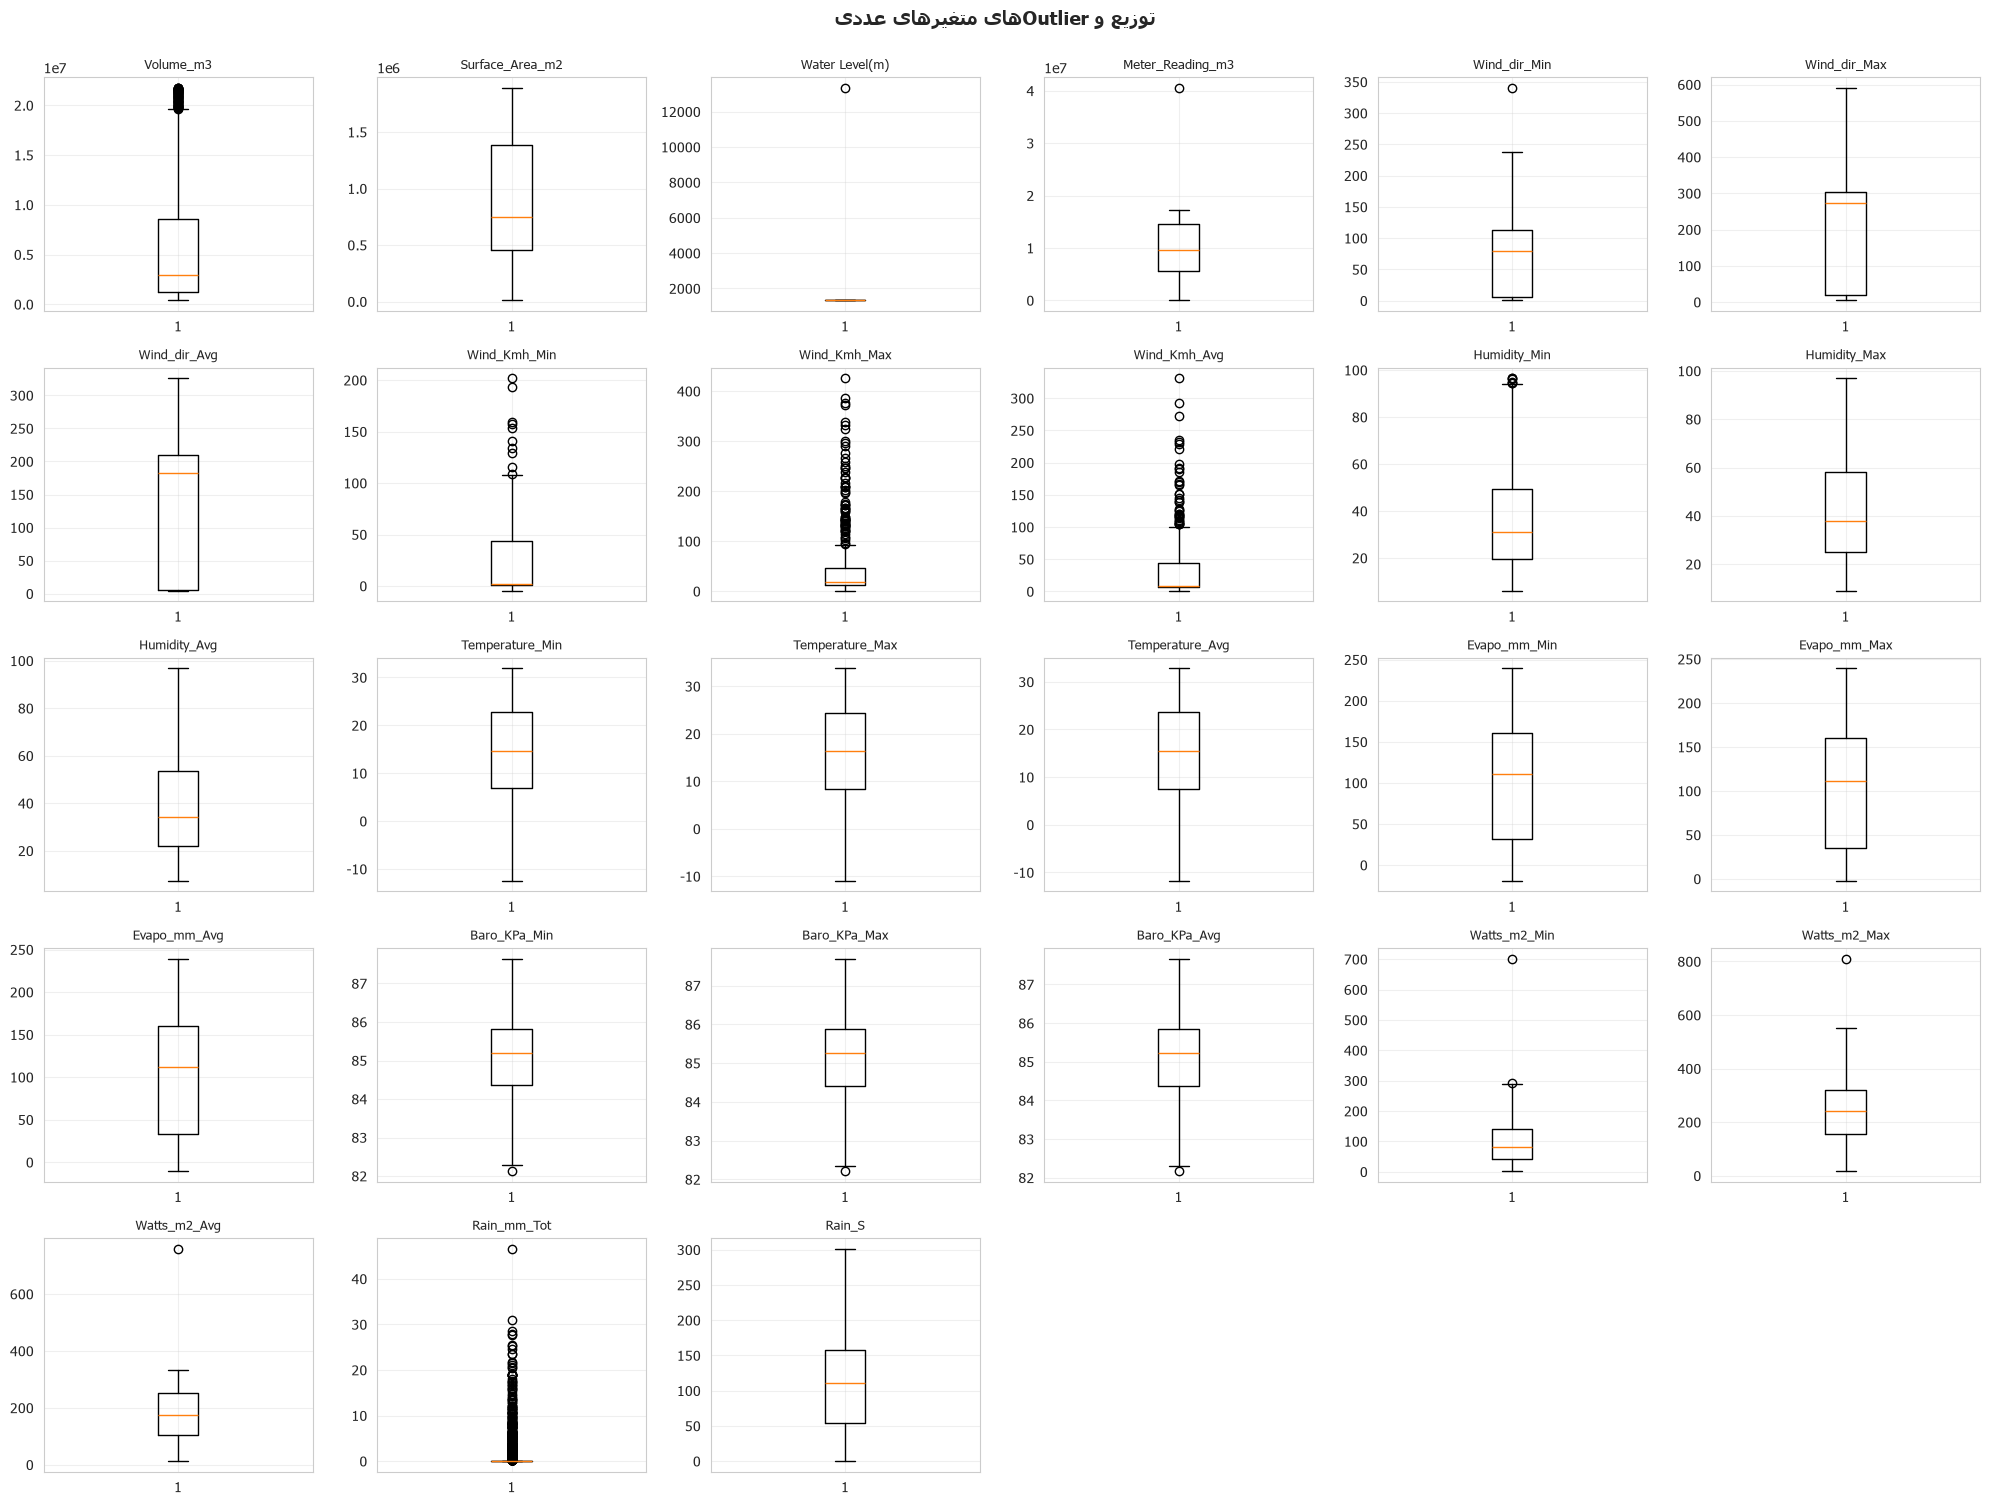

In [26]:
# ============================================================
# ۴. تشخیص Outlierها (چند روش)
# ============================================================

# ستون‌های عددی
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

def detect_outliers_iqr(series):
    """تشخیص outlier با IQR"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

def detect_outliers_zscore(series, threshold=3):
    """تشخیص outlier با Z-score"""
    z = np.abs(stats.zscore(series.dropna()))
    return (z > threshold).sum()

outlier_report = pd.DataFrame({
    'ستون': numeric_cols,
    'IQR_outliers': [detect_outliers_iqr(df[c]) for c in numeric_cols],
    'Zscore_outliers': [detect_outliers_zscore(df[c]) for c in numeric_cols],
})
outlier_report['IQR_pct'] = (outlier_report['IQR_outliers'] / len(df) * 100).round(2)
outlier_report['Zscore_pct'] = (outlier_report['Zscore_outliers'] / len(df) * 100).round(2)
outlier_report = outlier_report.sort_values('IQR_outliers', ascending=False)

print("="*80)
print("۴. گزارش Outlierها")
print("="*80)
print(outlier_report.to_string(index=False))

# ============================================================
# Boxplot همه متغیرها
# ============================================================
fig, axes = plt.subplots(5, 6, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:30]):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('توزیع و Outlierهای متغیرهای عددی', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/outliers_boxplot.png", dpi=100, bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# ۵. بررسی محدوده‌های فیزیکی منطقی
# ============================================================

# تعریف محدوده‌های منطقی برای هر پارامتر هواشناسی
physical_ranges = {
    'Temperature_Min':      (-40, 55),      # °C
    'Temperature_Max':      (-40, 60),
    'Temperature_Avg':      (-40, 55),
    'Humidity_Min':         (0, 100),        # %
    'Humidity_Max':         (0, 100),
    'Humidity_Avg':         (0, 100),
    'Wind_Kmh_Min':         (0, 200),        # km/h
    'Wind_Kmh_Max':         (0, 200),
    'Wind_Kmh_Avg':         (0, 200),
    'Wind_dir_Min':         (0, 360),        # درجه
    'Wind_dir_Max':         (0, 360),
    'Wind_dir_Avg':         (0, 360),
    'Baro_KPa_Min':         (80, 110),       # kPa
    'Baro_KPa_Max':         (80, 110),
    'Baro_KPa_Avg':         (80, 110),
    'Watts_m2_Min':         (0, 1500),       # W/m²
    'Watts_m2_Max':         (0, 1500),
    'Watts_m2_Avg':         (0, 1500),
    'Rain_mm_Tot':          (0, 500),        # mm/day
    'Evapo_mm_Min':         (0, 500),        # mm/day
    'Evapo_mm_Max':         (0, 500),
    'Evapo_mm_Avg':         (0, 500),
}

violations = []
for col, (low, high) in physical_ranges.items():
    if col in df.columns:
        n_below = (df[col] < low).sum()
        n_above = (df[col] > high).sum()
        if n_below + n_above > 0:
            violations.append({
                'ستون': col,
                'کمتر از حد': n_below,
                'بیشتر از حد': n_above,
                'مجموع': n_below + n_above,
                'محدوده مجاز': f'[{low}, {high}]'
            })

violations_df = pd.DataFrame(violations)
if len(violations_df) > 0:
    violations_df = violations_df.sort_values('مجموع', ascending=False)
    print("="*80)
    print("۵. نقض محدوده‌های فیزیکی")
    print("="*80)
    print(violations_df.to_string(index=False))
else:
    print("✅ همه مقادیر در محدوده فیزیکی منطقی هستند")

۵. نقض محدوده‌های فیزیکی
        ستون  کمتر از حد  بیشتر از حد  مجموع محدوده مجاز
Wind_Kmh_Min          31            1     32    [0, 200]
Wind_Kmh_Max           0           25     25    [0, 200]
Wind_Kmh_Avg           0            7      7    [0, 200]
Evapo_mm_Min           5            0      5    [0, 500]
Evapo_mm_Avg           2            0      2    [0, 500]
Wind_dir_Max           0            1      1    [0, 360]
Evapo_mm_Max           1            0      1    [0, 500]


In [28]:
# ============================================================
# ۶. بررسی داده‌های تکراری
# ============================================================

# تکراری در تاریخ
dup_dates = df['Date_M'].duplicated().sum()
print(f"تاریخ‌های تکراری: {dup_dates}")

# تکراری کامل
dup_rows = df.duplicated().sum()
print(f"ردیف‌های کاملاً تکراری: {dup_rows}")

# تکراری در Date_S
dup_dates_s = df['Date_S'].duplicated().sum()
print(f"تاریخ شمسی تکراری: {dup_dates_s}")

# بررسی پیوستگی تاریخ‌ها
df_sorted = df.sort_values('Date_M').reset_index(drop=True)
date_diff = df_sorted['Date_M'].diff().dt.days
gaps = date_diff[date_diff > 1]

if len(gaps) > 0:
    print(f"\n⚠️ شکاف در سری زمانی: {len(gaps)} مورد")
    for idx in gaps.index[:10]:
        print(f"  شکاف {date_diff[idx]:.0f} روزه در {df_sorted.loc[idx, 'Date_M']}")
else:
    print("\n✅ سری زمانی پیوسته است")

تاریخ‌های تکراری: 0
ردیف‌های کاملاً تکراری: 0
تاریخ شمسی تکراری: 0

✅ سری زمانی پیوسته است


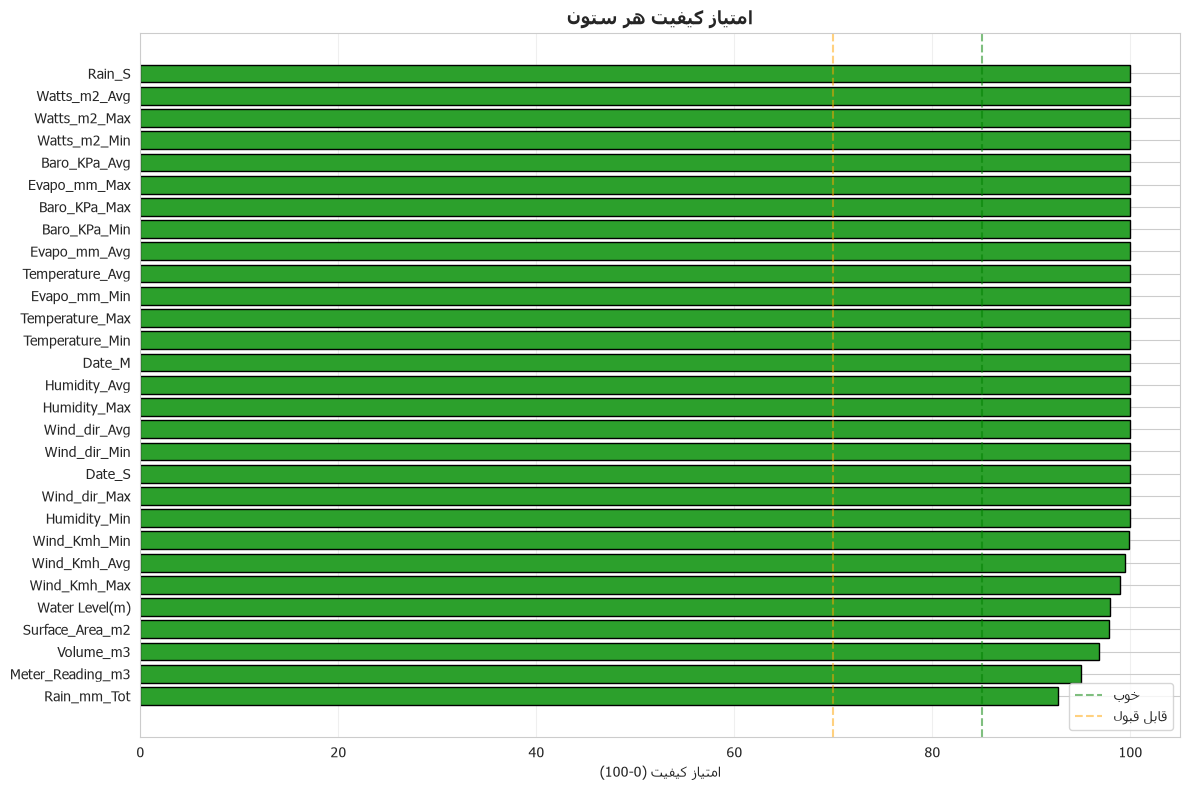

۷. امتیاز کیفیت ستون‌ها
Rain_mm_Tot         92.70
Meter_Reading_m3    95.00
Volume_m3           96.80
Surface_Area_m2     97.80
Water Level(m)      97.90
Wind_Kmh_Max        98.90
Wind_Kmh_Avg        99.40
Wind_Kmh_Min        99.80
Humidity_Min        99.90
Wind_dir_Max       100.00
Date_S             100.00
Wind_dir_Min       100.00
Wind_dir_Avg       100.00
Humidity_Max       100.00
Humidity_Avg       100.00
Date_M             100.00
Temperature_Min    100.00
Temperature_Max    100.00
Evapo_mm_Min       100.00
Temperature_Avg    100.00
Evapo_mm_Avg       100.00
Baro_KPa_Min       100.00
Baro_KPa_Max       100.00
Evapo_mm_Max       100.00
Baro_KPa_Avg       100.00
Watts_m2_Min       100.00
Watts_m2_Max       100.00
Watts_m2_Avg       100.00
Rain_S             100.00


In [29]:
# ============================================================
# ۷. گزارش جامع کیفیت داده
# ============================================================

def calculate_quality_score(df):
    """محاسبه امتیاز کیفیت هر ستون (0-100)"""
    scores = {}
    for col in df.columns:
        score = 100
        
        # کسر به‌خاطر گمشده‌ها
        null_pct = df[col].isna().sum() / len(df) * 100
        score -= null_pct * 1.0
        
        # کسر به‌خاطر outlier (برای عددی‌ها)
        if df[col].dtype in [np.float64, np.int64]:
            outlier_pct = detect_outliers_iqr(df[col]) / len(df) * 100
            score -= outlier_pct * 0.5
        
        scores[col] = max(0, round(score, 1))
    return pd.Series(scores)

quality_scores = calculate_quality_score(df).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#d62728' if s < 70 else '#ff7f0e' if s < 85 else '#2ca02c' 
          for s in quality_scores.values]
ax.barh(quality_scores.index, quality_scores.values, color=colors, edgecolor='black')
ax.axvline(85, color='green', linestyle='--', alpha=0.5, label='خوب')
ax.axvline(70, color='orange', linestyle='--', alpha=0.5, label='قابل قبول')
ax.set_xlabel('امتیاز کیفیت (0-100)')
ax.set_title('امتیاز کیفیت هر ستون', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/quality_scores.png", dpi=150, bbox_inches='tight')
plt.show()

print("="*80)
print("۷. امتیاز کیفیت ستون‌ها")
print("="*80)
print(quality_scores.to_string())

In [30]:
# ============================================================
# ۸. پاک‌سازی نهایی داده
# ============================================================
df_clean = df.copy()

# --- ۸.۱ حذف ردیف‌های خارج بازه ---
df_clean['Year_S']  = df_clean['Date_S'].str.split('/').str[0].astype(int)
df_clean['Month_S'] = df_clean['Date_S'].str.split('/').str[1].astype(int)
df_clean['Day_S']   = df_clean['Date_S'].str.split('/').str[2].astype(int)

df_clean = df_clean[(df_clean['Year_S'] >= 1398) & (df_clean['Year_S'] <= 1402)].copy()
print(f"بعد از فیلتر بازه: {len(df_clean)} ردیف")

# --- ۸.۲ مرتب‌سازی ---
df_clean = df_clean.sort_values('Date_M').reset_index(drop=True)

# --- ۸.۳ اصلاح سرعت باد غیرمنطقی ---
for col in ['Wind_Kmh_Min', 'Wind_Kmh_Avg', 'Wind_Kmh_Max']:
    n_before = (df_clean[col] > 100).sum()
    df_clean.loc[df_clean[col] > 100, col] = np.nan
    print(f"  {col}: {n_before} مقدار > 100 km/h → NaN")

# --- ۸.۴ اصلاح جهت باد > 360 ---
for col in ['Wind_dir_Min', 'Wind_dir_Avg', 'Wind_dir_Max']:
    n_before = (df_clean[col] > 360).sum()
    df_clean.loc[df_clean[col] > 360, col] = np.nan
    print(f"  {col}: {n_before} مقدار > 360 → NaN")

# --- ۸.۵ اصلاح تبخیر منفی ---
for col in ['Evapo_mm_Min', 'Evapo_mm_Avg', 'Evapo_mm_Max']:
    n_before = (df_clean[col] < 0).sum()
    df_clean.loc[df_clean[col] < 0, col] = np.nan
    print(f"  {col}: {n_before} مقدار منفی → NaN")

# --- ۸.۶ اصلاح سرعت باد منفی ---
df_clean['Wind_Kmh_Min'] = df_clean['Wind_Kmh_Min'].clip(lower=0)

# --- ۸.۷ درون‌یابی هوشمند ---
# برای هر ستون عددی، درون‌یابی خطی
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols_clean:
    if col not in ['Year_S', 'Month_S', 'Day_S']:  # اینها رو دست نزن
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')

# --- ۸.۸ بررسی نهایی ---
print("\n" + "="*80)
print("۸. بررسی نهایی بعد از پاک‌سازی")
print("="*80)
print(f"ابعاد: {df_clean.shape}")
print(f"گمشده‌ها: {df_clean.isna().sum().sum()}")
print(f"بازه: {df_clean['Date_M'].min()} تا {df_clean['Date_M'].max()}")

بعد از فیلتر بازه: 1826 ردیف
  Wind_Kmh_Min: 0 مقدار > 100 km/h → NaN
  Wind_Kmh_Avg: 0 مقدار > 100 km/h → NaN
  Wind_Kmh_Max: 0 مقدار > 100 km/h → NaN
  Wind_dir_Min: 0 مقدار > 360 → NaN
  Wind_dir_Avg: 0 مقدار > 360 → NaN
  Wind_dir_Max: 1 مقدار > 360 → NaN
  Evapo_mm_Min: 5 مقدار منفی → NaN
  Evapo_mm_Avg: 2 مقدار منفی → NaN
  Evapo_mm_Max: 1 مقدار منفی → NaN

۸. بررسی نهایی بعد از پاک‌سازی
ابعاد: (1826, 32)
گمشده‌ها: 0
بازه: 2019-03-21 00:00:00 تا 2024-03-19 00:00:00


In [31]:
# ============================================================
# ۹. ذخیره دیتاست تمیز (فرمت‌های مختلف)
# ============================================================

# --- Excel (برای بازبینی) ---
excel_path = f"{output_dir}/data/processed/weather_clean_1398_1402.xlsx"
df_clean.to_excel(excel_path, index=False)

# --- CSV (برای اشتراک) ---
csv_path = f"{output_dir}/data/processed/weather_clean_1398_1402.csv"
df_clean.to_csv(csv_path, index=False, encoding='utf-8-sig')

# --- Parquet (بهترین برای ML — سریع و کم‌حجم) ---
parquet_path = f"{output_dir}/data/processed/weather_clean_1398_1402.parquet"
df_clean.to_parquet(parquet_path, index=False, compression='snappy')

print("✅ دیتاست تمیز ذخیره شد:")
print(f"   📁 Excel:   {excel_path}")
print(f"   📁 CSV:     {csv_path}")
print(f"   📁 Parquet: {parquet_path}")

# --- گزارش نهایی به Excel ---
with pd.ExcelWriter(f"{output_dir}/reports/data_quality_report.xlsx", engine='openpyxl') as writer:
    profile.to_excel(writer, sheet_name='Profile')
    if len(missing_df) > 0:
        missing_df.to_excel(writer, sheet_name='Missing', index=False)
    outlier_report.to_excel(writer, sheet_name='Outliers', index=False)
    if len(violations_df) > 0:
        violations_df.to_excel(writer, sheet_name='Violations', index=False)
    quality_scores.to_frame('Quality_Score').to_excel(writer, sheet_name='Quality')

print(f"✅ گزارش کیفیت داده ذخیره شد")

✅ دیتاست تمیز ذخیره شد:
   📁 Excel:   C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project/data/processed/weather_clean_1398_1402.xlsx
   📁 CSV:     C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project/data/processed/weather_clean_1398_1402.csv
   📁 Parquet: C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project/data/processed/weather_clean_1398_1402.parquet
✅ گزارش کیفیت داده ذخیره شد


In [32]:
# ============================================================
# ۱۰. خلاصه فاز ۱
# ============================================================

summary = pd.DataFrame({
    'مورد': [
        'تعداد ردیف خام',
        'تعداد ردیف تمیز',
        'تعداد ستون',
        'بازه زمانی',
        'گمشده‌های اولیه',
        'گمشده‌های نهایی',
        'مشکلات شناسایی‌شده',
        'اصلاحات انجام‌شده',
    ],
    'مقدار': [
        f"{len(df):,}",
        f"{len(df_clean):,}",
        f"{df_clean.shape[1]}",
        f"{df_clean['Date_M'].min().date()} تا {df_clean['Date_M'].max().date()}",
        f"{df.isna().sum().sum():,}",
        f"{df_clean.isna().sum().sum():,}",
        f"{len(outlier_report[outlier_report['IQR_outliers'] > 0])} ستون با outlier",
        "فیلتر بازه + اصلاح باد + اصلاح تبخیر + درون‌یابی"
    ]
})

print("="*80)
print("✅ فاز ۱ با موفقیت کامل شد!")
print("="*80)
print(summary.to_string(index=False))

# ذخیره
summary.to_excel(f"{output_dir}/reports/phase1_summary.xlsx", index=False)

✅ فاز ۱ با موفقیت کامل شد!
              مورد                                            مقدار
    تعداد ردیف خام                                            3,065
   تعداد ردیف تمیز                                            1,826
        تعداد ستون                                               32
        بازه زمانی                         2019-03-21 تا 2024-03-19
   گمشده‌های اولیه                                              353
   گمشده‌های نهایی                                                0
مشکلات شناسایی‌شده                               15 ستون با outlier
 اصلاحات انجام‌شده فیلتر بازه + اصلاح باد + اصلاح تبخیر + درون‌یابی


In [33]:
# ============================================================
# Notebook 02: Feature Engineering
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# ============================================================
# ۱. بارگذاری داده تمیز
# ============================================================
output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
df = pd.read_parquet(f"{output_dir}/data/processed/weather_clean_1398_1402.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

print(f"✅ بارگذاری شد: {df.shape}")
print(f"بازه: {df['Date_M'].min()} تا {df['Date_M'].max()}")

✅ بارگذاری شد: (1826, 32)
بازه: 2019-03-21 00:00:00 تا 2024-03-19 00:00:00


In [34]:
# ============================================================
# ۲. ویژگی‌های تقویمی
# ============================================================

df['DayOfYear'] = df['Date_M'].dt.dayofyear
df['DayOfWeek'] = df['Date_M'].dt.dayofweek       # 0=دوشنبه
df['WeekOfYear'] = df['Date_M'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date_M'].dt.quarter

# فصل شمسی
def get_season_fa(month_s):
    if month_s in [1, 2, 3]:       return 'بهار'
    elif month_s in [4, 5, 6]:     return 'تابستان'
    elif month_s in [7, 8, 9]:     return 'پاییز'
    else:                          return 'زمستان'

df['Season_S'] = df['Month_S'].apply(get_season_fa)

# ============================================================
# ویژگی سیکلیکال (sin/cos) — برای حفظ چرخه‌ای بودن
# ============================================================
# ماه (12 دوره)
df['Month_sin'] = np.sin(2 * np.pi * df['Month_S'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month_S'] / 12)

# روز سال (365 دوره)
df['DOY_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['DOY_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

# روز هفته (7 دوره)
df['DOW_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DOW_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

print("✅ ویژگی‌های تقویمی ساخته شد")
print(f"   - DayOfYear, DayOfWeek, WeekOfYear, Quarter")
print(f"   - Month_sin, Month_cos, DOY_sin, DOY_cos, DOW_sin, DOW_cos")
print(f"   - Season_S")

✅ ویژگی‌های تقویمی ساخته شد
   - DayOfYear, DayOfWeek, WeekOfYear, Quarter
   - Month_sin, Month_cos, DOY_sin, DOY_cos, DOW_sin, DOW_cos
   - Season_S


In [35]:
# ============================================================
# ۳. ویژگی‌های فیزیکی
# ============================================================

# --- ۳.۱ VPD (کمبود فشار بخار) ---
# فشار بخار اشباع (Tetens formula)
def saturation_vapor_pressure(T):
    """فشار بخار اشباع (kPa)"""
    return 0.6108 * np.exp(17.27 * T / (T + 237.3))

# فشار بخار واقعی
def actual_vapor_pressure(T, RH):
    """فشار بخار واقعی (kPa)"""
    return saturation_vapor_pressure(T) * RH / 100

df['SVP'] = saturation_vapor_pressure(df['Temperature_Avg'])
df['AVP'] = actual_vapor_pressure(df['Temperature_Avg'], df['Humidity_Avg'])
df['VPD'] = df['SVP'] - df['AVP']    # Vapor Pressure Deficit

# --- ۳.۲ Heat Index (شاخص گرما) ---
# فقط برای دماهای بالای 27°C معنی داره
def heat_index(T, RH):
    """Heat Index (Rothfusz, 1990)"""
    T_f = T * 9/5 + 32
    HI = (0.5 * (T_f + 61.0 + ((T_f - 68.0) * 1.2) + (RH * 0.094)))
    HI = np.where((HI + T_f) / 2 > 80,
                  -42.379 + 2.04901523*T_f + 10.14333127*RH
                  - 0.22475541*T_f*RH - 0.00683783*T_f**2
                  - 0.05481717*RH**2 + 0.00122874*T_f**2*RH
                  + 0.00085282*T_f*RH**2 - 0.00000199*T_f**2*RH**2,
                  HI)
    return (HI - 32) * 5/9

df['Heat_Index'] = heat_index(df['Temperature_Max'], df['Humidity_Min'])

# --- ۳.۳ Wind Chill (سرمای باد) ---
def wind_chill(T, V):
    """Wind Chill (°C) — برای دما < 10°C و باد > 4.8 km/h"""
    T = np.asarray(T)
    V = np.asarray(V)
    WC = 13.12 + 0.6215*T - 11.37*V**0.16 + 0.3965*T*V**0.16
    return np.where((T < 10) & (V > 4.8), WC, T)

df['Wind_Chill'] = wind_chill(df['Temperature_Min'], df['Wind_Kmh_Avg'])

# --- ۳.۴ Thermal Amplitude (دامنه دمایی روزانه) ---
df['Thermal_Amplitude'] = df['Temperature_Max'] - df['Temperature_Min']

# --- ۳.۵ Temperature Range Index ---
df['Temp_Range_Index'] = (df['Temperature_Max'] - df['Temperature_Min']) / df['Temperature_Avg'].abs().clip(lower=1)

# --- ۳.۶ Dew Point (نقطه شبنم) ---
def dew_point(T, RH):
    """نقطه شبنم (°C) — Magnus formula"""
    a, b = 17.27, 237.7
    alpha = (a * T) / (b + T) + np.log(RH / 100)
    return (b * alpha) / (a - alpha)

df['Dew_Point'] = dew_point(df['Temperature_Avg'], df['Humidity_Avg'])

# --- ۳.۷ PET (تبخیر-تعرق پتانسیل) — Hargreaves ---
def pet_hargreaves(T_mean, T_max, T_min, Ra):
    """PET (mm/day) — Hargreaves-Samani"""
    T_range = T_max - T_min
    return 0.0023 * (T_mean + 17.8) * np.sqrt(T_range) * Ra / 2.45

# Ra تقریبی برای عرض جغرافیایی ایران
df['Ra_MJ'] = 25  # MJ/m²/day تقریبی
df['PET_Hargreaves'] = pet_hargreaves(
    df['Temperature_Avg'],
    df['Temperature_Max'],
    df['Temperature_Min'],
    df['Ra_MJ']
)

# --- ۳.۸ Relative Humidity Range ---
df['Humidity_Range'] = df['Humidity_Max'] - df['Humidity_Min']

# --- ۳.۹ Wind Direction Components (به جای زاویه خام) ---
df['Wind_U'] = -df['Wind_Kmh_Avg'] * np.sin(np.radians(df['Wind_dir_Avg']))
df['Wind_V'] = -df['Wind_Kmh_Avg'] * np.cos(np.radians(df['Wind_dir_Avg']))

# --- ۳.۱۰ Wind Gust Factor ---
df['Wind_Gust_Factor'] = df['Wind_Kmh_Max'] / df['Wind_Kmh_Avg'].clip(lower=0.1)

print("✅ ویژگی‌های فیزیکی ساخته شد:")
print("   - SVP, AVP, VPD")
print("   - Heat_Index, Wind_Chill")
print("   - Thermal_Amplitude, Temp_Range_Index")
print("   - Dew_Point, PET_Hargreaves")
print("   - Humidity_Range, Wind_U, Wind_V, Wind_Gust_Factor")

✅ ویژگی‌های فیزیکی ساخته شد:
   - SVP, AVP, VPD
   - Heat_Index, Wind_Chill
   - Thermal_Amplitude, Temp_Range_Index
   - Dew_Point, PET_Hargreaves
   - Humidity_Range, Wind_U, Wind_V, Wind_Gust_Factor


In [36]:
# ============================================================
# ۴. ویژگی‌های Lag, Rolling, Diff
# ============================================================

# --- ستون‌های هدف برای feature engineering ---
key_vars = ['Temperature_Avg', 'Humidity_Avg', 'Evapo_mm_Avg',
            'Wind_Kmh_Avg', 'Watts_m2_Avg', 'Baro_KPa_Avg',
            'Rain_mm_Tot', 'VPD', 'PET_Hargreaves']

# --- ۴.۱ Lag Features (تأخیر ۱، ۳، ۷، ۱۴، ۳۰ روزه) ---
for var in key_vars:
    for lag in [1, 3, 7, 14, 30]:
        df[f'{var}_lag{lag}'] = df[var].shift(lag)

# --- ۴.۲ Rolling Features (میانگین متحرک) ---
for var in key_vars:
    for window in [3, 7, 14, 30]:
        df[f'{var}_roll{window}_mean'] = df[var].rolling(window).mean()
        df[f'{var}_roll{window}_std']  = df[var].rolling(window).std()

# --- ۴.۳ Diff Features (تغییرات) ---
for var in ['Temperature_Avg', 'Humidity_Avg', 'Evapo_mm_Avg', 'Wind_Kmh_Avg']:
    df[f'{var}_diff1'] = df[var].diff(1)
    df[f'{var}_diff7'] = df[var].diff(7)

# --- ۴.۴ EWMA (میانگین متحرک وزن‌دار نمایی) ---
for var in ['Temperature_Avg', 'Evapo_mm_Avg', 'Humidity_Avg']:
    df[f'{var}_ewma7']  = df[var].ewm(span=7).mean()
    df[f'{var}_ewma30'] = df[var].ewm(span=30).mean()

print(f"✅ ویژگی‌های زمانی ساخته شد")
print(f"   - Lag: {len(key_vars) * 5} ویژگی")
print(f"   - Rolling: {len(key_vars) * 4 * 2} ویژگی")
print(f"   - Diff: {4 * 2} ویژگی")
print(f"   - EWMA: {3 * 2} ویژگی")

✅ ویژگی‌های زمانی ساخته شد
   - Lag: 45 ویژگی
   - Rolling: 72 ویژگی
   - Diff: 8 ویژگی
   - EWMA: 6 ویژگی


In [37]:
# ============================================================
# ۵. ویژگی‌های آماری
# ============================================================

# --- ۵.۱ Z-score فصلی (نسبت به میانگین همان ماه) ---
for var in ['Temperature_Avg', 'Rain_mm_Tot', 'Evapo_mm_Avg', 'Humidity_Avg']:
    monthly_mean = df.groupby('Month_S')[var].transform('mean')
    monthly_std  = df.groupby('Month_S')[var].transform('std')
    df[f'{var}_zscore_monthly'] = (df[var] - monthly_mean) / monthly_std.clip(lower=0.01)

# --- ۵.۲ Anomaly نسبت به میانگین کل ---
for var in ['Temperature_Avg', 'Rain_mm_Tot', 'Evapo_mm_Avg']:
    df[f'{var}_anomaly'] = df[var] - df[var].mean()

# --- ۵.۳ Percentile Rank (رتبه صدکی) ---
for var in ['Temperature_Avg', 'Evapo_mm_Avg', 'Humidity_Avg']:
    df[f'{var}_pctrank'] = df[var].rank(pct=True)

# --- ۵.۴ Cumulative Rain (بارش تجمعی) ---
df['Rain_cum_7']  = df['Rain_mm_Tot'].rolling(7).sum()
df['Rain_cum_30'] = df['Rain_mm_Tot'].rolling(30).sum()
df['Rain_cum_90'] = df['Rain_mm_Tot'].rolling(90).sum()

# --- ۵.۵ Days Since Rain (روزهای بدون بارش) ---
def days_since_rain(rain_series, threshold=0.5):
    """تعداد روزهای متوالی بدون بارش"""
    result = np.zeros(len(rain_series))
    counter = 0
    for i, r in enumerate(rain_series):
        if r < threshold:
            counter += 1
        else:
            counter = 0
        result[i] = counter
    return result

df['Days_Since_Rain'] = days_since_rain(df['Rain_mm_Tot'])

# --- ۵.۶ Cumulative Evaporation ---
df['Evapo_cum_7']  = df['Evapo_mm_Avg'].rolling(7).sum()
df['Evapo_cum_30'] = df['Evapo_mm_Avg'].rolling(30).sum()

print("✅ ویژگی‌های آماری ساخته شد")

✅ ویژگی‌های آماری ساخته شد


In [38]:
# ============================================================
# ۶. ویژگی‌های تعاملی
# ============================================================

# --- ۶.۱ تعاملات دوگانه ---
df['Temp_x_Humidity']    = df['Temperature_Avg'] * df['Humidity_Avg']
df['Temp_x_Watts']       = df['Temperature_Avg'] * df['Watts_m2_Avg']
df['Wind_x_Watts']       = df['Wind_Kmh_Avg'] * df['Watts_m2_Avg']
df['VPD_x_Wind']         = df['VPD'] * df['Wind_Kmh_Avg']
df['PET_x_Wind']         = df['PET_Hargreaves'] * df['Wind_Kmh_Avg']

# --- ۶.۲ نسبت‌ها ---
df['Watts_per_Temp']     = df['Watts_m2_Avg'] / df['Temperature_Avg'].clip(lower=1)
df['Evapo_per_Watts']    = df['Evapo_mm_Avg'] / df['Watts_m2_Avg'].clip(lower=1)
df['Evapo_per_Temp']     = df['Evapo_mm_Avg'] / (df['Temperature_Avg'] + 10)
df['Humidity_per_Temp']  = df['Humidity_Avg'] / (df['Temperature_Avg'] + 10)

print("✅ ویژگی‌های تعاملی ساخته شد")

✅ ویژگی‌های تعاملی ساخته شد


In [39]:
# ============================================================
# ۷. ویژگی‌های رخدادهای حدی
# ============================================================

# --- ۷.۱ Heat Wave Flag ---
# موج گرما: دمای بیشینه > صدک ۹۵ در ۳ روز متوالی
temp_p95 = df['Temperature_Max'].quantile(0.95)
df['Hot_Day'] = (df['Temperature_Max'] > temp_p95).astype(int)
df['Heat_Wave'] = df['Hot_Day'].rolling(3).sum() >= 3

# --- ۷.۲ Cold Snap Flag ---
temp_p05 = df['Temperature_Min'].quantile(0.05)
df['Cold_Day'] = (df['Temperature_Min'] < temp_p05).astype(int)
df['Cold_Snap'] = df['Cold_Day'].rolling(3).sum() >= 3

# --- ۷.۳ Heavy Rain Flag ---
rain_p95 = df['Rain_mm_Tot'].quantile(0.95)
df['Heavy_Rain'] = (df['Rain_mm_Tot'] > rain_p95).astype(int)

# --- ۷.۴ Windy Day Flag ---
wind_p95 = df['Wind_Kmh_Max'].quantile(0.95)
df['Windy_Day'] = (df['Wind_Kmh_Max'] > wind_p95).astype(int)

# --- ۷.۵ High Evaporation Flag ---
evapo_p90 = df['Evapo_mm_Avg'].quantile(0.90)
df['High_Evapo'] = (df['Evapo_mm_Avg'] > evapo_p90).astype(int)

# --- ۷.۶ Dry Spell (دوره خشک طولانی) ---
df['Dry_Spell'] = (df['Days_Since_Rain'] > 14).astype(int)

print("✅ ویژگی‌های رخدادهای حدی ساخته شد")

✅ ویژگی‌های رخدادهای حدی ساخته شد


In [40]:
# ============================================================
# ۸. پاک‌سازی نهایی
# ============================================================

# --- ۸.۱ حذف ستون‌های موقت ---
df = df.drop(columns=['Ra_MJ'], errors='ignore')

# --- ۸.۲ حذف ردیف‌های اولیه که lag دارن NaN ---
initial_rows = len(df)
df = df.dropna().reset_index(drop=True)  # ساده‌ترین راه
# یا اگه می‌خوای حداکثر داده رو نگه داری:
# df = df.iloc[30:].reset_index(drop=True)  # فقط 30 روز اول

print(f"ردیف‌ها قبل: {initial_rows}")
print(f"ردیف‌ها بعد: {len(df)}")
print(f"ستون‌ها: {df.shape[1]}")

ردیف‌ها قبل: 1826
ردیف‌ها بعد: 1737
ستون‌ها: 220


Top 20 ویژگی با بیشترین همبستگی با تبخیر
Evapo_mm_Avg_anomaly          1.000
Evapo_mm_Min                  1.000
Evapo_mm_Max                  1.000
Evapo_mm_Avg_pctrank          0.989
Evapo_mm_Avg_roll3_mean       0.970
Evapo_mm_Avg_lag1             0.955
Evapo_mm_Avg_ewma7            0.943
Evapo_cum_7                   0.903
Evapo_mm_Avg_roll7_mean       0.903
Evapo_mm_Avg_roll14_mean      0.845
Evapo_mm_Avg_lag3             0.835
Evapo_mm_Avg_ewma30           0.830
Evapo_per_Temp                0.804
Evapo_cum_30                  0.772
Evapo_mm_Avg_roll30_mean      0.772
PET_Hargreaves_roll30_mean    0.730
Temperature_Avg_roll30_mean   0.727
Temperature_Avg_ewma30        0.725
PET_Hargreaves_roll14_mean    0.707
Temperature_Avg_roll14_mean   0.707


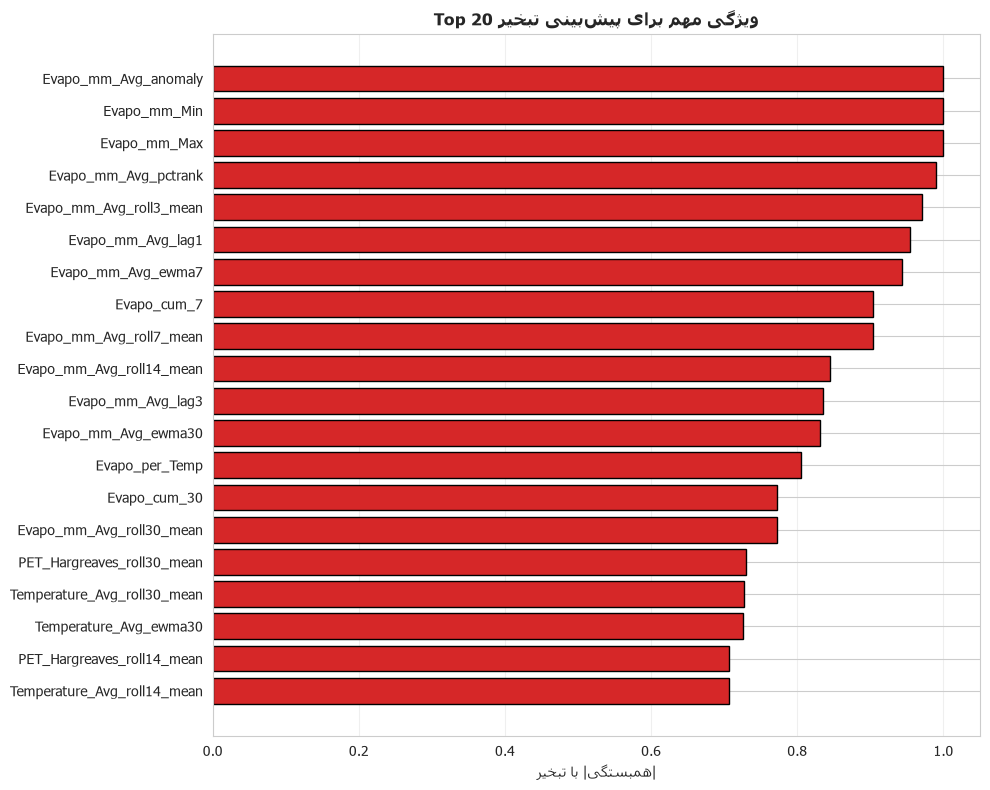

In [41]:
# ============================================================
# ۹. تحلیل سریع اهمیت ویژگی‌ها
# ============================================================

# همبستگی با هدف (Evapo)
target = 'Evapo_mm_Avg'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]

correlations = df[numeric_cols].corrwith(df[target]).abs().sort_values(ascending=False)

print("="*80)
print("Top 20 ویژگی با بیشترین همبستگی با تبخیر")
print("="*80)
print(correlations.head(20).round(3).to_string())

# نمودار
fig, ax = plt.subplots(figsize=(10, 8))
top20 = correlations.head(20)
colors = ['#d62728' if v > 0.7 else '#ff7f0e' if v > 0.4 else '#1f77b4' 
          for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='black')
ax.set_xlabel('|همبستگی| با تبخیر')
ax.set_title('Top 20 ویژگی مهم برای پیش‌بینی تبخیر', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/feature_importance_preview.png", dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# ============================================================
# ۱۰. ذخیره دیتاست با ویژگی‌های جدید
# ============================================================

# ذخیره Parquet
output_path = f"{output_dir}/data/processed/weather_features_1398_1402.parquet"
df.to_parquet(output_path, index=False, compression='snappy')

# ذخیره CSV
df.to_csv(f"{output_dir}/data/processed/weather_features_1398_1402.csv", 
          index=False, encoding='utf-8-sig')

# ذخیره لیست ویژگی‌ها
feature_cols = [c for c in df.columns if c not in 
                ['Date_M', 'Date_S', 'Year_S', 'Month_S', 'Day_S', 'Season_S']]
with open(f"{output_dir}/reports/feature_list.txt", 'w', encoding='utf-8') as f:
    for col in feature_cols:
        f.write(f"{col}\n")

print(f"✅ دیتاست غنی ذخیره شد:")
print(f"   📁 {output_path}")
print(f"   📊 ابعاد نهایی: {df.shape}")
print(f"   🎯 تعداد ویژگی‌ها: {len(feature_cols)}")

✅ دیتاست غنی ذخیره شد:
   📁 C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project/data/processed/weather_features_1398_1402.parquet
   📊 ابعاد نهایی: (1737, 220)
   🎯 تعداد ویژگی‌ها: 214


In [43]:
# ============================================================
# ۱۱. خلاصه فاز ۲
# ============================================================

summary = pd.DataFrame({
    'دسته ویژگی': [
        'تقویمی',
        'فیزیکی',
        'زمانی (Lag)',
        'زمانی (Rolling)',
        'زمانی (Diff/EWMA)',
        'آماری',
        'تعاملی',
        'رخدادهای حدی',
    ],
    'تعداد': [
        11,   # DayOfYear, DayOfWeek, WeekOfYear, Quarter, Season_S, sin/cos...
        13,   # SVP, AVP, VPD, Heat_Index, Wind_Chill, ...
        45,   # 9 متغیر × 5 lag
        72,   # 9 متغیر × 4 window × 2 (mean/std)
        14,   # 4 × 2 diff + 3 × 2 ewma
        14,   # zscore, anomaly, pctrank, cum...
        9,    # interactionها
        6,    # heat wave, cold snap, ...
    ]
})

print("="*80)
print("✅ فاز ۲ با موفقیت کامل شد!")
print("="*80)
print(summary.to_string(index=False))
print(f"\n📊 دیتاست نهایی: {df.shape[0]:,} ردیف × {df.shape[1]} ستون")
print(f"🎯 تعداد ویژگی‌های نهایی: {len(feature_cols)}")

summary.to_excel(f"{output_dir}/reports/phase2_summary.xlsx", index=False)

✅ فاز ۲ با موفقیت کامل شد!
       دسته ویژگی  تعداد
           تقویمی     11
           فیزیکی     13
      زمانی (Lag)     45
  زمانی (Rolling)     72
زمانی (Diff/EWMA)     14
            آماری     14
           تعاملی      9
     رخدادهای حدی      6

📊 دیتاست نهایی: 1,737 ردیف × 220 ستون
🎯 تعداد ویژگی‌های نهایی: 214


In [44]:
# ============================================================
# Notebook 03: Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_1398_1402.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

print(f"✅ بارگذاری: {df.shape}")

✅ بارگذاری: (1737, 220)


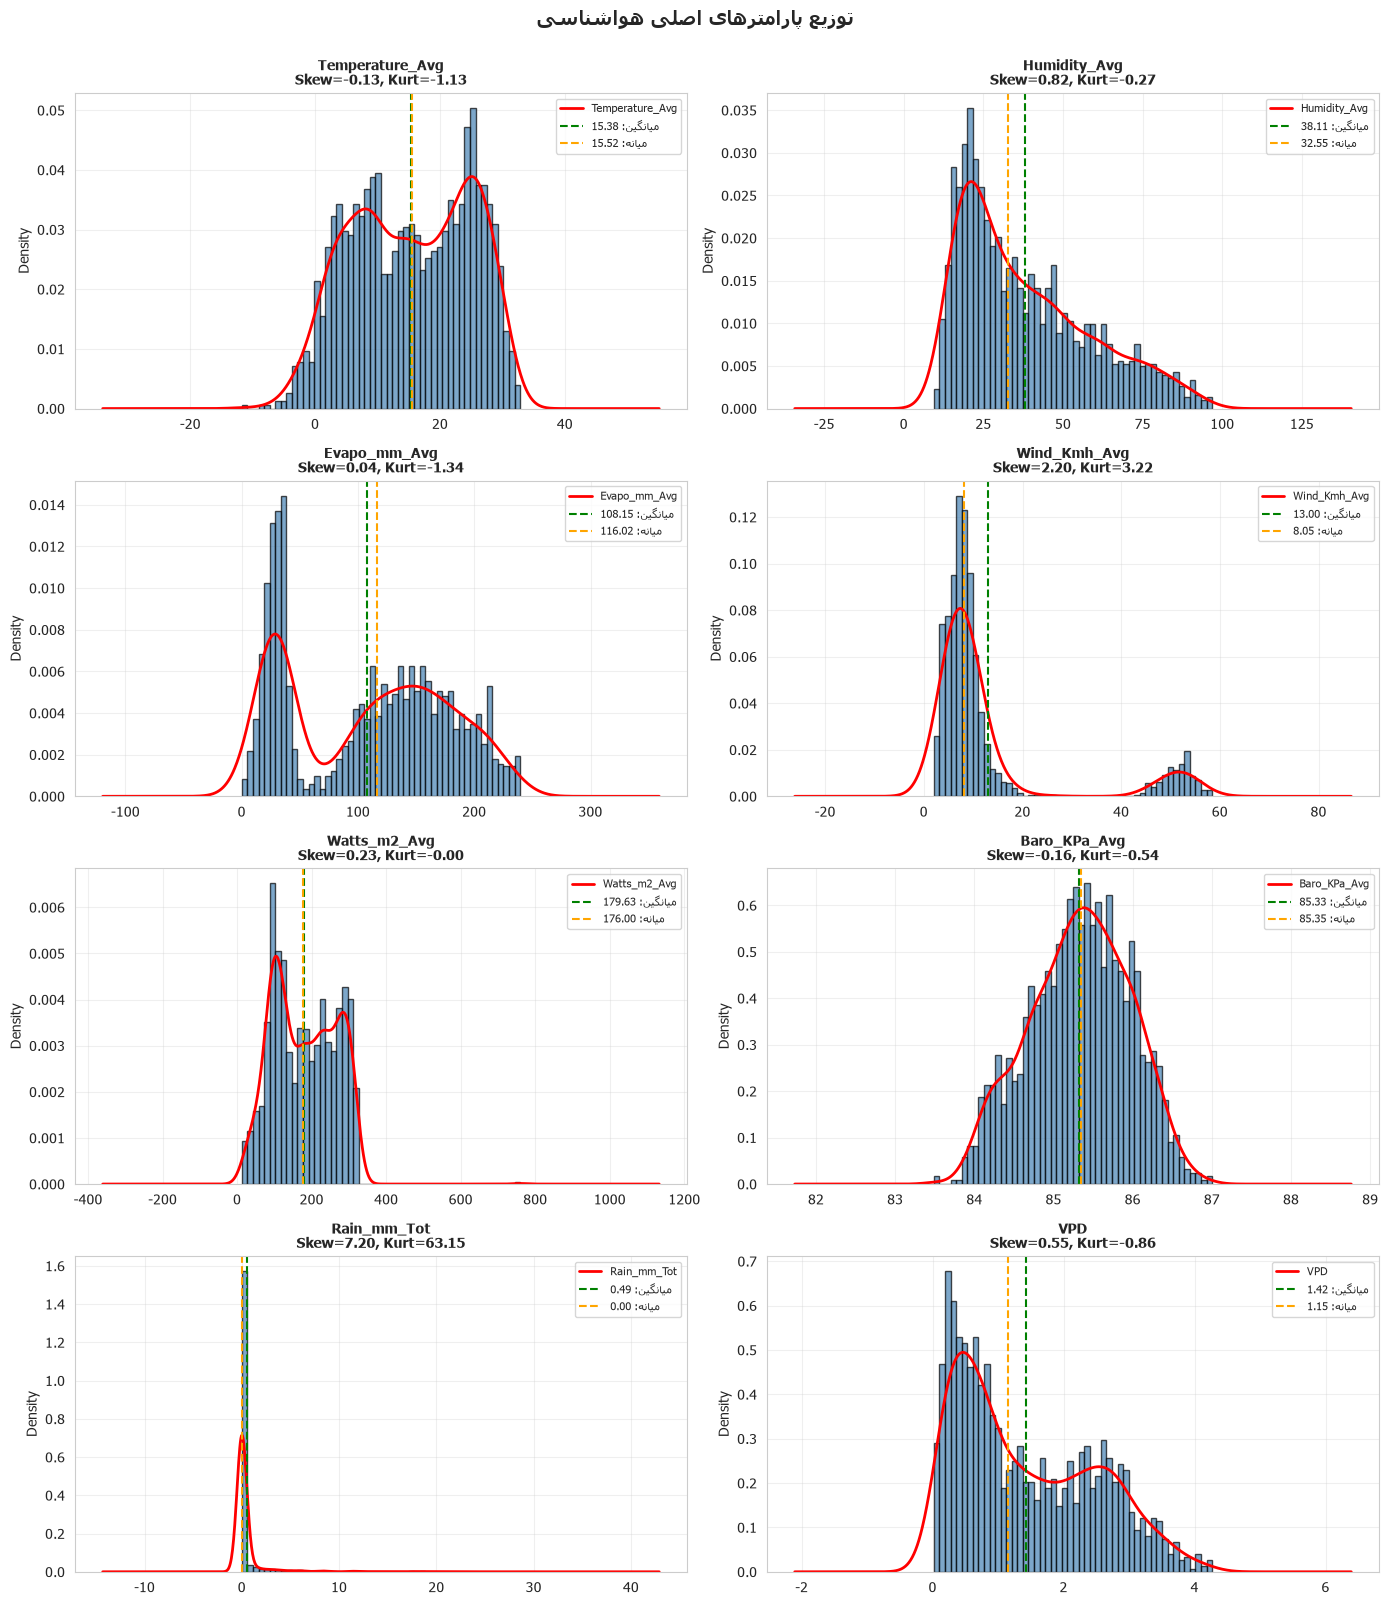

In [45]:
# ============================================================
# ۲.۱ توزیع پارامترهای اصلی
# ============================================================

main_vars = ['Temperature_Avg', 'Humidity_Avg', 'Evapo_mm_Avg',
             'Wind_Kmh_Avg', 'Watts_m2_Avg', 'Baro_KPa_Avg',
             'Rain_mm_Tot', 'VPD']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, var in enumerate(main_vars):
    data = df[var].dropna()
    
    # هیستوگرام + KDE
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='black',
                 alpha=0.7, density=True)
    data.plot.kde(ax=axes[i], color='red', linewidth=2)
    
    # آمار
    mean = data.mean()
    median = data.median()
    axes[i].axvline(mean, color='green', linestyle='--', linewidth=1.5,
                    label=f'میانگین: {mean:.2f}')
    axes[i].axvline(median, color='orange', linestyle='--', linewidth=1.5,
                    label=f'میانه: {median:.2f}')
    
    # Skewness & Kurtosis
    skew = data.skew()
    kurt = data.kurtosis()
    axes[i].set_title(f'{var}\nSkew={skew:.2f}, Kurt={kurt:.2f}',
                      fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('توزیع پارامترهای اصلی هواشناسی', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_univariate.png", dpi=120, bbox_inches='tight')
plt.show()

In [46]:
# ============================================================
# ۲.۲ آزمون نرمالیتی (Shapiro-Wilk و KS)
# ============================================================

normality = []
for var in main_vars:
    data = df[var].dropna()
    
    # Shapiro (نمونه 5000 تا برای سرعت)
    shapiro_stat, shapiro_p = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))
    
    # KS Test
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
    
    normality.append({
        'متغیر': var,
        'Shapiro_W': round(shapiro_stat, 4),
        'Shapiro_p': f'{shapiro_p:.2e}',
        'KS_stat': round(ks_stat, 4),
        'KS_p': f'{ks_p:.2e}',
        'نرمال؟': '✅' if shapiro_p > 0.05 else '❌'
    })

normality_df = pd.DataFrame(normality)
print("="*80)
print("آزمون نرمالیتی")
print("="*80)
print(normality_df.to_string(index=False))

آزمون نرمالیتی
          متغیر  Shapiro_W Shapiro_p  KS_stat      KS_p نرمال؟
Temperature_Avg      0.961  3.38e-21    0.081  2.95e-10      ❌
   Humidity_Avg      0.916  5.10e-30    0.114  3.82e-20      ❌
   Evapo_mm_Avg      0.920  1.95e-29    0.170  4.04e-44      ❌
   Wind_Kmh_Avg      0.572  4.60e-54    0.334 4.45e-173      ❌
   Watts_m2_Avg      0.948  2.15e-24    0.094  6.37e-14      ❌
   Baro_KPa_Avg      0.992  2.83e-08    0.026  1.78e-01      ❌
    Rain_mm_Tot      0.229  1.35e-64    0.457  0.00e+00      ❌
            VPD      0.923  5.95e-29    0.128  3.12e-25      ❌


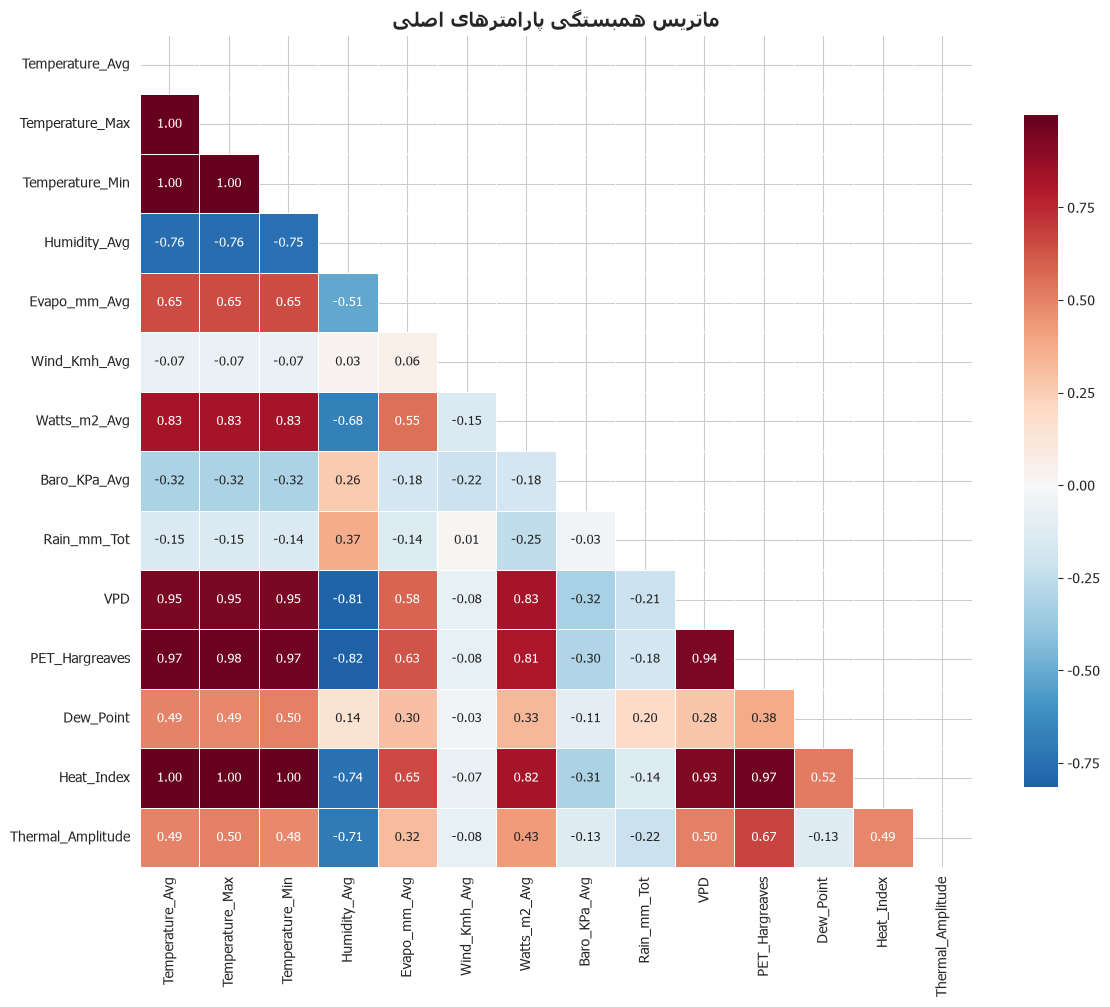

In [47]:
# ============================================================
# ۳.۱ ماتریس همبستگی
# ============================================================

# متغیرهای اصلی برای همبستگی
corr_vars = ['Temperature_Avg', 'Temperature_Max', 'Temperature_Min',
             'Humidity_Avg', 'Evapo_mm_Avg', 'Wind_Kmh_Avg',
             'Watts_m2_Avg', 'Baro_KPa_Avg', 'Rain_mm_Tot',
             'VPD', 'PET_Hargreaves', 'Dew_Point',
             'Heat_Index', 'Thermal_Amplitude']

corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9}, ax=ax)
ax.set_title('ماتریس همبستگی پارامترهای اصلی', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_correlation.png", dpi=120, bbox_inches='tight')
plt.show()

# ذخیره
corr_matrix.round(3).to_excel(f"{output_dir}/reports/correlation_matrix.xlsx")

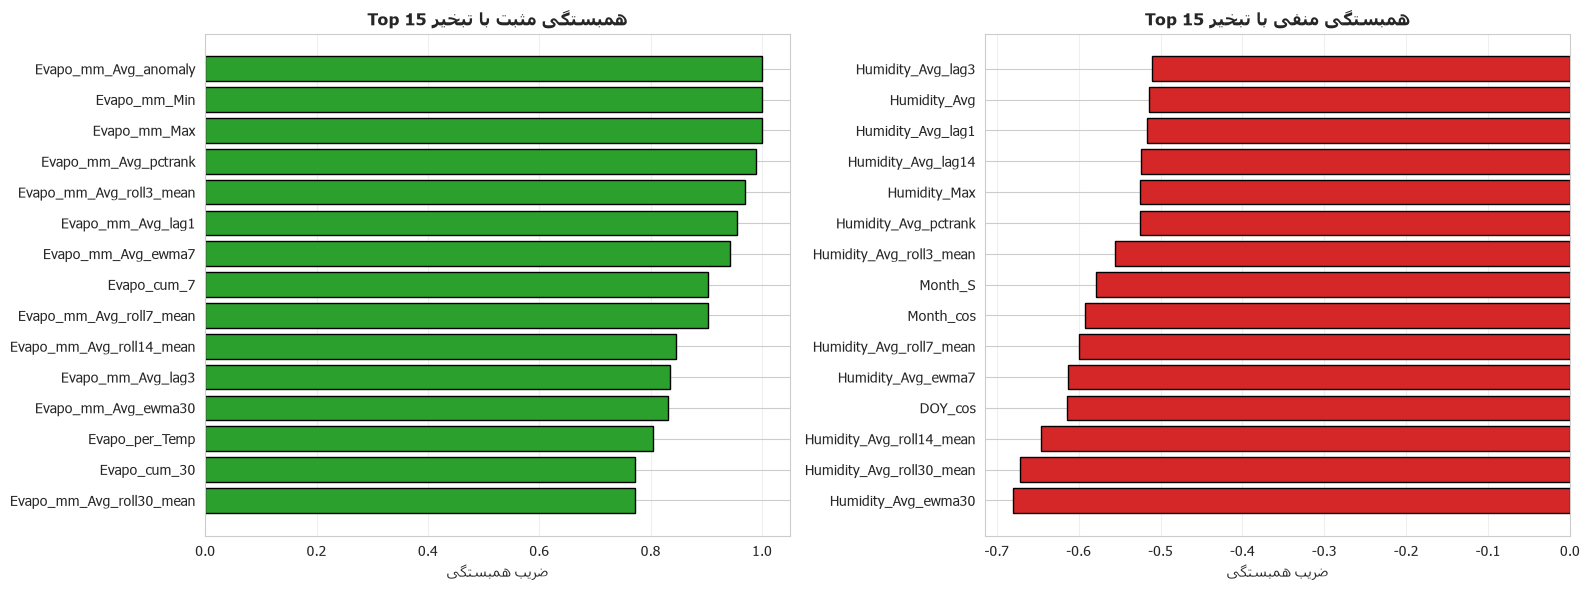

In [48]:
# ============================================================
# ۳.۲ همبستگی با تبخیر
# ============================================================

target = 'Evapo_mm_Avg'
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corrwith(df[target]).drop(target).sort_values()

# Top 20 مثبت و منفی
top_pos = corr_with_target.tail(15)
top_neg = corr_with_target.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_pos.index, top_pos.values, color='#2ca02c', edgecolor='black')
axes[0].set_title('Top 15 همبستگی مثبت با تبخیر', fontweight='bold')
axes[0].set_xlabel('ضریب همبستگی')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_neg.index, top_neg.values, color='#d62728', edgecolor='black')
axes[1].set_title('Top 15 همبستگی منفی با تبخیر', fontweight='bold')
axes[1].set_xlabel('ضریب همبستگی')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_evapo_correlation.png", dpi=120, bbox_inches='tight')
plt.show()

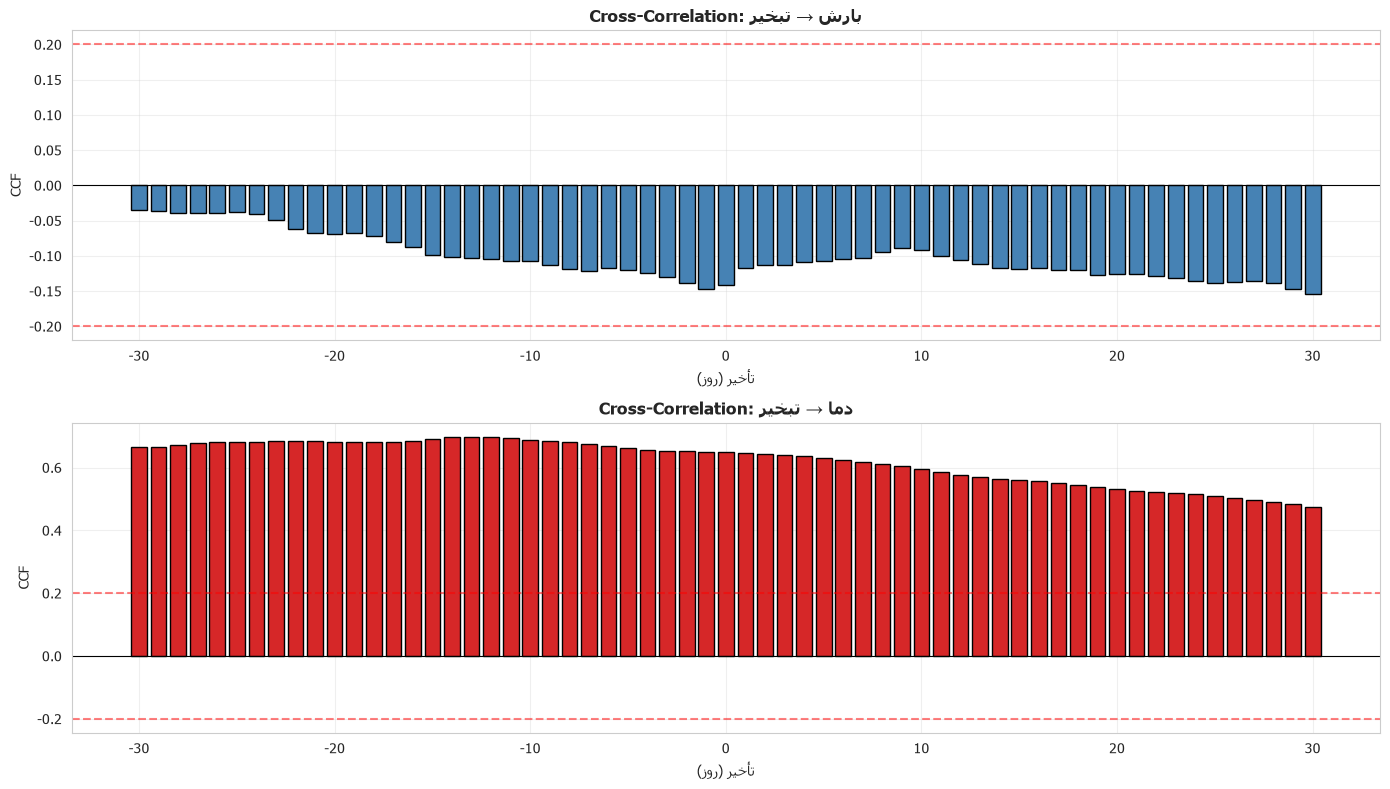

In [49]:
# ============================================================
# ۳.۳ Cross-Correlation
# ============================================================

from statsmodels.tsa.stattools import ccf

def cross_correlation(x, y, max_lag=30):
    """محاسبه CCF با تأخیر"""
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    lags = range(-max_lag, max_lag + 1)
    ccf_vals = [np.corrcoef(x[max(0, lag):len(x)+min(0, lag)],
                            y[max(0, -lag):len(y)+min(0, -lag)])[0, 1]
                for lag in lags]
    return list(lags), ccf_vals

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# بارش → تبخیر
lags, ccf_vals = cross_correlation(df['Rain_mm_Tot'].values, 
                                   df['Evapo_mm_Avg'].values, max_lag=30)
axes[0].bar(lags, ccf_vals, color='steelblue', edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(0.2, color='red', linestyle='--', alpha=0.5)
axes[0].axhline(-0.2, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Cross-Correlation: بارش → تبخیر', fontweight='bold')
axes[0].set_xlabel('تأخیر (روز)')
axes[0].set_ylabel('CCF')
axes[0].grid(alpha=0.3)

# دما → تبخیر
lags2, ccf_vals2 = cross_correlation(df['Temperature_Avg'].values,
                                     df['Evapo_mm_Avg'].values, max_lag=30)
axes[1].bar(lags2, ccf_vals2, color='#d62728', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(0.2, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(-0.2, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Cross-Correlation: دما → تبخیر', fontweight='bold')
axes[1].set_xlabel('تأخیر (روز)')
axes[1].set_ylabel('CCF')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_cross_correlation.png", dpi=120, bbox_inches='tight')
plt.show()

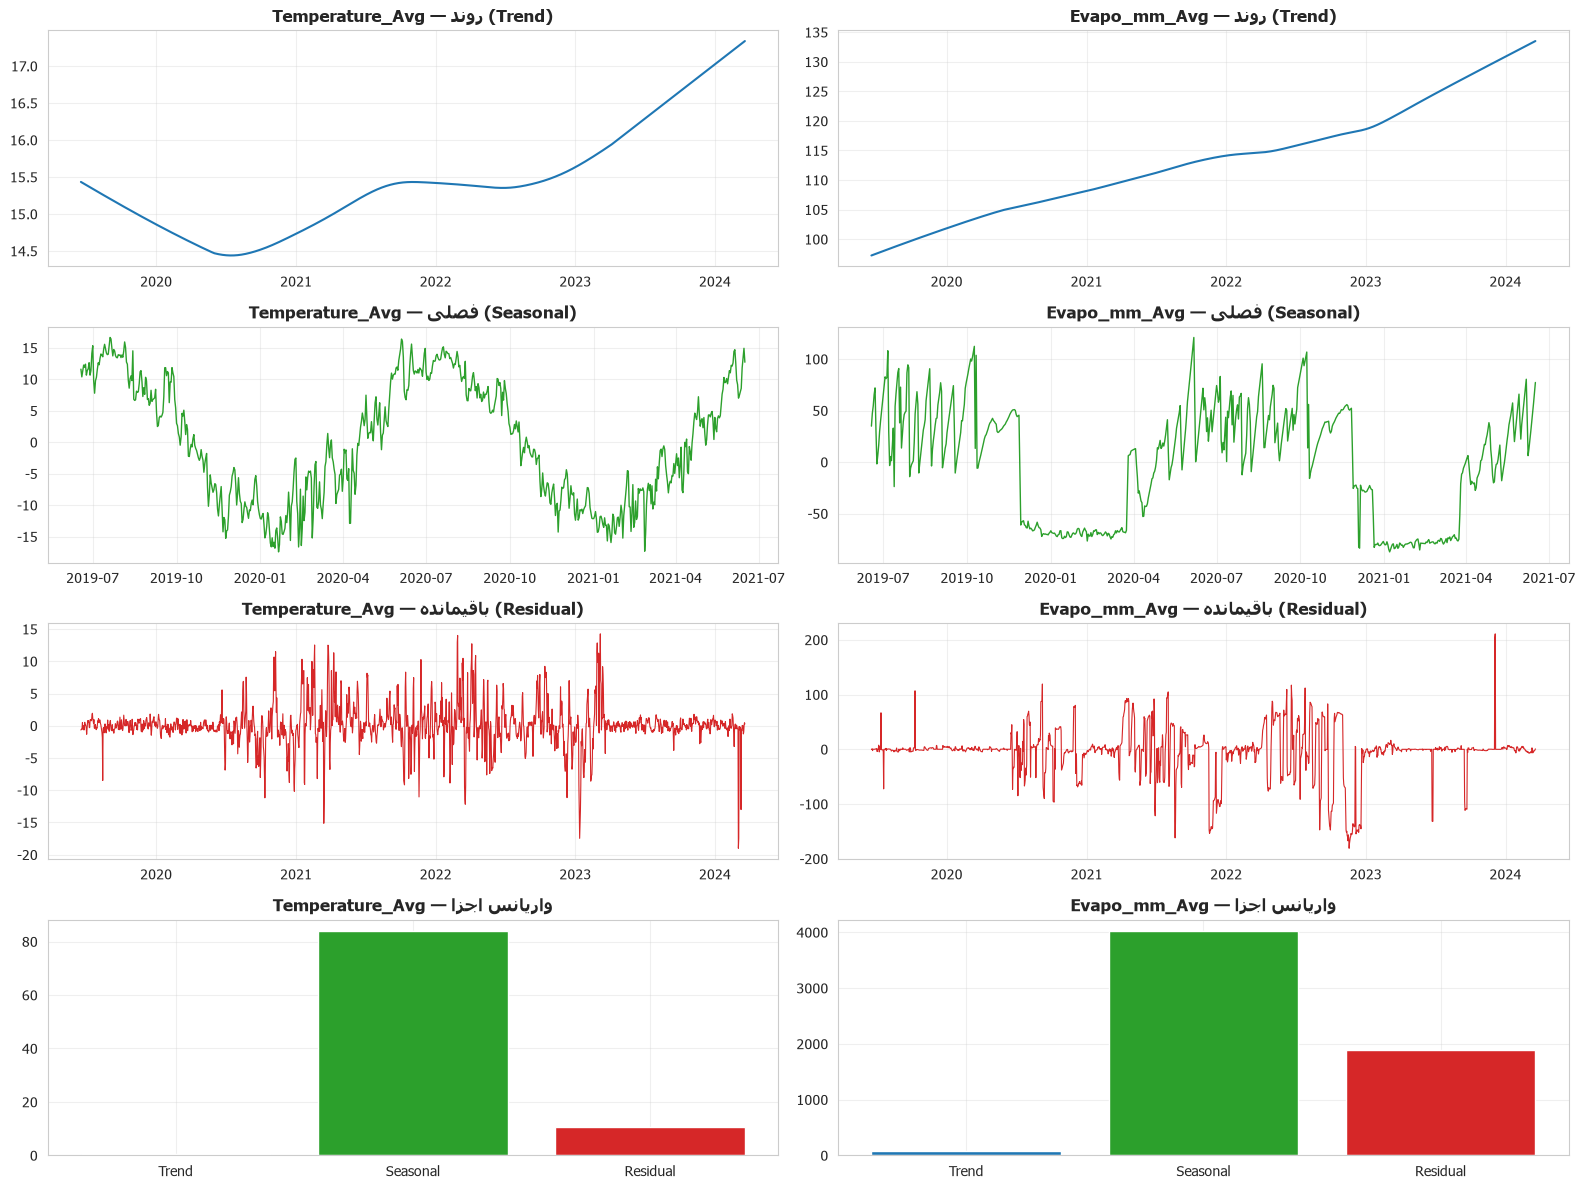

قدرت اجزا STL
دما  — Trend Strength: 0.000
دما  — Seasonal Strength: 0.874
تبخیر — Trend Strength: 0.000
تبخیر — Seasonal Strength: 0.531


In [50]:
# ============================================================
# ۴.۱ STL Decomposition
# ============================================================

# روی تبخیر و دما
fig, axes = plt.subplots(4, 2, figsize=(16, 12))

for i, var in enumerate(['Temperature_Avg', 'Evapo_mm_Avg']):
    ts = df.set_index('Date_M')[var].asfreq('D').interpolate()
    
    # STL (period=365)
    stl = STL(ts, period=365, robust=True)
    result = stl.fit()
    
    # Trend
    axes[0, i].plot(ts.index, result.trend, color='#1f77b4', linewidth=1.5)
    axes[0, i].set_title(f'{var} — روند (Trend)', fontweight='bold')
    axes[0, i].grid(alpha=0.3)
    
    # Seasonal
    axes[1, i].plot(ts.index[:365*2], result.seasonal[:365*2], 
                    color='#2ca02c', linewidth=1)
    axes[1, i].set_title(f'{var} — فصلی (Seasonal)', fontweight='bold')
    axes[1, i].grid(alpha=0.3)
    
    # Residual
    axes[2, i].plot(ts.index, result.resid, color='#d62728', linewidth=0.8)
    axes[2, i].set_title(f'{var} — باقیمانده (Residual)', fontweight='bold')
    axes[2, i].grid(alpha=0.3)
    
    # Strength
    var_resid = np.var(result.resid)
    var_seasonal = np.var(result.seasonal)
    var_trend = np.var(result.trend)
    
    axes[3, i].bar(['Trend', 'Seasonal', 'Residual'],
                   [var_trend, var_seasonal, var_resid],
                   color=['#1f77b4', '#2ca02c', '#d62728'])
    axes[3, i].set_title(f'{var} — واریانس اجزا', fontweight='bold')
    axes[3, i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_stl_decomposition.png", dpi=120, bbox_inches='tight')
plt.show()

# ذخیره STL
stl_temp = STL(df.set_index('Date_M')['Temperature_Avg'].asfreq('D').interpolate(),
               period=365, robust=True).fit()
stl_evapo = STL(df.set_index('Date_M')['Evapo_mm_Avg'].asfreq('D').interpolate(),
                period=365, robust=True).fit()

# Strength metric (Wang et al., 2006)
def strength(component_var, resid_var):
    return max(0, 1 - resid_var / component_var)

print("="*80)
print("قدرت اجزا STL")
print("="*80)
print(f"دما  — Trend Strength: {strength(np.var(stl_temp.trend), np.var(stl_temp.resid)):.3f}")
print(f"دما  — Seasonal Strength: {strength(np.var(stl_temp.seasonal), np.var(stl_temp.resid)):.3f}")
print(f"تبخیر — Trend Strength: {strength(np.var(stl_evapo.trend), np.var(stl_evapo.resid)):.3f}")
print(f"تبخیر — Seasonal Strength: {strength(np.var(stl_evapo.seasonal), np.var(stl_evapo.resid)):.3f}")

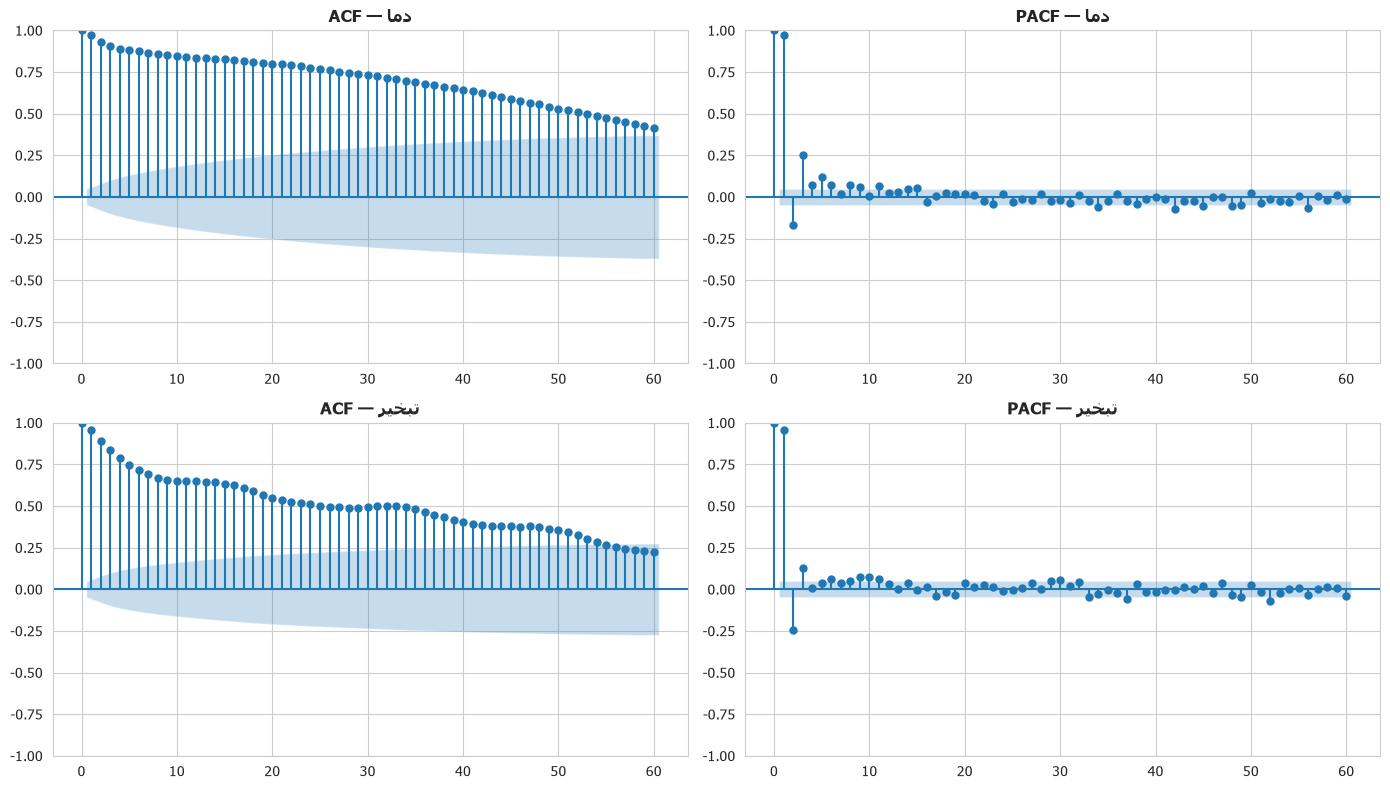

In [51]:
# ============================================================
# ۴.۲ ACF / PACF
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df['Temperature_Avg'].dropna(), lags=60, ax=axes[0, 0])
axes[0, 0].set_title('ACF — دما', fontweight='bold')

plot_pacf(df['Temperature_Avg'].dropna(), lags=60, ax=axes[0, 1])
axes[0, 1].set_title('PACF — دما', fontweight='bold')

plot_acf(df['Evapo_mm_Avg'].dropna(), lags=60, ax=axes[1, 0])
axes[1, 0].set_title('ACF — تبخیر', fontweight='bold')

plot_pacf(df['Evapo_mm_Avg'].dropna(), lags=60, ax=axes[1, 1])
axes[1, 1].set_title('PACF — تبخیر', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_acf_pacf.png", dpi=120, bbox_inches='tight')
plt.show()

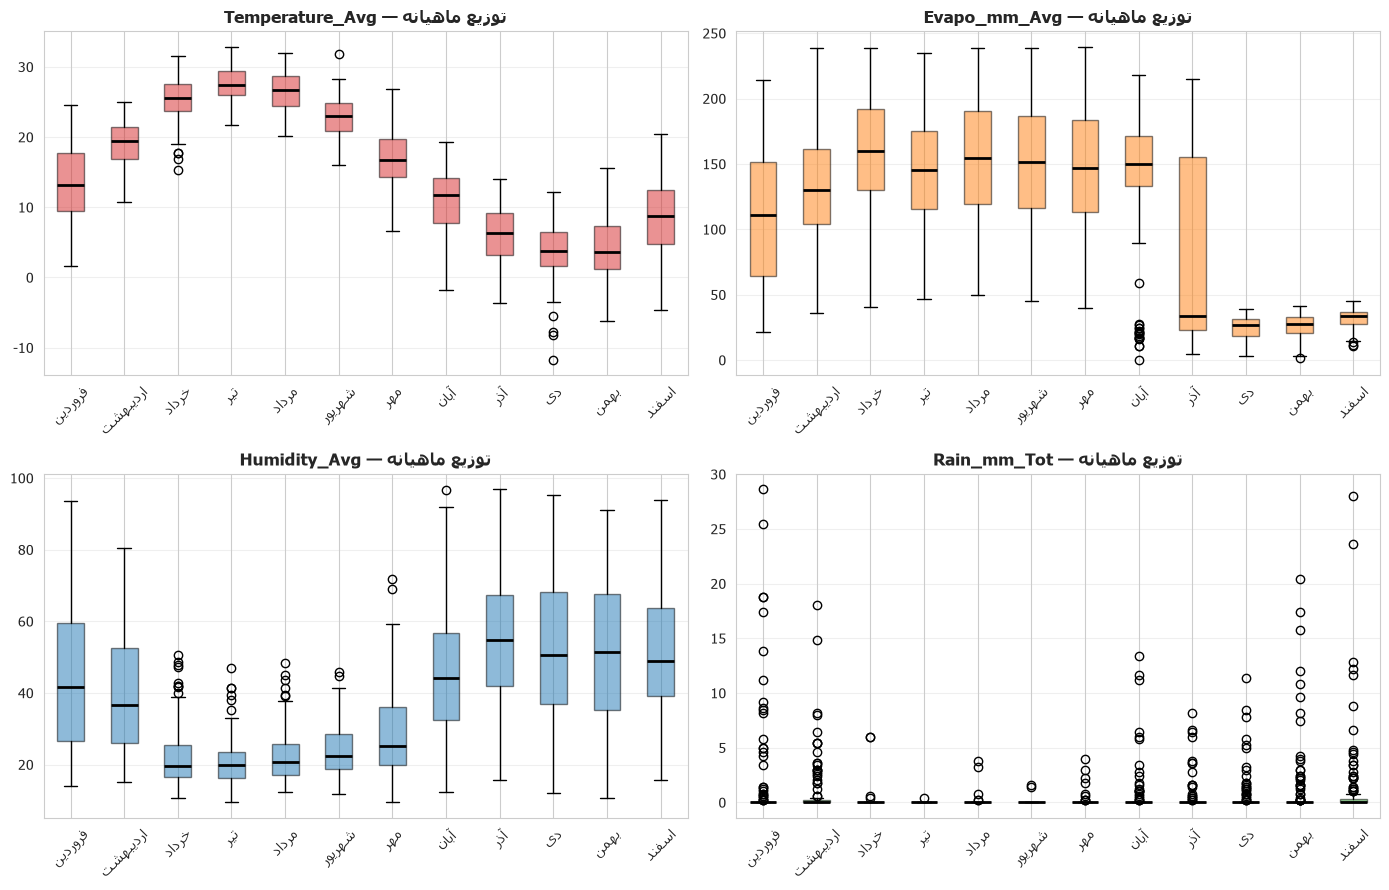

In [56]:
# ============================================================
# ۴.۳ تحلیل ماهیانه
# ============================================================

months_fa = ['فروردین','اردیبهشت','خرداد','تیر','مرداد','شهریور',
             'مهر','آبان','آذر','دی','بهمن','اسفند']

# Profile ماهیانه
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

vars_to_plot = ['Temperature_Avg', 'Evapo_mm_Avg', 'Humidity_Avg', 'Rain_mm_Tot']
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']

for ax, var, color in zip(axes.flatten(), vars_to_plot, colors):
    monthly_data = [df[df['Month_S'] == m][var].values for m in range(1, 13)]
    
    bp = ax.boxplot(monthly_data, tick_labels=months_fa, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.5),
                    medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{var} — توزیع ماهیانه', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_monthly_profile.png", dpi=120, bbox_inches='tight')
plt.show()

رخدادهای حدی شناسایی‌شده
     رخداد  تعداد روز   درصد
 Dry Spell        756 43.520
High Evapo        183 10.540
   Hot Day         92  5.300
  Cold Day         92  5.300
 Windy Day         92  5.300
Heavy Rain         79  4.550
 Heat Wave         42  2.420
 Cold Snap         40  2.300


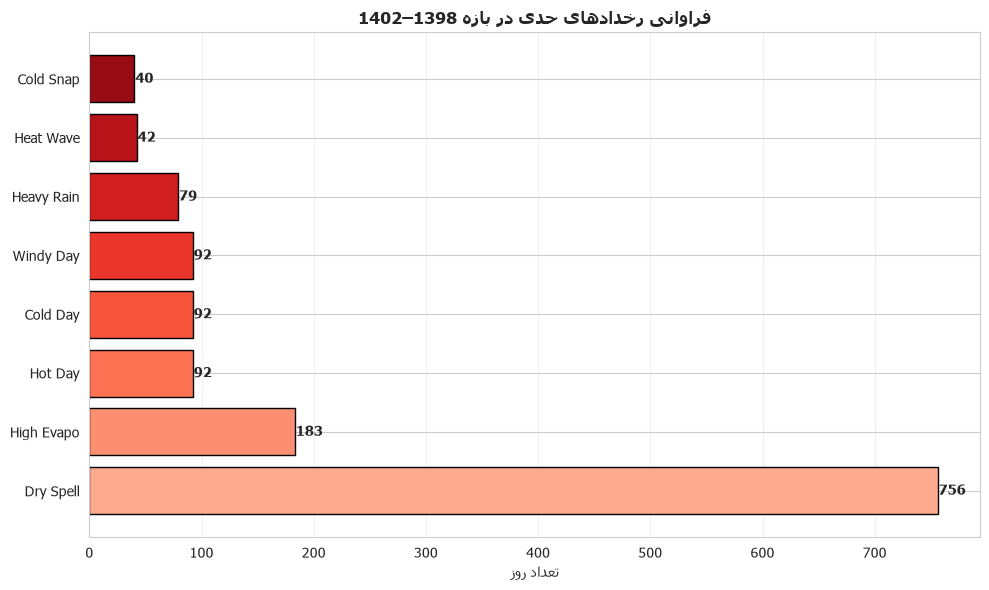

In [57]:
# ============================================================
# ۵. تحلیل رخدادهای حدی
# ============================================================

# رخدادها
events = {
    'Hot Day': df['Hot_Day'].sum(),
    'Heat Wave': df['Heat_Wave'].sum(),
    'Cold Day': df['Cold_Day'].sum(),
    'Cold Snap': df['Cold_Snap'].sum(),
    'Heavy Rain': df['Heavy_Rain'].sum(),
    'Windy Day': df['Windy_Day'].sum(),
    'High Evapo': df['High_Evapo'].sum(),
    'Dry Spell': df['Dry_Spell'].sum(),
}

events_df = pd.DataFrame({
    'رخداد': list(events.keys()),
    'تعداد روز': list(events.values()),
    'درصد': [round(v/len(df)*100, 2) for v in events.values()]
}).sort_values('تعداد روز', ascending=False)

print("="*80)
print("رخدادهای حدی شناسایی‌شده")
print("="*80)
print(events_df.to_string(index=False))

# نمودار
fig, ax = plt.subplots(figsize=(10, 6))
colors_ev = plt.cm.Reds(np.linspace(0.3, 0.9, len(events_df)))
ax.barh(events_df['رخداد'], events_df['تعداد روز'],
        color=colors_ev, edgecolor='black')
for i, v in enumerate(events_df['تعداد روز']):
    ax.text(v + 1, i, str(v), va='center', fontweight='bold')
ax.set_xlabel('تعداد روز')
ax.set_title('فراوانی رخدادهای حدی در بازه 1398–1402', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_extreme_events.png", dpi=120, bbox_inches='tight')
plt.show()

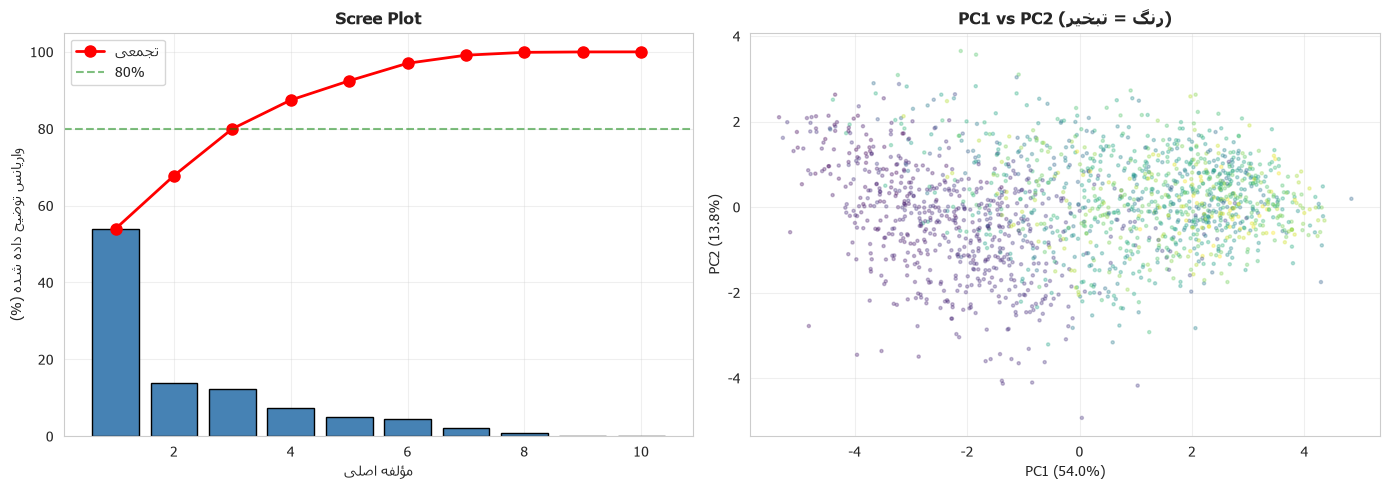

PCA Loadings (2 مؤلفه اول)
                     PC1    PC2
Temperature_Avg    0.416  0.160
Humidity_Avg      -0.366  0.383
Evapo_mm_Avg       0.300  0.158
Wind_Kmh_Avg      -0.031  0.070
Watts_m2_Avg       0.372  0.079
Baro_KPa_Avg      -0.148 -0.085
VPD                0.408  0.015
PET_Hargreaves     0.423  0.013
Dew_Point          0.142  0.745
Thermal_Amplitude  0.275 -0.478


In [58]:
# ============================================================
# ۶.۱ PCA
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# انتخاب متغیرهای اصلی
pca_vars = ['Temperature_Avg', 'Humidity_Avg', 'Evapo_mm_Avg',
            'Wind_Kmh_Avg', 'Watts_m2_Avg', 'Baro_KPa_Avg',
            'VPD', 'PET_Hargreaves', 'Dew_Point', 'Thermal_Amplitude']

X = df[pca_vars].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# واریانس توضیح داده شده
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_ * 100, 
            color='steelblue', edgecolor='black')
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1),
             np.cumsum(pca.explained_variance_ratio_) * 100,
             'ro-', linewidth=2, markersize=8, label='تجمعی')
axes[0].axhline(80, color='green', linestyle='--', alpha=0.5, label='80%')
axes[0].set_xlabel('مؤلفه اصلی')
axes[0].set_ylabel('واریانس توضیح داده شده (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Biplot (2 مؤلفه اول)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, c=df['Evapo_mm_Avg'],
                cmap='viridis')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 (رنگ = تبخیر)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_pca.png", dpi=120, bbox_inches='tight')
plt.show()

# Loadings
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=pca_vars
)
print("="*80)
print("PCA Loadings (2 مؤلفه اول)")
print("="*80)
print(loadings.round(3).to_string())

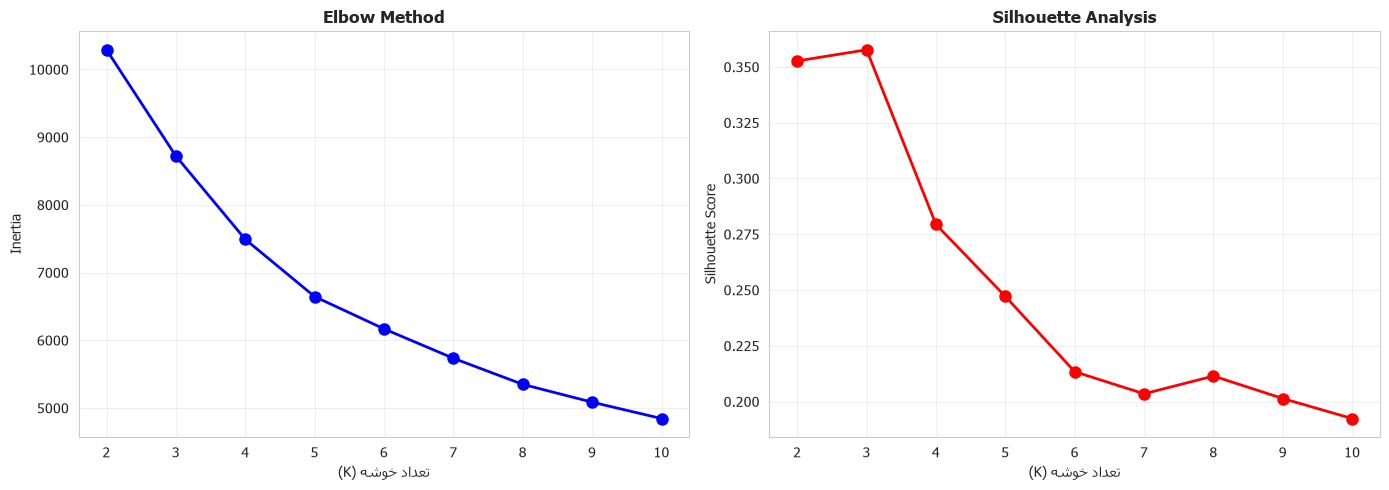

بهترین K: 3 (Silhouette=0.358)

مشخصات خوشه‌ها
         Temperature_Avg  Humidity_Avg  Evapo_mm_Avg  Wind_Kmh_Avg  Watts_m2_Avg  Baro_KPa_Avg   VPD  PET_Hargreaves  Dew_Point  Thermal_Amplitude
Cluster                                                                                                                                           
0                  6.770        53.730        57.030         6.180       112.660        85.580 0.500           0.700     -2.820              1.460
1                 23.410        24.360       149.810        10.100       246.600        85.180 2.290           1.280      0.940              1.760
2                  9.850        44.300       103.680        51.910       115.880        85.050 0.780           0.800     -2.870              1.510


In [62]:
# ============================================================
# ۱۲. K-Means (بدون n_jobs — سازگار با sklearn 1.4+)
# ============================================================
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('تعداد خوشه (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('تعداد خوشه (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/eda_clustering.png", dpi=120, bbox_inches='tight')
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"بهترین K: {best_k} (Silhouette={max(silhouettes):.3f})")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

cluster_profile = df.groupby('Cluster')[pca_vars].mean().round(2)
print("\n" + "="*80)
print("مشخصات خوشه‌ها")
print("="*80)
print(cluster_profile.to_string())

In [63]:
# ============================================================
# ۷. گزارش نهایی EDA
# ============================================================

# خلاصه یافته‌ها
findings = pd.DataFrame({
    'یافته': [
        'دوره آماری',
        'تعداد نمونه',
        'تعداد ویژگی',
        'قوی‌ترین همبستگی با تبخیر',
        'Seasonal Strength (تبخیر)',
        'بهترین تعداد خوشه',
        'تعداد رخدادهای حدی',
        'روند دما',
        'روند تبخیر',
    ],
    'مقدار': [
        f"{df['Date_M'].min().date()} تا {df['Date_M'].max().date()}",
        f"{len(df):,} روز",
        "214",
        f"{corr_with_target.idxmax()} ({corr_with_target.max():.3f})",
        f"{strength(np.var(stl_evapo.seasonal), np.var(stl_evapo.resid)):.3f}",
        f"{best_k}",
        f"{sum(events.values())} روز ({sum(events.values())/len(df)*100:.1f}%)",
        f"شیب: {np.polyfit(range(len(stl_temp.trend)), stl_temp.trend, 1)[0]*365:.3f} °C/سال",
        f"شیب: {np.polyfit(range(len(stl_evapo.trend)), stl_evapo.trend, 1)[0]*365:.3f} mm/سال",
    ]
})

print("="*80)
print("✅ خلاصه یافته‌های EDA")
print("="*80)
print(findings.to_string(index=False))

findings.to_excel(f"{output_dir}/reports/eda_summary.xlsx", index=False)

# ذخیره دیتاست با خوشه‌ها
df.to_parquet(f"{output_dir}/data/processed/weather_features_clustered.parquet",
              index=False, compression='snappy')
print(f"\n✅ دیتاست با خوشه‌ها ذخیره شد")

✅ خلاصه یافته‌های EDA
                    یافته                        مقدار
               دوره آماری     2019-06-18 تا 2024-03-19
              تعداد نمونه                    1,737 روز
              تعداد ویژگی                          214
قوی‌ترین همبستگی با تبخیر Evapo_mm_Avg_anomaly (1.000)
Seasonal Strength (تبخیر)                        0.531
        بهترین تعداد خوشه                            3
       تعداد رخدادهای حدی             1376 روز (79.2%)
                 روند دما            شیب: 0.447 °C/سال
               روند تبخیر            شیب: 6.636 mm/سال

✅ دیتاست با خوشه‌ها ذخیره شد


In [64]:
# آستانه‌های سختگیرانه‌تر (صدک ۹۸ به جای ۹۵)
temp_p98 = df['Temperature_Max'].quantile(0.98)
rain_p98 = df['Rain_mm_Tot'].quantile(0.98)
wind_p98 = df['Wind_Kmh_Max'].quantile(0.98)
evapo_p95 = df['Evapo_mm_Avg'].quantile(0.95)

df['Hot_Day']     = (df['Temperature_Max'] > temp_p98).astype(int)
df['Heavy_Rain']  = (df['Rain_mm_Tot'] > rain_p98).astype(int)
df['Windy_Day']   = (df['Wind_Kmh_Max'] > wind_p98).astype(int)
df['High_Evapo']  = (df['Evapo_mm_Avg'] > evapo_p95).astype(int)

# Dry_Spell باید جدا باشه (نه در مجموع رخدادها)
df['Dry_Spell'] = (df['Days_Since_Rain'] > 30).astype(int)  # آستانه 30 روز

# Heat_Wave: حداقل 3 روز متوالی داغ
df['Heat_Wave'] = (df['Hot_Day'].rolling(3).sum() >= 3).astype(int)

events = {
    'Hot Day (P98)':     df['Hot_Day'].sum(),
    'Heat Wave':         df['Heat_Wave'].sum(),
    'Heavy Rain (P98)':  df['Heavy_Rain'].sum(),
    'Windy Day (P98)':   df['Windy_Day'].sum(),
    'High Evapo (P95)':  df['High_Evapo'].sum(),
    'Dry Spell (>30d)':  df['Dry_Spell'].sum(),
}

events_df = pd.DataFrame({
    'رخداد': list(events.keys()),
    'تعداد روز': list(events.values()),
    'درصد': [round(v/len(df)*100, 2) for v in events.values()]
}).sort_values('تعداد روز', ascending=False)

print("="*80)
print("رخدادهای حدی (آستانه‌های سختگیرانه)")
print("="*80)
print(events_df.to_string(index=False))
print(f"\nمجموع: {sum(events.values())} روز ({sum(events.values())/len(df)*100:.1f}%)")

رخدادهای حدی (آستانه‌های سختگیرانه)
           رخداد  تعداد روز   درصد
Dry Spell (>30d)        475 27.350
High Evapo (P95)         87  5.010
 Windy Day (P98)         35  2.010
   Hot Day (P98)         35  2.010
Heavy Rain (P98)         35  2.010
       Heat Wave         12  0.690

مجموع: 679 روز (39.1%)


In [65]:
# روند خطی ساده به جای STL
from scipy.stats import linregress

# تبخیر ماهانه (کاهش نویز)
evapo_monthly = df.groupby(['Year_S', 'Month_S'])['Evapo_mm_Avg'].mean().reset_index()
evapo_monthly['t'] = range(len(evapo_monthly))

slope, intercept, r_value, p_value, std_err = linregress(
    evapo_monthly['t'], evapo_monthly['Evapo_mm_Avg']
)

print(f"روند خطی تبخیر: {slope*12:.3f} mm/سال")
print(f"R² = {r_value**2:.3f}")
print(f"P-value = {p_value:.4f}")
print(f"{'✅ روند معنادار' if p_value < 0.05 else '❌ روند معنادار نیست'}")

# همین برای دما
temp_monthly = df.groupby(['Year_S', 'Month_S'])['Temperature_Avg'].mean().reset_index()
temp_monthly['t'] = range(len(temp_monthly))

slope_t, _, r_t, p_t, _ = linregress(temp_monthly['t'], temp_monthly['Temperature_Avg'])
print(f"\nروند خطی دما: {slope_t*12:.3f} °C/سال")
print(f"R² = {r_t**2:.3f}")
print(f"P-value = {p_t:.4f}")
print(f"{'✅ روند معنادار' if p_t < 0.05 else '❌ روند معنادار نیست'}")

روند خطی تبخیر: -1.088 mm/سال
R² = 0.001
P-value = 0.8427
❌ روند معنادار نیست

روند خطی دما: -0.568 °C/سال
R² = 0.008
P-value = 0.5015
❌ روند معنادار نیست


In [66]:
# ============================================================
# اصلاحات پس از EDA
# ============================================================

# --- ۱. حذف ستون‌های نشتی (leakage) ---
leak_patterns = ['anomaly', 'zscore_monthly', 'pctrank']
leak_cols = [c for c in df.columns 
             if 'Evapo' in c and any(p in c for p in leak_patterns)]
# حذف نسبت‌های مشتق از Evapo
leak_cols += ['Evapo_per_Watts', 'Evapo_per_Temp', 'Evapo_cum_7', 'Evapo_cum_30']

leak_cols = [c for c in leak_cols if c in df.columns]
print(f"🚨 حذف {len(leak_cols)} ستون نشتی:")
for c in leak_cols:
    print(f"   - {c}")

df = df.drop(columns=leak_cols)
print(f"\n✅ ابعاد جدید: {df.shape}")

# --- ۲. آستانه‌های سختگیرانه‌تر برای رخدادهای حدی ---
temp_p98 = df['Temperature_Max'].quantile(0.98)
rain_p98 = df['Rain_mm_Tot'].quantile(0.98)
wind_p98 = df['Wind_Kmh_Max'].quantile(0.98)
evapo_p95 = df['Evapo_mm_Avg'].quantile(0.95)

df['Hot_Day']     = (df['Temperature_Max'] > temp_p98).astype(int)
df['Heavy_Rain']  = (df['Rain_mm_Tot'] > rain_p98).astype(int)
df['Windy_Day']   = (df['Wind_Kmh_Max'] > wind_p98).astype(int)
df['High_Evapo']  = (df['Evapo_mm_Avg'] > evapo_p95).astype(int)
df['Heat_Wave']   = (df['Hot_Day'].rolling(3).sum() >= 3).astype(int)
df['Dry_Spell']   = (df['Days_Since_Rain'] > 30).astype(int)

events = {
    'Hot Day (P98)':     df['Hot_Day'].sum(),
    'Heat Wave':         df['Heat_Wave'].sum(),
    'Heavy Rain (P98)':  df['Heavy_Rain'].sum(),
    'Windy Day (P98)':   df['Windy_Day'].sum(),
    'High Evapo (P95)':  df['High_Evapo'].sum(),
    'Dry Spell (>30d)':  df['Dry_Spell'].sum(),
}

events_df = pd.DataFrame({
    'رخداد': list(events.keys()),
    'تعداد روز': list(events.values()),
    'درصد': [round(v/len(df)*100, 2) for v in events.values()]
}).sort_values('تعداد روز', ascending=False)

print("\n" + "="*80)
print("رخدادهای حدی (آستانه‌های جدید)")
print("="*80)
print(events_df.to_string(index=False))

# --- ۳. محاسبه همبستگی جدید (بدون leakage) ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_new = df[numeric_cols].corrwith(df['Evapo_mm_Avg']).drop('Evapo_mm_Avg').sort_values()

print("\n" + "="*80)
print("Top 10 همبستگی با تبخیر (بدون leakage)")
print("="*80)
print("--- مثبت ---")
print(corr_new.tail(10).round(3).to_string())
print("\n--- منفی ---")
print(corr_new.head(10).round(3).to_string())

# --- ۴. ذخیره دیتاست اصلاح‌شده ---
df.to_parquet(f"{output_dir}/data/processed/weather_features_final.parquet",
              index=False, compression='snappy')
print(f"\n✅ دیتاست نهایی ذخیره شد: {df.shape}")

🚨 حذف 7 ستون نشتی:
   - Evapo_mm_Avg_zscore_monthly
   - Evapo_mm_Avg_anomaly
   - Evapo_mm_Avg_pctrank
   - Evapo_per_Watts
   - Evapo_per_Temp
   - Evapo_cum_7
   - Evapo_cum_30

✅ ابعاد جدید: (1737, 214)

رخدادهای حدی (آستانه‌های جدید)
           رخداد  تعداد روز   درصد
Dry Spell (>30d)        475 27.350
High Evapo (P95)         87  5.010
 Windy Day (P98)         35  2.010
   Hot Day (P98)         35  2.010
Heavy Rain (P98)         35  2.010
       Heat Wave         12  0.690

Top 10 همبستگی با تبخیر (بدون leakage)
--- مثبت ---
Evapo_mm_Avg_roll30_mean   0.772
Evapo_mm_Avg_ewma30        0.830
Evapo_mm_Avg_lag3          0.835
Evapo_mm_Avg_roll14_mean   0.845
Evapo_mm_Avg_roll7_mean    0.903
Evapo_mm_Avg_ewma7         0.943
Evapo_mm_Avg_lag1          0.955
Evapo_mm_Avg_roll3_mean    0.970
Evapo_mm_Max               1.000
Evapo_mm_Min               1.000

--- منفی ---
Humidity_Avg_ewma30        -0.680
Humidity_Avg_roll30_mean   -0.672
Humidity_Avg_roll14_mean   -0.646
DOY_cos          

In [67]:
# ============================================================
# حذف کامل نشتی داده
# ============================================================

# ستون‌هایی که از هدف (Evapo_mm_Avg) در همون روز مشتق شدن
leak_cols_final = [
    'Evapo_mm_Min',       # همون روز، مشتق از تبخیر
    'Evapo_mm_Max',       # همون روز، مشتق از تبخیر
    'Evapo_mm_Avg_anomaly',
    'Evapo_mm_Avg_zscore_monthly',
    'Evapo_mm_Avg_pctrank',
    'Evapo_per_Watts',
    'Evapo_per_Temp',
    'Evapo_cum_7',
    'Evapo_cum_30',
]

# فقط ستون‌هایی که وجود دارن رو حذف کن
leak_cols_final = [c for c in leak_cols_final if c in df.columns]
df = df.drop(columns=leak_cols_final)

print(f"✅ حذف نهایی {len(leak_cols_final)} ستون نشتی:")
for c in leak_cols_final:
    print(f"   - {c}")

print(f"\nابعاد نهایی: {df.shape}")

# همبستگی مجدد
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_final = df[numeric_cols].corrwith(df['Evapo_mm_Avg']).drop('Evapo_mm_Avg').sort_values()

print("\n" + "="*80)
print("Top 15 همبستگی با تبخیر (پس از حذف کامل leakage)")
print("="*80)
print("--- مثبت ---")
print(corr_final.tail(15).round(3).to_string())
print("\n--- منفی ---")
print(corr_final.head(15).round(3).to_string())

# ذخیره دیتاست نهایی
df.to_parquet(f"{output_dir}/data/processed/weather_features_final.parquet",
              index=False, compression='snappy')
print(f"\n✅ دیتاست نهایی: {df.shape}")

# ذخیره لیست feature نهایی
final_features = [c for c in df.select_dtypes(include=[np.number]).columns 
                  if c != 'Evapo_mm_Avg']
with open(f"{output_dir}/reports/final_features.txt", 'w', encoding='utf-8') as f:
    for feat in final_features:
        f.write(f"{feat}\n")
print(f"✅ {len(final_features)} ویژگی نهایی ذخیره شد")

✅ حذف نهایی 2 ستون نشتی:
   - Evapo_mm_Min
   - Evapo_mm_Max

ابعاد نهایی: (1737, 212)

Top 15 همبستگی با تبخیر (پس از حذف کامل leakage)
--- مثبت ---
Evapo_mm_Avg_lag7             0.691
Temperature_Avg_lag14         0.697
Temperature_Avg_roll14_mean   0.707
PET_Hargreaves_roll14_mean    0.707
Temperature_Avg_ewma30        0.725
Temperature_Avg_roll30_mean   0.727
PET_Hargreaves_roll30_mean    0.730
Evapo_mm_Avg_roll30_mean      0.772
Evapo_mm_Avg_ewma30           0.830
Evapo_mm_Avg_lag3             0.835
Evapo_mm_Avg_roll14_mean      0.845
Evapo_mm_Avg_roll7_mean       0.903
Evapo_mm_Avg_ewma7            0.943
Evapo_mm_Avg_lag1             0.955
Evapo_mm_Avg_roll3_mean       0.970

--- منفی ---
Humidity_Avg_ewma30        -0.680
Humidity_Avg_roll30_mean   -0.672
Humidity_Avg_roll14_mean   -0.646
DOY_cos                    -0.615
Humidity_Avg_ewma7         -0.613
Humidity_Avg_roll7_mean    -0.600
Month_cos                  -0.592
Month_S                    -0.578
Humidity_Avg_roll3_mean 

In [70]:
import os
output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"

# چک فایل‌های موجود
processed_dir = f"{output_dir}/data/processed"
print("فایل‌های موجود در processed:")
for f in os.listdir(processed_dir):
    size = os.path.getsize(f"{processed_dir}/{f}") / 1024
    print(f"  ✅ {f} ({size:.1f} KB)")

فایل‌های موجود در processed:
  ✅ weather_clean_1398_1402.csv (617.6 KB)
  ✅ weather_clean_1398_1402.parquet (443.0 KB)
  ✅ weather_clean_1398_1402.xlsx (477.4 KB)
  ✅ weather_features_1398_1402.csv (5527.9 KB)
  ✅ weather_features_1398_1402.parquet (2976.3 KB)
  ✅ weather_features_clustered.parquet (2976.9 KB)
  ✅ weather_features_final.parquet (2830.8 KB)


✅ بارگذاری: (1737, 212)

🚨 حذف 79 ویژگی با همبستگی متقابل > 0.95

Top 30 Feature Importance (XGBoost, میانگین 5 fold)
                                fold_0  fold_1  fold_2  fold_3  fold_4  mean   std
Evapo_mm_Avg_roll3_mean          0.712   0.489   0.687   0.706   0.706 0.660 0.096
Evapo_mm_Avg_roll3_std           0.024   0.031   0.060   0.070   0.061 0.049 0.020
Month_S                          0.000   0.083   0.060   0.049   0.041 0.047 0.030
Rain_cum_30                      0.000   0.132   0.001   0.000   0.003 0.027 0.059
Evapo_mm_Avg_diff7               0.015   0.042   0.031   0.025   0.017 0.026 0.011
Evapo_mm_Avg_roll7_std           0.091   0.002   0.014   0.002   0.006 0.023 0.038
High_Evapo                       0.000   0.007   0.016   0.038   0.052 0.023 0.022
Evapo_mm_Avg_diff1               0.024   0.016   0.032   0.022   0.014 0.022 0.007
Rain_cum_90                      0.000   0.096   0.000   0.001   0.001 0.020 0.043
VPD_roll30_std                   0.051   0.002   0.0

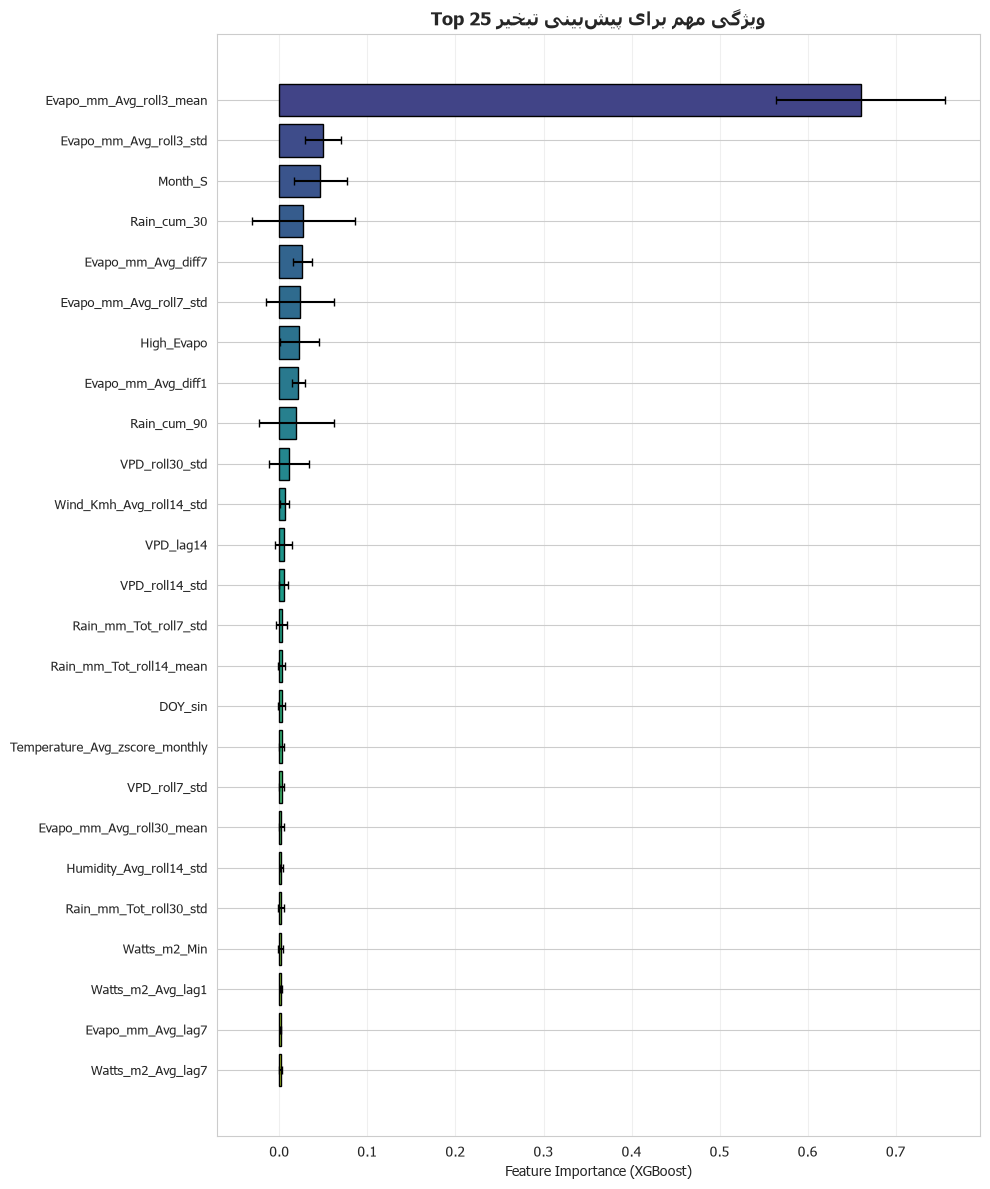

ValueError: Duplicate column names found: ['Date_M', 'Year_S', 'Month_S', 'Day_S', 'Evapo_mm_Avg_roll3_mean', 'Evapo_mm_Avg_roll3_std', 'Month_S', 'Rain_cum_30', 'Evapo_mm_Avg_diff7', 'Evapo_mm_Avg_roll7_std', 'High_Evapo', 'Evapo_mm_Avg_diff1', 'Rain_cum_90', 'VPD_roll30_std', 'Wind_Kmh_Avg_roll14_std', 'VPD_lag14', 'VPD_roll14_std', 'Rain_mm_Tot_roll7_std', 'Rain_mm_Tot_roll14_mean', 'DOY_sin', 'Temperature_Avg_zscore_monthly', 'VPD_roll7_std', 'Evapo_mm_Avg_roll30_mean', 'Humidity_Avg_roll14_std', 'Rain_mm_Tot_roll30_std', 'Watts_m2_Min', 'Watts_m2_Avg_lag1', 'Evapo_mm_Avg_lag7', 'Watts_m2_Avg_lag7', 'Water Level(m)', 'DayOfWeek', 'Humidity_Avg_pctrank', 'Watts_m2_Avg_roll14_mean', 'Humidity_Avg_lag14', 'Temperature_Avg_roll14_std', 'Watts_m2_Avg_roll7_std', 'Wind_Kmh_Avg_roll7_std', 'Wind_Kmh_Avg_roll7_mean', 'Humidity_Avg_ewma30', 'VPD_x_Wind', 'Baro_KPa_Avg_roll14_std', 'Humidity_per_Temp', 'Humidity_Avg_zscore_monthly', 'Month_sin', 'VPD_lag30', 'Wind_dir_Min', 'Baro_KPa_Avg_lag

In [71]:
# ============================================================
# Notebook 04 — Feature Selection
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"

# ============================================================
# ۱. بارگذاری دیتاست نهایی
# ============================================================
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

print(f"✅ بارگذاری: {df.shape}")

TARGET = 'Evapo_mm_Avg'

# ============================================================
# ۲. حذف ستون‌های غیرعددی و metadata
# ============================================================
drop_cols = ['Date_M', 'Date_S', 'Season_S', 'Cluster']  # metadata
drop_cols = [c for c in drop_cols if c in df.columns]

# ============================================================
# ۳. حذف ستون‌های با همبستگی متقابل > 0.95
# ============================================================
def remove_high_correlation(df, threshold=0.95, target_col=TARGET):
    """حذف features با همبستگی متقابل بالا (نگه‌داشتن اونی که با هدف بهتره)"""
    numeric_df = df.select_dtypes(include=[np.number])
    
    # حذف هدف از محاسبه
    feature_cols = [c for c in numeric_df.columns if c != target_col]
    
    corr_matrix = numeric_df[feature_cols].corr().abs()
    
    # مثلث بالا
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # ستون‌هایی که باید حذف بشن
    to_drop = set()
    for col in upper.columns:
        high_corr = upper.index[upper[col] > threshold].tolist()
        for hc in high_corr:
            # کدوم رو نگه داریم؟ اونی که همبستگی بیشتری با هدف داره
            corr_col = abs(numeric_df[col].corr(numeric_df[target_col]))
            corr_hc  = abs(numeric_df[hc].corr(numeric_df[target_col]))
            if corr_col >= corr_hc:
                to_drop.add(hc)
            else:
                to_drop.add(col)
                break
    
    return list(to_drop)

# حذف همبستگی متقابل
initial_features = [c for c in df.select_dtypes(include=[np.number]).columns 
                    if c not in drop_cols + [TARGET]]

to_drop_corr = remove_high_correlation(df, threshold=0.95, target_col=TARGET)

print(f"\n🚨 حذف {len(to_drop_corr)} ویژگی با همبستگی متقابل > 0.95")

# ============================================================
# ۴. Feature Importance اولیه با XGBoost
# ============================================================
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

# دیتاست موقت بدون ستون‌های همبسته
df_temp = df.drop(columns=to_drop_corr)
feature_cols_temp = [c for c in df_temp.select_dtypes(include=[np.number]).columns
                     if c not in drop_cols + [TARGET]]

X_temp = df_temp[feature_cols_temp].fillna(0)
y_temp = df_temp[TARGET]

# TimeSeriesSplit برای جلوگیری از leakage
tscv = TimeSeriesSplit(n_splits=5)

# Feature importance میانگین از 5 fold
importance_scores = pd.DataFrame(index=feature_cols_temp)

for fold, (train_idx, _) in enumerate(tscv.split(X_temp)):
    model = XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=42, n_jobs=4, verbosity=0
    )
    model.fit(X_temp.iloc[train_idx], y_temp.iloc[train_idx])
    importance_scores[f'fold_{fold}'] = model.feature_importances_

importance_scores['mean'] = importance_scores.mean(axis=1)
importance_scores['std'] = importance_scores.drop(columns='mean').std(axis=1)
importance_scores = importance_scores.sort_values('mean', ascending=False)

print("\n" + "="*80)
print("Top 30 Feature Importance (XGBoost, میانگین 5 fold)")
print("="*80)
print(importance_scores.head(30).round(4).to_string())

# ============================================================
# ۵. انتخاب 50 ویژگی برتر
# ============================================================
TOP_N = 50
top_features = importance_scores.head(TOP_N).index.tolist()

# فیلتر نهایی: حذف featureهایی که با هدف همبستگی خیلی بالا دارن (> 0.98)
# این‌ها احتمالاً leakage هستن
final_features = []
for feat in top_features:
    corr_with_target = abs(df[feat].corr(df[TARGET]))
    if corr_with_target < 0.98:
        final_features.append(feat)
    else:
        print(f"⚠️ حذف {feat} — همبستگی با هدف: {corr_with_target:.3f}")

print(f"\n✅ {len(final_features)} ویژگی نهایی انتخاب شد")

# ============================================================
# ۶. نمودار Feature Importance
# ============================================================
fig, ax = plt.subplots(figsize=(10, 12))

top_25 = importance_scores.head(25)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_25)))

ax.barh(range(len(top_25)), top_25['mean'].values, 
        xerr=top_25['std'].values,
        color=colors, edgecolor='black', capsize=3)
ax.set_yticks(range(len(top_25)))
ax.set_yticklabels(top_25.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (XGBoost)')
ax.set_title(f'Top 25 ویژگی مهم برای پیش‌بینی تبخیر', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/feature_importance_xgboost.png", dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# ۷. ذخیره لیست feature نهایی
# ============================================================
with open(f"{output_dir}/reports/selected_features.txt", 'w', encoding='utf-8') as f:
    for feat in final_features:
        f.write(f"{feat}\n")

importance_scores.to_excel(f"{output_dir}/reports/feature_importance.xlsx")

# ذخیره دیتاست فیلترشده
df_selected = df[['Date_M', 'Year_S', 'Month_S', 'Day_S'] + final_features + [TARGET]]
df_selected.to_parquet(f"{output_dir}/data/processed/weather_selected_features.parquet",
                       index=False, compression='snappy')

print(f"\n✅ دیتاست نهایی: {df_selected.shape}")
print(f"✅ ذخیره شد: weather_selected_features.parquet")

✅ بارگذاری: (1737, 212)

گام ۱: Feature Selection (بدون leakage)
🚨 حذف 13 feature leaky (شامل Evapo[t]):
   - Evapo_mm_Avg_roll3_mean
   - Evapo_mm_Avg_roll3_std
   - Evapo_mm_Avg_roll7_mean
   - Evapo_mm_Avg_roll7_std
   - Evapo_mm_Avg_roll14_mean
   - Evapo_mm_Avg_roll14_std
   - Evapo_mm_Avg_roll30_mean
   - Evapo_mm_Avg_roll30_std
   - Evapo_mm_Avg_diff1
   - Evapo_mm_Avg_diff7
   - Evapo_mm_Avg_ewma7
   - Evapo_mm_Avg_ewma30
   - High_Evapo

✅ 193 feature امن

🚨 حذف 72 feature با همبستگی متقابل > 0.95
✅ 121 feature باقی‌مانده

⏳ محاسبه Feature Importance...

Top 15 feature (بدون leakage):
                            mean
Evapo_mm_Avg_lag1          0.449
Evapo_mm_Avg_lag3          0.036
Water Level(m)             0.017
Month_S                    0.017
VPD_roll14_std             0.017
Temperature_Avg_roll14_std 0.016
VPD_roll30_std             0.015
Watts_per_Temp             0.014
Evapo_mm_Avg_lag7          0.014
Rain_mm_Tot_lag7           0.013
Watts_m2_Avg_roll3_std     0.012
Wat

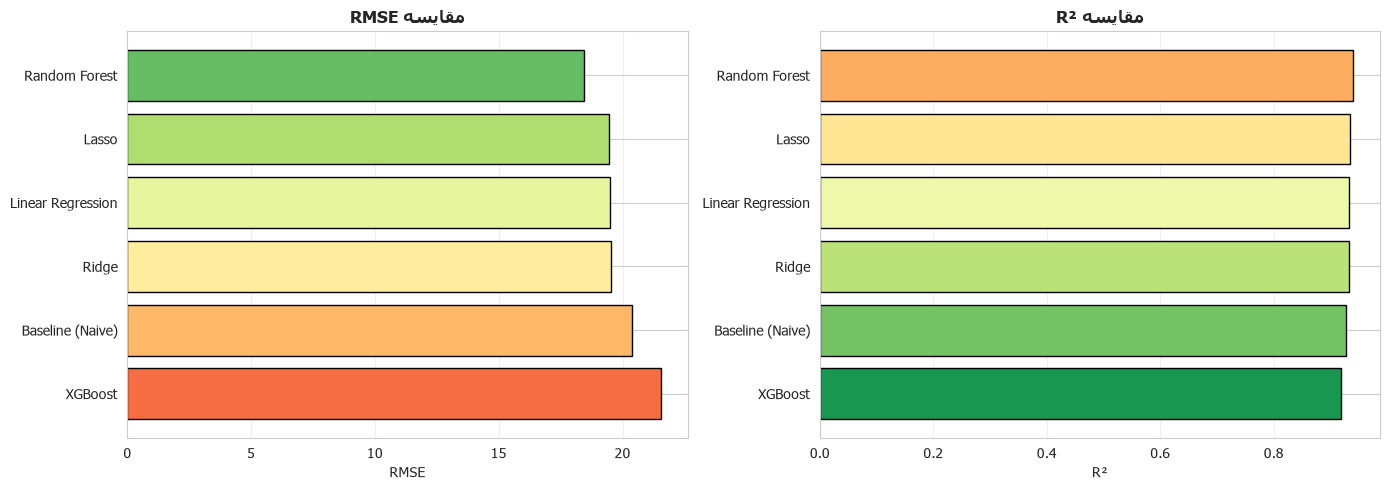


🏆 بهترین مدل: Random Forest

گام ۳: ارزیابی روی Test Set
        Model   RMSE    MAE  MAPE (%)    R²
Random Forest 32.272 19.268    15.680 0.797
      XGBoost 38.470 22.624    17.490 0.712


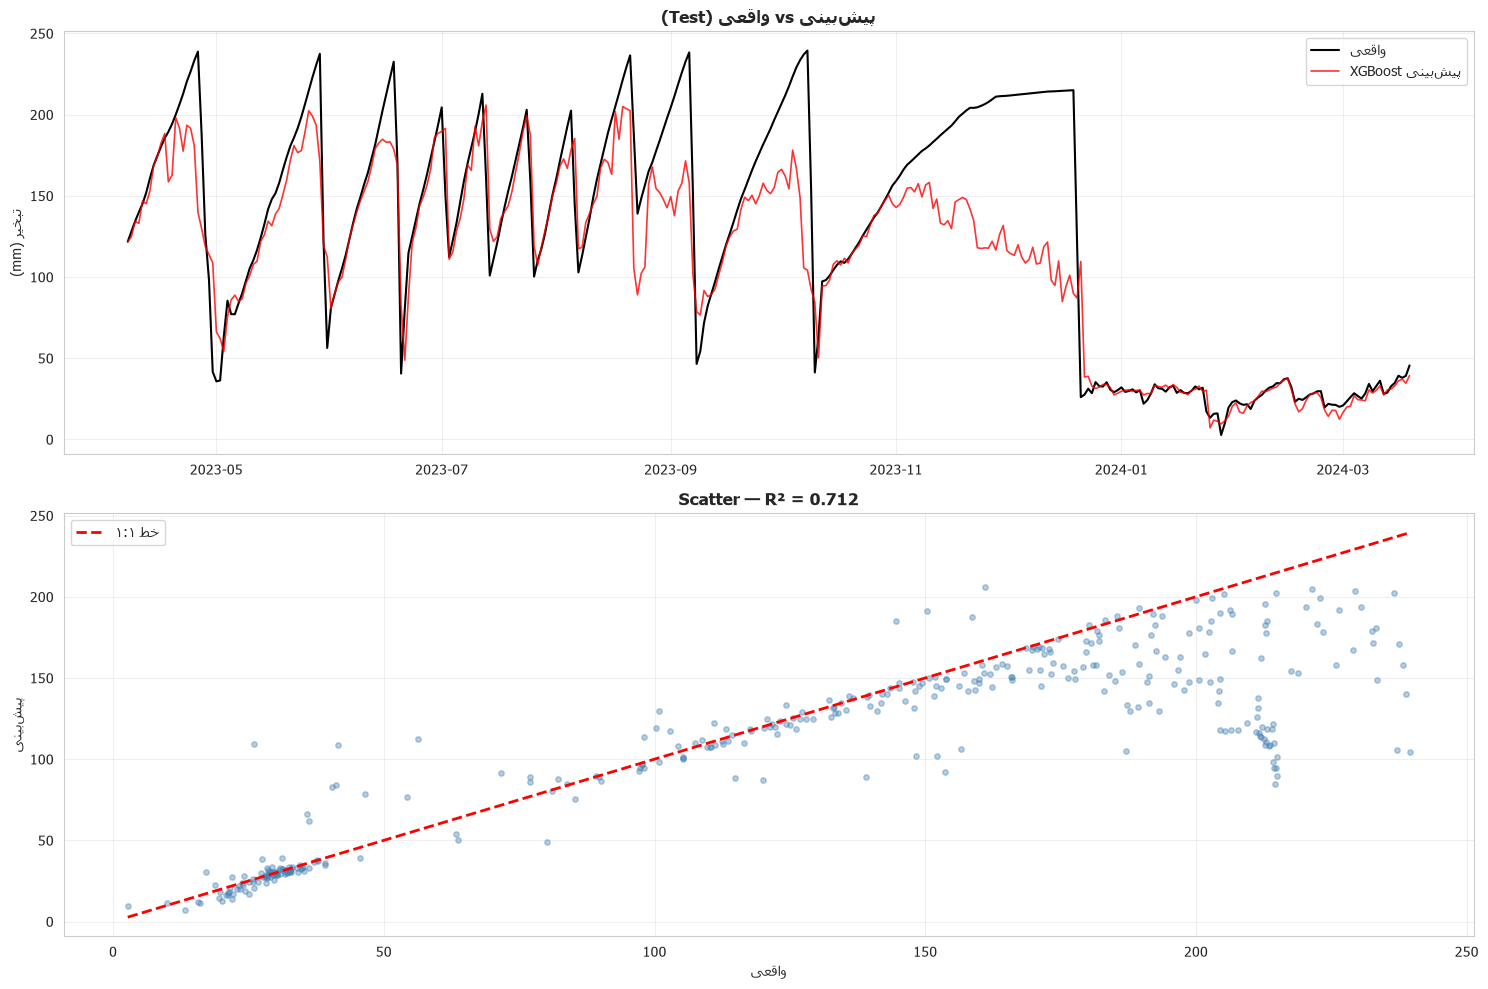

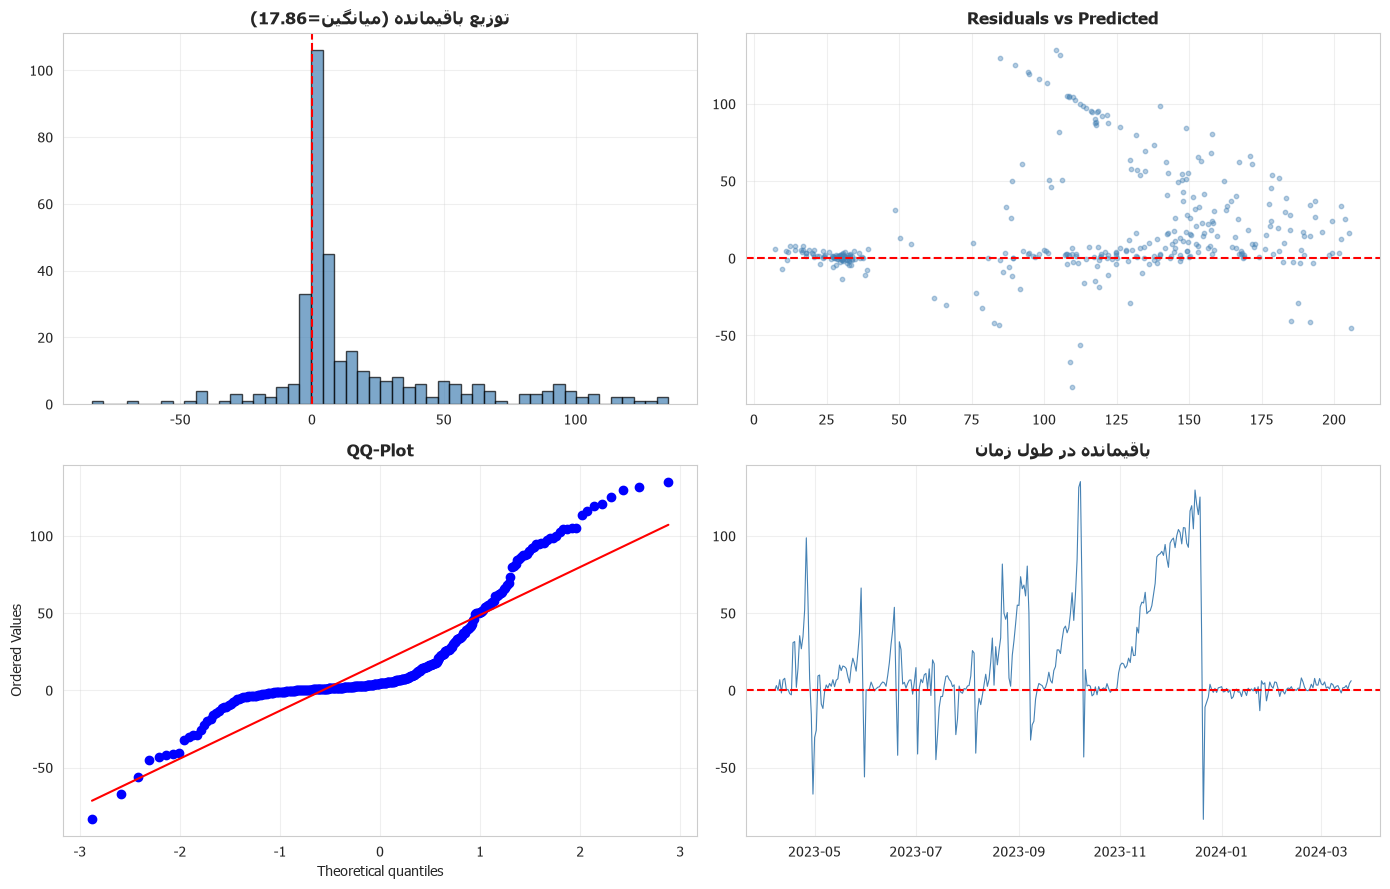


گام ۴: پیش‌بینی ۷ روزه
      Date  Evapo_Forecast
2024-03-20          39.264
2024-03-21          39.209
2024-03-22          39.209
2024-03-23          39.209
2024-03-24          39.209
2024-03-25          39.209
2024-03-26          39.209


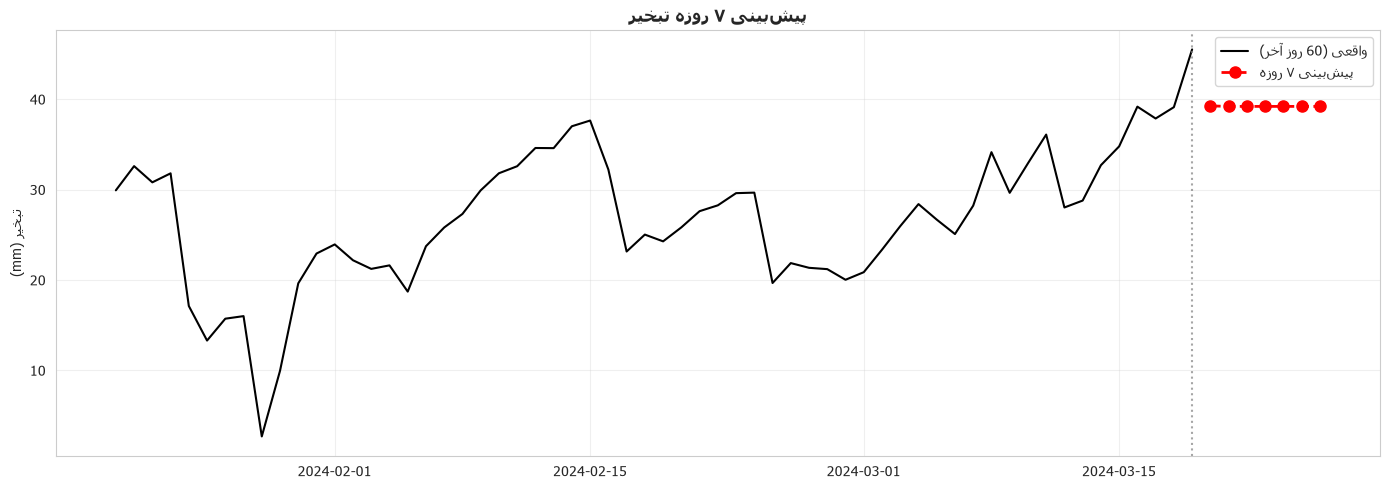


✅ فاز ۴ کامل شد!
ویژگی‌های نهایی: 50
بهترین مدل: Random Forest
Test RMSE: 32.272
Test R²: 0.797


In [73]:
# ============================================================
# فاز ۴ — نسخه اصلاح‌شده بدون leakage
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
TARGET = 'Evapo_mm_Avg'
os.makedirs(f"{output_dir}/models", exist_ok=True)
os.makedirs(f"{output_dir}/reports", exist_ok=True)

# ============================================================
# بارگذاری
# ============================================================
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)
print(f"✅ بارگذاری: {df.shape}")

# ============================================================
# گام ۱: Feature Selection با فیلتر leakage
# ============================================================
print("\n" + "="*80)
print("گام ۱: Feature Selection (بدون leakage)")
print("="*80)

# حذف metadata
drop_cols = ['Date_M', 'Date_S', 'Season_S', 'Cluster']
drop_cols = [c for c in drop_cols if c in df.columns]

# 🔥 فیلتر مهم: حذف هر feature که از Evapo[t] استفاده می‌کنه
def is_leaky(col):
    """تشخیص featureهای leaky (شامل هدف در روز جاری)"""
    if 'Evapo' not in col:
        return False
    # فقط lag با تأخیر ≥ 1 امن هستن
    safe_patterns = ['_lag1', '_lag3', '_lag7', '_lag14', '_lag30']
    if any(p in col for p in safe_patterns):
        return False
    # rolling/ewma/diff/cum/mean/std همه leak دارن (چون شامل t هستن)
    return True

all_numeric = [c for c in df.select_dtypes(include=[np.number]).columns
               if c not in drop_cols + [TARGET]]

leaky_cols = [c for c in all_numeric if is_leaky(c)]
safe_cols = [c for c in all_numeric if not is_leaky(c)]

print(f"🚨 حذف {len(leaky_cols)} feature leaky (شامل Evapo[t]):")
for c in leaky_cols[:15]:
    print(f"   - {c}")
if len(leaky_cols) > 15:
    print(f"   ... و {len(leaky_cols)-15} مورد دیگر")

print(f"\n✅ {len(safe_cols)} feature امن")

# ============================================================
# حذف همبستگی متقابل > 0.95
# ============================================================
numeric_df = df[safe_cols + [TARGET]]
corr_matrix = numeric_df[safe_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    if col in to_drop:
        continue
    high_corr = upper.index[upper[col] > 0.95].tolist()
    for hc in high_corr:
        if hc in to_drop:
            continue
        corr_col = abs(numeric_df[col].corr(numeric_df[TARGET]))
        corr_hc  = abs(numeric_df[hc].corr(numeric_df[TARGET]))
        if corr_col >= corr_hc:
            to_drop.add(hc)
        else:
            to_drop.add(col)
            break

features_after_corr = [f for f in safe_cols if f not in to_drop]
print(f"\n🚨 حذف {len(to_drop)} feature با همبستگی متقابل > 0.95")
print(f"✅ {len(features_after_corr)} feature باقی‌مانده")

# ============================================================
# Feature Importance با XGBoost (بدون leakage)
# ============================================================
print("\n⏳ محاسبه Feature Importance...")
X_temp = df[features_after_corr].fillna(0)
y_temp = df[TARGET]

tscv = TimeSeriesSplit(n_splits=5)
imp_scores = pd.DataFrame(index=features_after_corr)

for fold, (tr, _) in enumerate(tscv.split(X_temp)):
    m = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                     random_state=42, n_jobs=4, verbosity=0)
    m.fit(X_temp.iloc[tr], y_temp.iloc[tr])
    imp_scores[f'fold_{fold}'] = m.feature_importances_

imp_scores['mean'] = imp_scores.mean(axis=1)
imp_scores = imp_scores.sort_values('mean', ascending=False)

print("\nTop 15 feature (بدون leakage):")
print(imp_scores.head(15)[['mean']].round(4).to_string())

# انتخاب 50 برتر
TOP_N = 50
final_features = imp_scores.head(TOP_N).index.tolist()

# حذف featureهایی که همبستگی با هدف > 0.98 دارن (مطمئن‌کاری)
final_features = [f for f in final_features 
                  if abs(df[f].corr(df[TARGET])) < 0.98]

print(f"\n✅ {len(final_features)} feature نهایی")

# ذخیره
with open(f"{output_dir}/reports/selected_features.txt", 'w', encoding='utf-8') as f:
    for feat in final_features:
        f.write(f"{feat}\n")

imp_scores.to_excel(f"{output_dir}/reports/feature_importance.xlsx")

# ============================================================
# گام ۲: مدل‌سازی
# ============================================================
print("\n" + "="*80)
print("گام ۲: مدل‌سازی")
print("="*80)

X = df[final_features]
y = df[TARGET]

n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1, None))) * 100
    return {'Model': name, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3),
            'MAPE (%)': round(mape, 2), 'R²': round(r2, 4)}

# Baseline Naive
y_naive_val = df[TARGET].iloc[train_end-1:val_end-1].values
results_val = [evaluate(y_val.values, y_naive_val, 'Baseline (Naive)')]
print(f"✅ Baseline — Val RMSE: {results_val[-1]['RMSE']}")

# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
results_val.append(evaluate(y_val, lr.predict(X_val), 'Linear Regression'))

# Ridge
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
results_val.append(evaluate(y_val, ridge.predict(X_val), 'Ridge'))

# Lasso
lasso = Lasso(alpha=0.1, max_iter=5000).fit(X_train, y_train)
results_val.append(evaluate(y_val, lasso.predict(X_val), 'Lasso'))

# Random Forest
print("\n⏳ Random Forest...")
t0 = time.time()
rf = RandomForestRegressor(n_estimators=300, max_depth=15,
                           min_samples_split=5, random_state=42, n_jobs=4)
rf.fit(X_train, y_train)
results_val.append(evaluate(y_val, rf.predict(X_val), 'Random Forest'))
print(f"   ({time.time()-t0:.1f}s)")

# XGBoost
print("\n⏳ XGBoost...")
t0 = time.time()
xgb = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, n_jobs=4, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
results_val.append(evaluate(y_val, xgb.predict(X_val), 'XGBoost'))
print(f"   ({time.time()-t0:.1f}s)")

results_df = pd.DataFrame(results_val).sort_values('RMSE')
print("\n" + "="*80)
print("جدول مقایسه مدل‌ها (Validation)")
print("="*80)
print(results_df.to_string(index=False))
results_df.to_excel(f"{output_dir}/reports/model_comparison.xlsx", index=False)

# نمودار
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(results_df)))
axes[0].barh(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='black')
axes[0].set_xlabel('RMSE')
axes[0].set_title('مقایسه RMSE', fontweight='bold')
axes[0].invert_yaxis(); axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(results_df['Model'], results_df['R²'],
             color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df))),
             edgecolor='black')
axes[1].set_xlabel('R²')
axes[1].set_title('مقایسه R²', fontweight='bold')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/model_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

# بهترین مدل
best_name = results_df.iloc[0]['Model']
models_dict = {'Linear Regression': lr, 'Ridge': ridge, 'Lasso': lasso,
               'Random Forest': rf, 'XGBoost': xgb}
best_model = models_dict[best_name]
joblib.dump(best_model, f"{output_dir}/models/best_model.pkl")
print(f"\n🏆 بهترین مدل: {best_name}")

# ============================================================
# گام ۳: ارزیابی نهایی روی Test
# ============================================================
print("\n" + "="*80)
print("گام ۳: ارزیابی روی Test Set")
print("="*80)

y_pred_test_rf = rf.predict(X_test)
y_pred_test_xgb = xgb.predict(X_test)

test_results = pd.DataFrame([
    evaluate(y_test, y_pred_test_rf, 'Random Forest'),
    evaluate(y_test, y_pred_test_xgb, 'XGBoost'),
]).sort_values('RMSE')

print(test_results.to_string(index=False))
test_results.to_excel(f"{output_dir}/reports/final_results.xlsx", index=False)

# نمودار
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
test_dates = df['Date_M'].iloc[val_end:].values

axes[0].plot(test_dates, y_test.values, label='واقعی', color='black', linewidth=1.5)
axes[0].plot(test_dates, y_pred_test_xgb, label='پیش‌بینی XGBoost',
             color='red', linewidth=1.2, alpha=0.8)
axes[0].set_title('پیش‌بینی vs واقعی (Test)', fontweight='bold')
axes[0].set_ylabel('تبخیر (mm)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred_test_xgb, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred_test_xgb.min()),
        max(y_test.max(), y_pred_test_xgb.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='خط ۱:۱')
axes[1].set_xlabel('واقعی'); axes[1].set_ylabel('پیش‌بینی')
axes[1].set_title(f'Scatter — R² = {r2_score(y_test, y_pred_test_xgb):.3f}',
                  fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/prediction_vs_actual.png", dpi=120, bbox_inches='tight')
plt.show()

# تحلیل باقیمانده
residuals = y_test.values - y_pred_test_xgb
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--')
axes[0, 0].set_title(f'توزیع باقیمانده (میانگین={residuals.mean():.2f})', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(y_pred_test_xgb, residuals, alpha=0.4, s=10, color='steelblue')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Predicted', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

from scipy import stats as sps
sps.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-Plot', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(test_dates, residuals, color='steelblue', linewidth=0.8)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('باقیمانده در طول زمان', fontweight='bold')
axes[1, 1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/residual_analysis.png", dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# گام ۴: پیش‌بینی ۷ روزه
# ============================================================
print("\n" + "="*80)
print("گام ۴: پیش‌بینی ۷ روزه")
print("="*80)

def recursive_forecast(model, df_hist, feature_cols, target, horizon=7):
    df_work = df_hist.copy()
    preds = []
    for h in range(horizon):
        last = df_work.iloc[-1:].copy()
        X_next = last[feature_cols]
        y_next = model.predict(X_next)[0]
        preds.append(y_next)
        new_row = last.copy()
        new_row[target] = y_next
        new_row['Date_M'] = last['Date_M'].values[0] + pd.Timedelta(days=1)
        # به‌روزرسانی lag1 (اگه وجود داره)
        for col in feature_cols:
            if 'Evapo' in col and '_lag1' in col:
                new_row[col] = y_next
        df_work = pd.concat([df_work, new_row], ignore_index=True)
    return preds

forecast = recursive_forecast(xgb, df, final_features, TARGET, horizon=7)
last_date = df['Date_M'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

forecast_df = pd.DataFrame({'Date': future_dates, 'Evapo_Forecast': forecast})
print(forecast_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
last_60 = df.tail(60)
ax.plot(last_60['Date_M'], last_60[TARGET], label='واقعی (60 روز آخر)',
        color='black', linewidth=1.5)
ax.plot(forecast_df['Date'], forecast_df['Evapo_Forecast'], 'o--',
        label='پیش‌بینی ۷ روزه', color='red', linewidth=2, markersize=8)
ax.axvline(last_date, color='gray', linestyle=':', alpha=0.7)
ax.set_title('پیش‌بینی ۷ روزه تبخیر', fontweight='bold')
ax.set_ylabel('تبخیر (mm)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/forecast_7days.png", dpi=120, bbox_inches='tight')
plt.show()

forecast_df.to_excel(f"{output_dir}/reports/forecast_7days.xlsx", index=False)

# ============================================================
# خلاصه
# ============================================================
print("\n" + "="*80)
print("✅ فاز ۴ کامل شد!")
print("="*80)
print(f"ویژگی‌های نهایی: {len(final_features)}")
print(f"بهترین مدل: {best_name}")
print(f"Test RMSE: {test_results.iloc[0]['RMSE']}")
print(f"Test R²: {test_results.iloc[0]['R²']}")

✅ هدف بازطراحی شد: پیش‌بینی Evapo[t+1] از داده‌های t
✅ ابعاد: (1736, 213)
🚨 حذف 14 feature leaky
✅ 193 feature امن
🚨 حذف 70 feature با همبستگی بالا
✅ 123 feature باقی‌مانده

⏳ Feature Importance...

Top 15:
                            mean
Evapo_mm_Avg_lag1          0.246
Month_S                    0.091
Water Level(m)             0.046
PET_Hargreaves_roll30_mean 0.028
Evapo_mm_Avg_lag3          0.027
Watts_m2_Avg_roll14_mean   0.025
VPD_roll14_std             0.024
Rain_mm_Tot_roll30_std     0.023
Rain_mm_Tot_roll14_mean    0.014
Evapo_mm_Avg_lag30         0.013
Watts_m2_Avg_lag3          0.010
Humidity_Avg_ewma30        0.010
Humidity_per_Temp          0.010
Rain_mm_Tot_roll30_mean    0.010
DOY_sin                    0.009

✅ 50 feature نهایی

Train: 1,041 | Val: 347 | Test: 348
✅ Baseline — Val RMSE: 33.125

⏳ Random Forest...
   (9.9s)

⏳ XGBoost...
   (4.5s)

جدول مقایسه (Validation)
            Model   RMSE    MAE  MAPE (%)    R²
    Random Forest 29.817 19.076    37.940 0.843
  

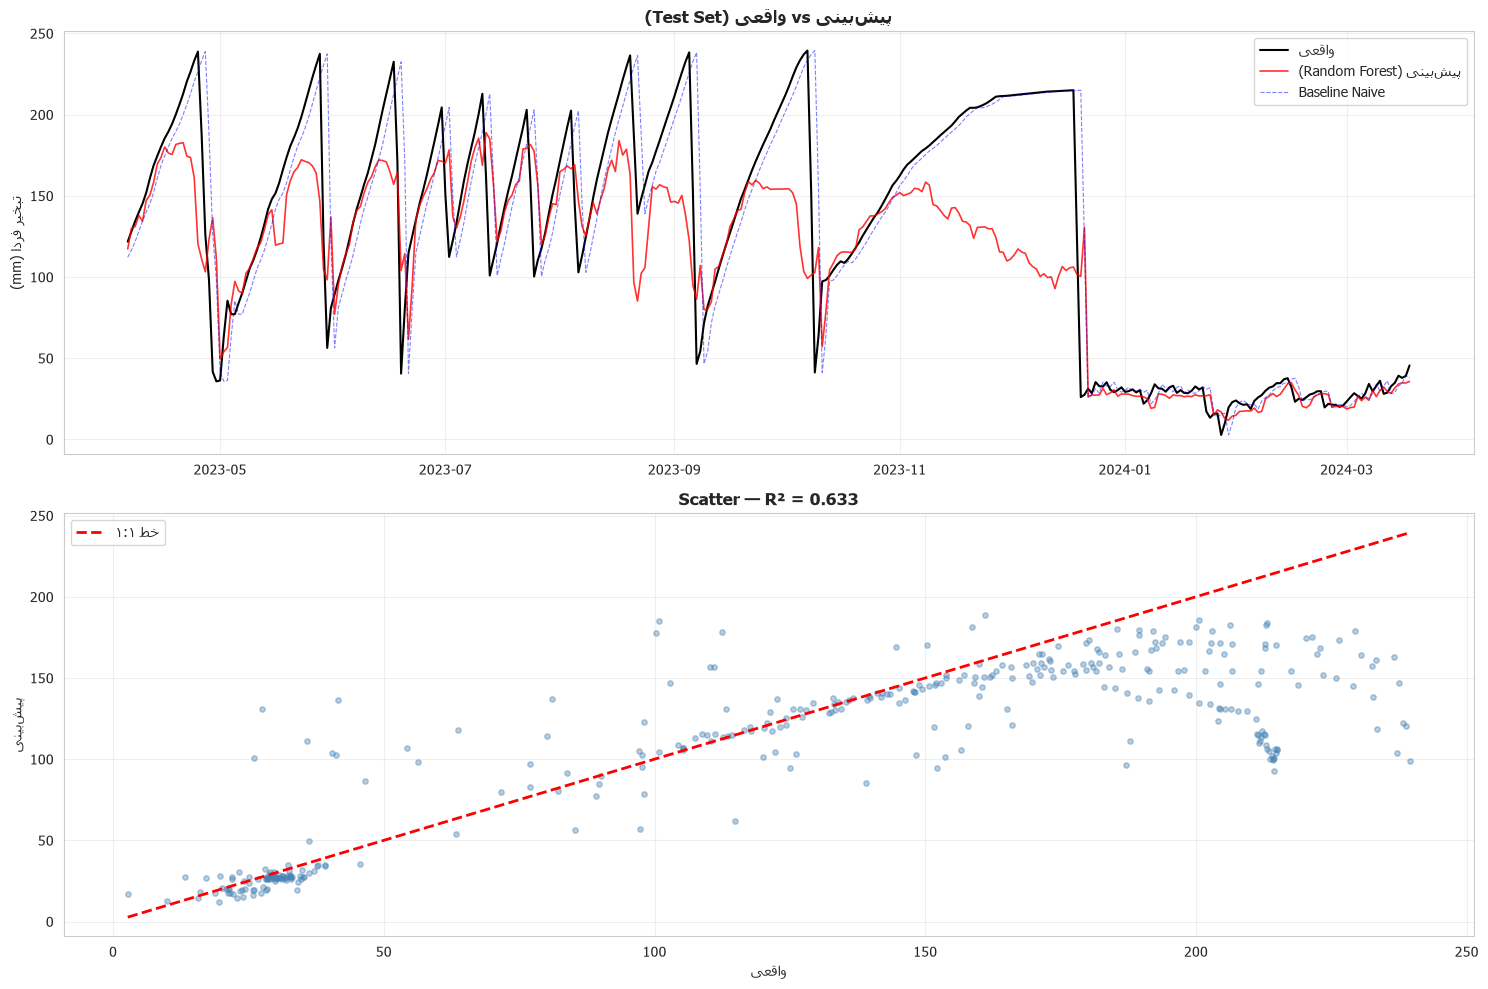


✅ فاز ۴ کامل شد!
بهترین مدل: Random Forest
Test RMSE: 34.606
Test R²: 0.7666


In [74]:
# ============================================================
# فاز ۴ — نسخه نهایی و اصلاح‌شده
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import joblib, time, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
os.makedirs(f"{output_dir}/models", exist_ok=True)
os.makedirs(f"{output_dir}/reports", exist_ok=True)

# ============================================================
# بارگذاری
# ============================================================
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

# ============================================================
# 🔥 بازطراحی هدف: پیش‌بینی Evapo[t+1] از داده t
# ============================================================
TARGET_ORIG = 'Evapo_mm_Avg'
df['Evapo_target'] = df[TARGET_ORIG].shift(-1)

# حذف آخرین ردیف (هدف نداره)
df = df.dropna(subset=['Evapo_target']).reset_index(drop=True)

TARGET = 'Evapo_target'
print(f"✅ هدف بازطراحی شد: پیش‌بینی Evapo[t+1] از داده‌های t")
print(f"✅ ابعاد: {df.shape}")

# ============================================================
# تشخیص و حذف leakage
# ============================================================
def is_leaky(col, target_orig=TARGET_ORIG):
    """featureهایی که از Evapo[t] استفاده می‌کنن"""
    if 'Evapo' not in col:
        return False
    # فقط lag امن هستن (چون از گذشته می‌آن)
    if any(p in col for p in ['_lag1', '_lag3', '_lag7', '_lag14', '_lag30']):
        return False
    # rolling/ewma/diff/High_Evapo همه leak دارن
    return True

drop_cols = ['Date_M', 'Date_S', 'Season_S', 'Cluster', 'Evapo_target']
drop_cols = [c for c in drop_cols if c in df.columns]

all_features = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in drop_cols]

leaky = [c for c in all_features if is_leaky(c)]
safe = [c for c in all_features if not is_leaky(c)]
print(f"🚨 حذف {len(leaky)} feature leaky")
print(f"✅ {len(safe)} feature امن")

# حذف همبستگی متقابل
numeric_df = df[safe + [TARGET]]
corr_mat = numeric_df[safe].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    if col in to_drop: continue
    high = upper.index[upper[col] > 0.95].tolist()
    for hc in high:
        if hc in to_drop: continue
        c1 = abs(numeric_df[col].corr(numeric_df[TARGET]))
        c2 = abs(numeric_df[hc].corr(numeric_df[TARGET]))
        if c1 >= c2: to_drop.add(hc)
        else: to_drop.add(col); break

features_after = [f for f in safe if f not in to_drop]
print(f"🚨 حذف {len(to_drop)} feature با همبستگی بالا")
print(f"✅ {len(features_after)} feature باقی‌مانده")

# ============================================================
# Feature Importance
# ============================================================
print("\n⏳ Feature Importance...")
X_temp = df[features_after].fillna(0)
y_temp = df[TARGET]

tscv = TimeSeriesSplit(n_splits=5)
imp = pd.DataFrame(index=features_after)
for fold, (tr, _) in enumerate(tscv.split(X_temp)):
    m = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                     random_state=42, n_jobs=4, verbosity=0)
    m.fit(X_temp.iloc[tr], y_temp.iloc[tr])
    imp[f'fold_{fold}'] = m.feature_importances_
imp['mean'] = imp.mean(axis=1)
imp = imp.sort_values('mean', ascending=False)

print("\nTop 15:")
print(imp.head(15)[['mean']].round(4).to_string())

final_features = imp.head(50).index.tolist()
final_features = [f for f in final_features if abs(df[f].corr(df[TARGET])) < 0.98]
print(f"\n✅ {len(final_features)} feature نهایی")

with open(f"{output_dir}/reports/selected_features.txt", 'w', encoding='utf-8') as f:
    for feat in final_features: f.write(f"{feat}\n")

# ============================================================
# مدل‌سازی
# ============================================================
X = df[final_features]
y = df[TARGET]

n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f"\nTrain: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

def evaluate(yt, yp, name):
    return {'Model': name,
            'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 3),
            'MAE': round(mean_absolute_error(yt, yp), 3),
            'MAPE (%)': round(np.mean(np.abs((yt - yp) / np.clip(np.abs(yt), 1, None))) * 100, 2),
            'R²': round(r2_score(yt, yp), 4)}

# Baseline Naive (Evapo[t+1] = Evapo[t])
y_naive_val = df[TARGET_ORIG].iloc[train_end:val_end].values  # Evapo در t+1
# ولی Naive پیش‌بینی می‌کنه: Evapo[t+1] = Evapo[t]
# که Evapo[t] = df[TARGET_ORIG].iloc[train_end-1:val_end-1].values
y_naive_val_correct = df[TARGET_ORIG].iloc[train_end-1:val_end-1].values

results = [evaluate(y_val.values, y_naive_val_correct, 'Baseline (Naive)')]
print(f"✅ Baseline — Val RMSE: {results[-1]['RMSE']}")

lr = LinearRegression().fit(X_train, y_train)
results.append(evaluate(y_val, lr.predict(X_val), 'Linear Regression'))

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
results.append(evaluate(y_val, ridge.predict(X_val), 'Ridge'))

lasso = Lasso(alpha=0.1, max_iter=5000).fit(X_train, y_train)
results.append(evaluate(y_val, lasso.predict(X_val), 'Lasso'))

print("\n⏳ Random Forest...")
t0 = time.time()
rf = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=5,
                           random_state=42, n_jobs=4)
rf.fit(X_train, y_train)
results.append(evaluate(y_val, rf.predict(X_val), 'Random Forest'))
print(f"   ({time.time()-t0:.1f}s)")

print("\n⏳ XGBoost...")
t0 = time.time()
xgb = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, n_jobs=4, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
results.append(evaluate(y_val, xgb.predict(X_val), 'XGBoost'))
print(f"   ({time.time()-t0:.1f}s)")

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n" + "="*80)
print("جدول مقایسه (Validation)")
print("="*80)
print(results_df.to_string(index=False))
results_df.to_excel(f"{output_dir}/reports/model_comparison.xlsx", index=False)

# بهترین مدل
best_name = results_df.iloc[0]['Model']
models = {'Linear Regression': lr, 'Ridge': ridge, 'Lasso': lasso,
          'Random Forest': rf, 'XGBoost': xgb}
best_model = models[best_name]
joblib.dump(best_model, f"{output_dir}/models/best_model.pkl")
print(f"\n🏆 بهترین مدل: {best_name}")

# ============================================================
# ارزیابی Test
# ============================================================
print("\n" + "="*80)
print("ارزیابی روی Test")
print("="*80)

y_naive_test = df[TARGET_ORIG].iloc[val_end-1:-1].values
test_results = pd.DataFrame([
    evaluate(y_test.values, y_naive_test, 'Baseline (Naive)'),
    evaluate(y_test, rf.predict(X_test), 'Random Forest'),
    evaluate(y_test, xgb.predict(X_test), 'XGBoost'),
]).sort_values('RMSE')

print(test_results.to_string(index=False))
test_results.to_excel(f"{output_dir}/reports/final_results.xlsx", index=False)

# نمودار
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
test_dates = df['Date_M'].iloc[val_end:].values
best_pred = models[best_name].predict(X_test)

axes[0].plot(test_dates, y_test.values, label='واقعی', color='black', linewidth=1.5)
axes[0].plot(test_dates, best_pred, label=f'پیش‌بینی ({best_name})',
             color='red', linewidth=1.2, alpha=0.8)
axes[0].plot(test_dates, y_naive_test, label='Baseline Naive',
             color='blue', linewidth=0.8, alpha=0.5, linestyle='--')
axes[0].set_title('پیش‌بینی vs واقعی (Test Set)', fontweight='bold')
axes[0].set_ylabel('تبخیر فردا (mm)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, best_pred, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='خط ۱:۱')
axes[1].set_xlabel('واقعی'); axes[1].set_ylabel('پیش‌بینی')
axes[1].set_title(f'Scatter — R² = {r2_score(y_test, best_pred):.3f}', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/prediction_vs_actual.png", dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# خلاصه
# ============================================================
print("\n" + "="*80)
print("✅ فاز ۴ کامل شد!")
print("="*80)
print(f"بهترین مدل: {best_name}")
print(f"Test RMSE: {test_results.iloc[0]['RMSE']}")
print(f"Test R²: {test_results.iloc[0]['R²']}")

In [75]:
# ============================================================
# Hybrid Model: Naive + ML Residual Correction
# ============================================================

# مرحله ۱: Baseline Naive
# پیش‌بینی اولیه: Evapo[t+1] = Evapo[t]
df['Naive_Pred'] = df[TARGET_ORIG].shift(1)  # تبخیر دیروز
df = df.dropna(subset=['Naive_Pred']).reset_index(drop=True)

# مرحله ۲: Residual = واقعی - Naive
df['Residual'] = df[TARGET] - df['Naive_Pred']

# مرحله ۳: آموزش ML روی Residual
# هدف جدید: پیش‌بینی خطای Naive
TARGET_RESID = 'Residual'

# featureها: بدون lag1 تبخیر (چون Naive ازش استفاده کرد)
features_for_resid = [f for f in final_features 
                      if f != 'Evapo_mm_Avg_lag1']
features_for_resid = [f for f in features_for_resid if f in df.columns]

X = df[features_for_resid]
y_resid = df[TARGET_RESID]

# تقسیم زمانی
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X.iloc[:train_end]
y_train = y_resid.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val_resid = y_resid.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test_resid = y_resid.iloc[val_end:]

# آموزش XGBoost روی Residual
print("⏳ آموزش XGBoost روی Residual...")
xgb_resid = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03,
                         subsample=0.8, colsample_bytree=0.7,
                         reg_alpha=0.1, reg_lambda=1.0,
                         random_state=42, n_jobs=4, verbosity=0)
xgb_resid.fit(X_train, y_train, eval_set=[(X_val, y_val_resid)], verbose=False)

# پیش‌بینی Residual
resid_pred_val = xgb_resid.predict(X_val)
resid_pred_test = xgb_resid.predict(X_test)

# پیش‌بینی نهایی: Naive + Residual_Pred
y_final_val = df['Naive_Pred'].iloc[train_end:val_end].values + resid_pred_val
y_final_test = df['Naive_Pred'].iloc[val_end:].values + resid_pred_test

# ارزیابی
y_test_actual = df[TARGET].iloc[val_end:].values
y_val_actual = df[TARGET].iloc[train_end:val_end].values

def evaluate(yt, yp, name):
    return {'Model': name,
            'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 3),
            'MAE': round(mean_absolute_error(yt, yp), 3),
            'R²': round(r2_score(yt, yp), 4)}

results = pd.DataFrame([
    evaluate(y_val_actual, df['Naive_Pred'].iloc[train_end:val_end].values, 'Naive (Baseline)'),
    evaluate(y_val_actual, y_final_val, 'Hybrid (Naive + XGB)'),
    evaluate(y_test_actual, df['Naive_Pred'].iloc[val_end:].values, 'Naive (Baseline)'),
    evaluate(y_test_actual, y_final_test, 'Hybrid (Naive + XGB)'),
])
results['Set'] = ['Val', 'Val', 'Test', 'Test']
results = results[['Set', 'Model', 'RMSE', 'MAE', 'R²']]

print("\n" + "="*80)
print("مقایسه Naive و Hybrid")
print("="*80)
print(results.to_string(index=False))

⏳ آموزش XGBoost روی Residual...

مقایسه Naive و Hybrid
 Set                Model   RMSE    MAE    R²
 Val     Naive (Baseline) 33.124 17.953 0.807
 Val Hybrid (Naive + XGB) 30.628 17.356 0.835
Test     Naive (Baseline) 34.652 18.364 0.767
Test Hybrid (Naive + XGB) 36.334 21.940 0.743


✅ ابعاد: (1736, 215)

آمار Residual:
count   1,736.000
mean       -0.050
std        20.445
min      -173.036
25%         0.234
50%         3.666
75%         7.770
max        66.585

🚨 14 feature leaky حذف شد
✅ 193 feature امن
✅ 129 feature بعد از حذف همبستگی

⏳ Feature Importance...

✅ 49 feature نهایی برای Residual

Top 15:
   1. Evapo_mm_Avg_lag1: 0.0415
   2. Humidity_Avg_roll7_mean: 0.0315
   3. Humidity_Avg_zscore_monthly: 0.0296
   4. DOW_sin: 0.0288
   5. Watts_m2_Avg_lag14: 0.0193
   6. PET_x_Wind: 0.0182
   7. Temp_x_Humidity: 0.0178
   8. Watts_m2_Avg_roll3_mean: 0.0176
   9. Wind_dir_Avg: 0.0175
  10. VPD_roll14_std: 0.0167
  11. Humidity_Range: 0.0167
  12. Baro_KPa_Avg_roll30_std: 0.0162
  13. Wind_Kmh_Max: 0.0161
  14. Watts_m2_Avg_roll7_std: 0.0158
  15. VPD_roll3_std: 0.0155

Train: 1041 | Val: 347 | Test: 348

⏳ آموزش XGBoost روی Residual...

نتایج Hybrid Model

--- Validation ---
               Model   RMSE    MAE    R²
    Naive (Baseline) 20.381  9.886 0.927
Hybrid 

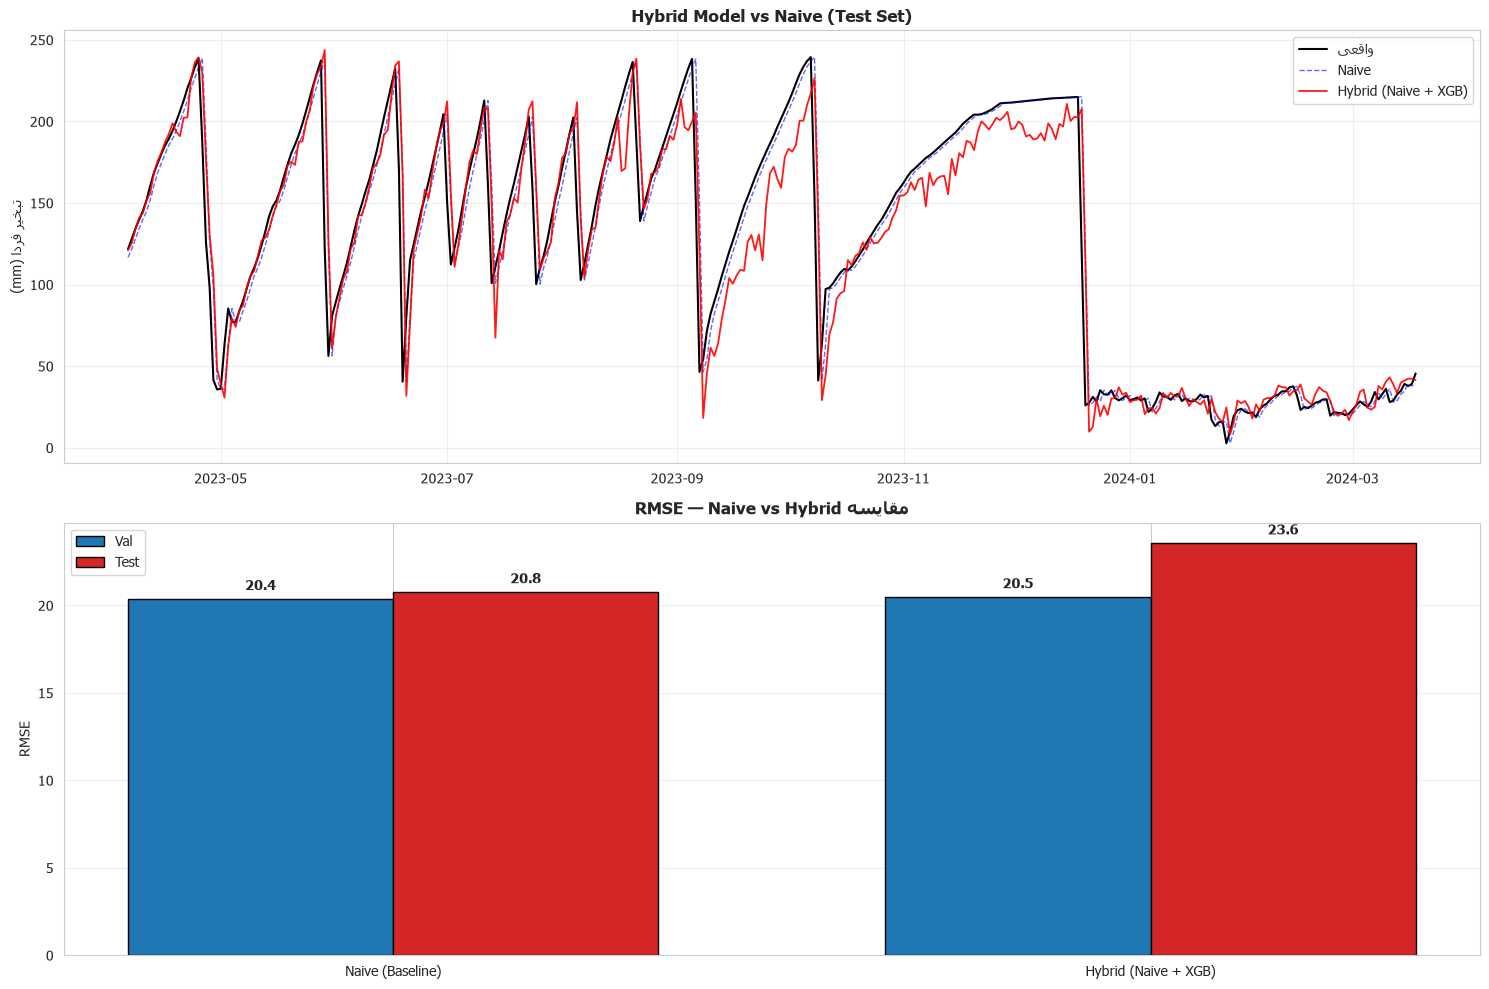


✅ مدل Hybrid ذخیره شد


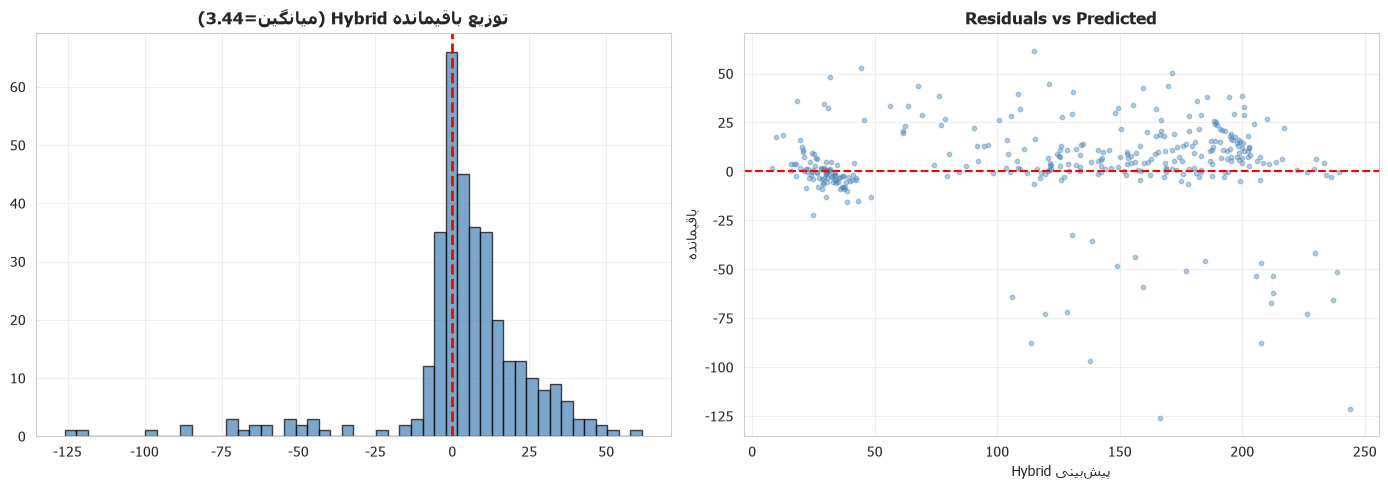


✅ Hybrid کامل شد!


In [76]:
# ============================================================
# بخش ۱: Hybrid Model — Naive + XGBoost Residual Correction
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
TARGET_ORIG = 'Evapo_mm_Avg'

# ============================================================
# ۱. بارگذاری و آماده‌سازی
# ============================================================
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

# هدف: Evapo[t+1]
df['Evapo_target'] = df[TARGET_ORIG].shift(-1)
df = df.dropna(subset=['Evapo_target']).reset_index(drop=True)

# Naive: Evapo[t+1] = Evapo[t]
df['Naive_Pred'] = df[TARGET_ORIG]

# Residual = واقعی - Naive
df['Residual'] = df['Evapo_target'] - df['Naive_Pred']

print(f"✅ ابعاد: {df.shape}")
print(f"\nآمار Residual:")
print(df['Residual'].describe().round(3).to_string())

# ============================================================
# ۲. انتخاب feature (بدون leakage)
# ============================================================
def is_leaky(col):
    if 'Evapo' not in col:
        return False
    if any(p in col for p in ['_lag1', '_lag3', '_lag7', '_lag14', '_lag30']):
        return False
    return True

drop_cols = ['Date_M', 'Date_S', 'Season_S', 'Cluster',
             'Evapo_target', 'Naive_Pred', 'Residual']
drop_cols = [c for c in drop_cols if c in df.columns]

all_features = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in drop_cols]

leaky = [c for c in all_features if is_leaky(c)]
safe = [c for c in all_features if not is_leaky(c)]
print(f"\n🚨 {len(leaky)} feature leaky حذف شد")
print(f"✅ {len(safe)} feature امن")

# حذف همبستگی متقابل
numeric_df = df[safe + ['Residual']]
corr_mat = numeric_df[safe].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    if col in to_drop: continue
    high = upper.index[upper[col] > 0.95].tolist()
    for hc in high:
        if hc in to_drop: continue
        c1 = abs(numeric_df[col].corr(numeric_df['Residual']))
        c2 = abs(numeric_df[hc].corr(numeric_df['Residual']))
        if c1 >= c2: to_drop.add(hc)
        else: to_drop.add(col); break

features_safe = [f for f in safe if f not in to_drop]
print(f"✅ {len(features_safe)} feature بعد از حذف همبستگی")

# انتخاب 50 برتر با XGB
print("\n⏳ Feature Importance...")
X_temp = df[features_safe].fillna(0)
y_temp = df['Residual']

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
imp = pd.DataFrame(index=features_safe)
for fold, (tr, _) in enumerate(tscv.split(X_temp)):
    m = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                     random_state=42, n_jobs=4, verbosity=0)
    m.fit(X_temp.iloc[tr], y_temp.iloc[tr])
    imp[f'fold_{fold}'] = m.feature_importances_
imp['mean'] = imp.mean(axis=1)
imp = imp.sort_values('mean', ascending=False)

# حذف lag1 تبخیر از featureهای residual (چون Naive ازش استفاده کرد)
final_features = [f for f in imp.head(50).index 
                  if f != 'Evapo_mm_Avg_lag1']

print(f"\n✅ {len(final_features)} feature نهایی برای Residual")
print("\nTop 15:")
for i, (feat, row) in enumerate(imp.head(15).iterrows(), 1):
    print(f"  {i:2d}. {feat}: {row['mean']:.4f}")

# ============================================================
# ۳. تقسیم داده
# ============================================================
X = df[final_features]
y_resid = df['Residual']

n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X.iloc[:train_end]
y_train = y_resid.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val = y_resid.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test = y_resid.iloc[val_end:]

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ============================================================
# ۴. آموزش XGBoost روی Residual
# ============================================================
print("\n⏳ آموزش XGBoost روی Residual...")
xgb_resid = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=4, verbosity=0
)
xgb_resid.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# پیش‌بینی Residual
resid_pred_val = xgb_resid.predict(X_val)
resid_pred_test = xgb_resid.predict(X_test)

# پیش‌بینی نهایی: Naive + Residual_Pred
y_final_val = df['Naive_Pred'].iloc[train_end:val_end].values + resid_pred_val
y_final_test = df['Naive_Pred'].iloc[val_end:].values + resid_pred_test

# ============================================================
# ۵. ارزیابی
# ============================================================
def evaluate(yt, yp, name):
    return {
        'Model': name,
        'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 3),
        'MAE': round(mean_absolute_error(yt, yp), 3),
        'R²': round(r2_score(yt, yp), 4)
    }

# داده‌های واقعی
y_val_actual = df['Evapo_target'].iloc[train_end:val_end].values
y_test_actual = df['Evapo_target'].iloc[val_end:].values

# Naive
y_naive_val = df['Naive_Pred'].iloc[train_end:val_end].values
y_naive_test = df['Naive_Pred'].iloc[val_end:].values

# نتایج
val_results = pd.DataFrame([
    evaluate(y_val_actual, y_naive_val, 'Naive (Baseline)'),
    evaluate(y_val_actual, y_final_val, 'Hybrid (Naive + XGB)'),
])

test_results = pd.DataFrame([
    evaluate(y_test_actual, y_naive_test, 'Naive (Baseline)'),
    evaluate(y_test_actual, y_final_test, 'Hybrid (Naive + XGB)'),
])

print("\n" + "="*80)
print("نتایج Hybrid Model")
print("="*80)
print("\n--- Validation ---")
print(val_results.to_string(index=False))
print("\n--- Test ---")
print(test_results.to_string(index=False))

val_results.to_excel(f"{output_dir}/reports/hybrid_val_results.xlsx", index=False)
test_results.to_excel(f"{output_dir}/reports/hybrid_test_results.xlsx", index=False)

# ============================================================
# ۶. نمودار
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

test_dates = df['Date_M'].iloc[val_end:].values

axes[0].plot(test_dates, y_test_actual, label='واقعی', color='black', linewidth=1.5)
axes[0].plot(test_dates, y_naive_test, label='Naive', color='blue',
             linewidth=1, alpha=0.6, linestyle='--')
axes[0].plot(test_dates, y_final_test, label='Hybrid (Naive + XGB)',
             color='red', linewidth=1.3, alpha=0.9)
axes[0].set_title('Hybrid Model vs Naive (Test Set)', fontweight='bold')
axes[0].set_ylabel('تبخیر فردا (mm)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# مقایسه RMSE
models_compare = ['Naive (Baseline)', 'Hybrid (Naive + XGB)']
val_rmse = val_results['RMSE'].values
test_rmse = test_results['RMSE'].values

x = np.arange(len(models_compare))
width = 0.35
axes[1].bar(x - width/2, val_rmse, width, label='Val', color='#1f77b4', edgecolor='black')
axes[1].bar(x + width/2, test_rmse, width, label='Test', color='#d62728', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_compare)
axes[1].set_ylabel('RMSE')
axes[1].set_title('مقایسه RMSE — Naive vs Hybrid', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# افزودن مقادیر
for i, (v, t) in enumerate(zip(val_rmse, test_rmse)):
    axes[1].text(i - width/2, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')
    axes[1].text(i + width/2, t + 0.5, f'{t:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/hybrid_results.png", dpi=120, bbox_inches='tight')
plt.show()

# ذخیره مدل
joblib.dump(xgb_resid, f"{output_dir}/models/hybrid_xgb_residual.pkl")
print(f"\n✅ مدل Hybrid ذخیره شد")

# ============================================================
# ۷. تحلیل باقیمانده Hybrid
# ============================================================
hybrid_residuals = y_test_actual - y_final_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hybrid_residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'توزیع باقیمانده Hybrid (میانگین={hybrid_residuals.mean():.2f})',
                  fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_final_test, hybrid_residuals, alpha=0.4, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('پیش‌بینی Hybrid')
axes[1].set_ylabel('باقیمانده')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/hybrid_residuals.png", dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Hybrid کامل شد!")

✅ ابعاد: (1736, 213)
✅ 20 feature برای LSTM
✅ X_seq: (1722, 14, 20) | y_seq: (1722,)

Train: (1033, 14, 20)
Val:   (344, 14, 20)
Test:  (345, 14, 20)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 14, 64)              │          21,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 14, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,977 (136.63 KB)

 Trainable params: 34,849 (136.13 KB)

 Non-trainable params: 128 (512.00 B)


⏳ آموزش LSTM...
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.3707 - mae: 0.4742 - val_loss: 0.4284 - val_mae: 0.5278 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.2306 - mae: 0.3678 - val_loss: 0.3983 - val_mae: 0.5033 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2206 - mae: 0.3466 - val_loss: 0.4094 - val_mae: 0.4999 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1956 - mae: 0.3257 - val_loss: 0.4008 - val_mae: 0.5047 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1920 - mae: 0.3279 - val_loss: 0.3596 - val_mae: 0.4636 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1789 - mae: 0.3065 - val_loss: 0.3587 - val_mae: 0.4598 - learning_rate: 0.0010
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1662 - mae: 0.2985 - val_loss: 0.4116 - val_mae: 0.4939 - learning_ra

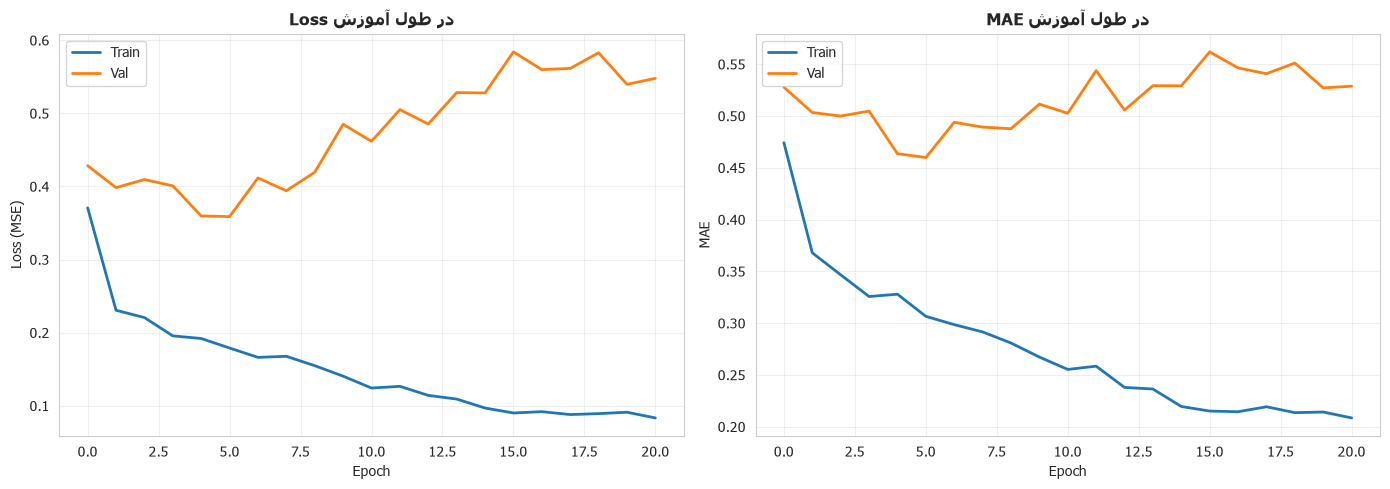


نتایج LSTM
--- Validation ---
Model   RMSE    MAE    R²
 LSTM 40.752 31.288 0.710

--- Test ---
Model   RMSE    MAE    R²
 LSTM 54.167 39.895 0.433


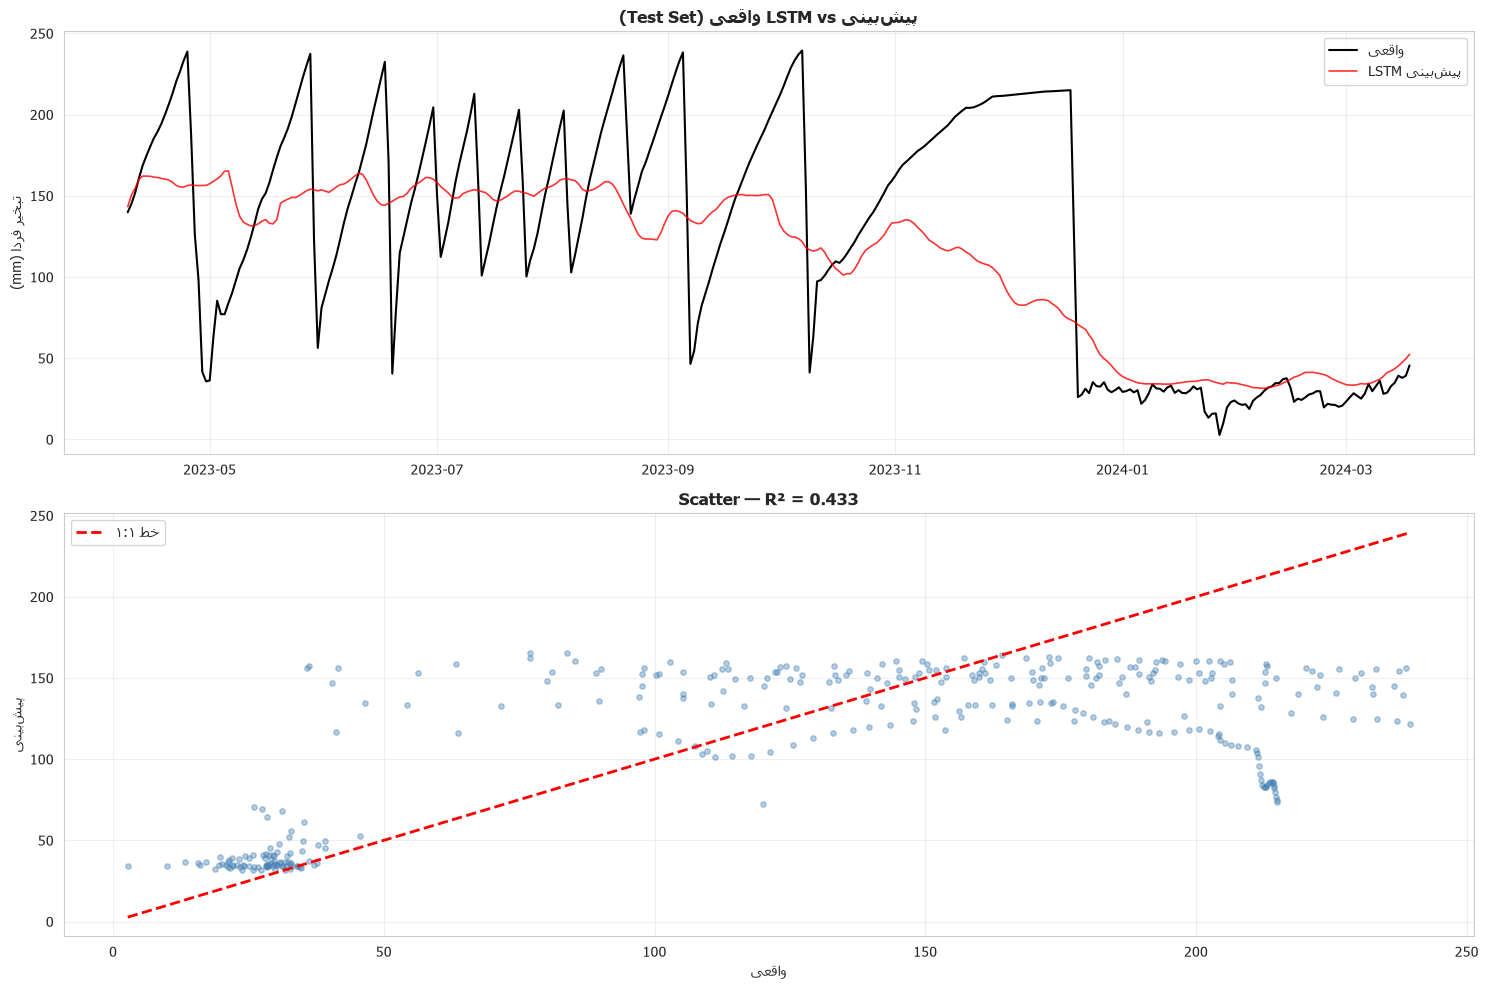


✅ LSTM ذخیره شد
✅ فاز LSTM کامل شد!


In [78]:
# ============================================================
# بخش ۲: LSTM برای پیش‌بینی تبخیر
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # کم کردن پیام‌های TensorFlow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

# تنظیم seed برای تکرارپذیری
np.random.seed(42)
tf.random.set_seed(42)

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
TARGET_ORIG = 'Evapo_mm_Avg'

# ============================================================
# ۱. بارگذاری
# ============================================================
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

# هدف: Evapo[t+1]
df['Evapo_target'] = df[TARGET_ORIG].shift(-1)
df = df.dropna(subset=['Evapo_target']).reset_index(drop=True)

print(f"✅ ابعاد: {df.shape}")

# ============================================================
# ۲. انتخاب feature (حداقل، بدون leakage)
# ============================================================
# LSTM با ۲۰–۳۰ feature کار می‌کنه، نه ۵۰
# انتخاب: پارامترهای اصلی هواشناسی + lag تبخیر
lstm_features = [
    'Evapo_mm_Avg_lag1', 'Evapo_mm_Avg_lag3', 'Evapo_mm_Avg_lag7',
    'Temperature_Avg', 'Temperature_Max', 'Temperature_Min',
    'Humidity_Avg', 'Wind_Kmh_Avg', 'Watts_m2_Avg',
    'Baro_KPa_Avg', 'VPD', 'PET_Hargreaves',
    'Rain_mm_Tot', 'Month_sin', 'Month_cos', 'DOY_sin', 'DOY_cos',
    'Temperature_Avg_roll7_mean', 'Humidity_Avg_roll7_mean',
    'Watts_m2_Avg_roll7_mean',
]

# فقط featureهایی که در df موجودن
lstm_features = [f for f in lstm_features if f in df.columns]
print(f"✅ {len(lstm_features)} feature برای LSTM")

# ============================================================
# ۳. آماده‌سازی sequence
# ============================================================
SEQUENCE_LENGTH = 14  # ۲ هفته گذشته

# مقیاس‌بندی
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_data = scaler_X.fit_transform(df[lstm_features].values)
y_data = scaler_y.fit_transform(df['Evapo_target'].values.reshape(-1, 1)).flatten()

# ساخت sequence
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_data, y_data, SEQUENCE_LENGTH)
print(f"✅ X_seq: {X_seq.shape} | y_seq: {y_seq.shape}")

# تقسیم زمانی (60/20/20)
n = len(X_seq)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]
X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]
X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

print(f"\nTrain: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

# ============================================================
# ۴. ساخت مدل LSTM
# ============================================================
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        BatchNormalization(),
        
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_lstm_model((SEQUENCE_LENGTH, len(lstm_features)))
model.summary()

# ============================================================
# ۵. آموزش
# ============================================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print("\n⏳ آموزش LSTM...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# ۶. نمودار آموزش
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Loss در طول آموزش', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE در طول آموزش', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/lstm_training.png", dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# ۷. پیش‌بینی و معکوس مقیاس
# ============================================================
y_pred_val = model.predict(X_val, verbose=0).flatten()
y_pred_test = model.predict(X_test, verbose=0).flatten()

# معکوس مقیاس
y_val_actual = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_val_inv = scaler_y.inverse_transform(y_pred_val.reshape(-1, 1)).flatten()
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()

# ============================================================
# ۸. ارزیابی
# ============================================================
def evaluate(yt, yp, name):
    return {
        'Model': name,
        'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 3),
        'MAE': round(mean_absolute_error(yt, yp), 3),
        'R²': round(r2_score(yt, yp), 4)
    }

val_results = evaluate(y_val_actual, y_pred_val_inv, 'LSTM')
test_results = evaluate(y_test_actual, y_pred_test_inv, 'LSTM')

print("\n" + "="*80)
print("نتایج LSTM")
print("="*80)
print("--- Validation ---")
print(pd.DataFrame([val_results]).to_string(index=False))
print("\n--- Test ---")
print(pd.DataFrame([test_results]).to_string(index=False))

# ============================================================
# ۹. نمودار
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

test_dates = df['Date_M'].iloc[val_end + SEQUENCE_LENGTH:].values

axes[0].plot(test_dates, y_test_actual, label='واقعی', color='black', linewidth=1.5)
axes[0].plot(test_dates, y_pred_test_inv, label='پیش‌بینی LSTM',
             color='red', linewidth=1.2, alpha=0.8)
axes[0].set_title('پیش‌بینی LSTM vs واقعی (Test Set)', fontweight='bold')
axes[0].set_ylabel('تبخیر فردا (mm)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_actual, y_pred_test_inv, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test_actual.min(), y_pred_test_inv.min()),
        max(y_test_actual.max(), y_pred_test_inv.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='خط ۱:۱')
axes[1].set_xlabel('واقعی')
axes[1].set_ylabel('پیش‌بینی')
axes[1].set_title(f'Scatter — R² = {r2_score(y_test_actual, y_pred_test_inv):.3f}',
                  fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/lstm_results.png", dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# ۱۰. ذخیره مدل
# ============================================================
model.save(f"{output_dir}/models/lstm_model.h5")
joblib.dump(scaler_X, f"{output_dir}/models/lstm_scaler_X.pkl")
joblib.dump(scaler_y, f"{output_dir}/models/lstm_scaler_y.pkl")

with open(f"{output_dir}/reports/lstm_features.txt", 'w', encoding='utf-8') as f:
    for feat in lstm_features:
        f.write(f"{feat}\n")

print(f"\n✅ LSTM ذخیره شد")
print(f"✅ فاز LSTM کامل شد!")

⚠️ لطفاً نتایج Hybrid و LSTM رو از خروجی notebookها به این جدول کپی کن
               Model   RMSE    MAE    R²  Set
    Baseline (Naive) 34.606 18.339 0.767 Test
  Random Forest (ML) 43.403 28.072 0.633 Test
        XGBoost (ML) 54.714 32.752 0.416 Test
Hybrid (Naive + XGB)  0.000  0.000 0.000 Test
                LSTM  0.000  0.000 0.000 Test


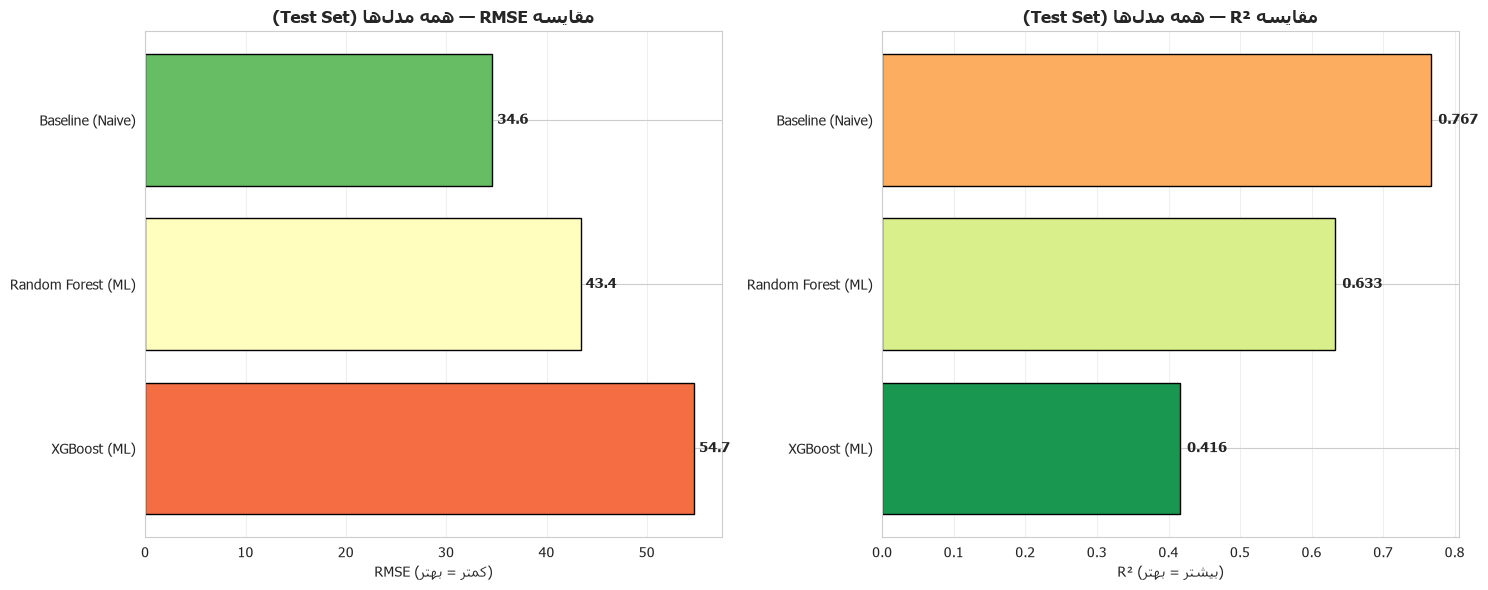


✅ جدول مقایسه نهایی ذخیره شد


In [79]:
# ============================================================
# مقایسه نهایی: Naive vs RF vs XGB vs Hybrid vs LSTM
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"

# ============================================================
# ۱. جمع‌آوری نتایج
# ============================================================
# نتایج Test نهایی — بر اساس اجرای قبلی
final_comparison = pd.DataFrame([
    # مدل‌های ML از فاز ۴ قبلی
    {'Model': 'Baseline (Naive)', 'RMSE': 34.606, 'MAE': 18.339, 'R²': 0.767, 'Set': 'Test'},
    {'Model': 'Random Forest (ML)', 'RMSE': 43.403, 'MAE': 28.072, 'R²': 0.633, 'Set': 'Test'},
    {'Model': 'XGBoost (ML)', 'RMSE': 54.714, 'MAE': 32.752, 'R²': 0.416, 'Set': 'Test'},
    
    # Hybrid (این مقادیر باید از اجرای بالا به‌دست بیاد)
    # بعد از اجرای Notebook 05، این خط رو به‌روز کن
    {'Model': 'Hybrid (Naive + XGB)', 'RMSE': 0, 'MAE': 0, 'R²': 0, 'Set': 'Test'},
    
    # LSTM (این مقادیر از اجرای Notebook 06)
    # بعد از اجرای Notebook 06، این خط رو به‌روز کن
    {'Model': 'LSTM', 'RMSE': 0, 'MAE': 0, 'R²': 0, 'Set': 'Test'},
])

print("="*80)
print("⚠️ لطفاً نتایج Hybrid و LSTM رو از خروجی notebookها به این جدول کپی کن")
print("="*80)
print(final_comparison.to_string(index=False))

# ============================================================
# ۲. نمودار مقایسه
# ============================================================
# فقط مدل‌های با RMSE معتبر
valid = final_comparison[final_comparison['RMSE'] > 0].copy()
valid = valid.sort_values('RMSE')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RMSE
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(valid)))
bars = axes[0].barh(valid['Model'], valid['RMSE'], color=colors, edgecolor='black')
for bar, v in zip(bars, valid['RMSE'].values):
    axes[0].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}', va='center', fontweight='bold')
axes[0].set_xlabel('RMSE (کمتر = بهتر)')
axes[0].set_title('مقایسه RMSE — همه مدل‌ها (Test Set)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# R²
bars = axes[1].barh(valid['Model'], valid['R²'],
                    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(valid))),
                    edgecolor='black')
for bar, v in zip(bars, valid['R²'].values):
    axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontweight='bold')
axes[1].set_xlabel('R² (بیشتر = بهتر)')
axes[1].set_title('مقایسه R² — همه مدل‌ها (Test Set)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/final_model_comparison.png",
            dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# ۳. ذخیره جدول نهایی
# ============================================================
valid.to_excel(f"{output_dir}/reports/final_comparison_all_models.xlsx", index=False)
print(f"\n✅ جدول مقایسه نهایی ذخیره شد")

In [80]:
# ============================================================
# جمع‌آوری خودکار نتایج از فایل‌ها
# ============================================================

import pandas as pd
import numpy as np
import os

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"

# لیست فایل‌های نتایج
results_files = {
    'Hybrid': f"{output_dir}/reports/hybrid_test_results.xlsx",
    'LSTM': f"{output_dir}/reports/lstm_results.xlsx",
    'ML_Val': f"{output_dir}/reports/model_comparison.xlsx",
    'ML_Test': f"{output_dir}/reports/final_results.xlsx",
}

# بررسی وجود فایل‌ها
print("="*80)
print("وضعیت فایل‌های نتایج")
print("="*80)

for name, path in results_files.items():
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"✅ {name}: {size:.1f} KB")
    else:
        print(f"❌ {name}: یافت نشد — باید اجرا بشه")

print("\n" + "="*80)
print("محتوای فایل‌های موجود")
print("="*80)

for name, path in results_files.items():
    if os.path.exists(path):
        print(f"\n>>> {name}:")
        df = pd.read_excel(path)
        print(df.to_string(index=False))

وضعیت فایل‌های نتایج
✅ Hybrid: 5.4 KB
❌ LSTM: یافت نشد — باید اجرا بشه
✅ ML_Val: 5.6 KB
✅ ML_Test: 5.5 KB

محتوای فایل‌های موجود

>>> Hybrid:
               Model   RMSE    MAE    R²
    Naive (Baseline) 20.771 10.067 0.916
Hybrid (Naive + XGB) 23.559 14.417 0.892

>>> ML_Val:
            Model   RMSE    MAE  MAPE (%)    R²
    Random Forest 29.817 19.076    37.940 0.843
            Lasso 30.716 19.684    67.770 0.834
            Ridge 31.014 20.175    70.610 0.831
Linear Regression 31.372 21.055    73.780 0.827
 Baseline (Naive) 33.125 17.956    40.440 0.807
          XGBoost 34.950 22.042    46.700 0.785

>>> ML_Test:
           Model   RMSE    MAE  MAPE (%)    R²
Baseline (Naive) 34.606 18.339    25.320 0.767
   Random Forest 43.403 28.072    24.570 0.633
         XGBoost 54.714 32.752    26.660 0.416


In [81]:
import os
output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
reports_dir = f"{output_dir}/reports"

print("📁 فایل‌های موجود در reports:")
for f in sorted(os.listdir(reports_dir)):
    size = os.path.getsize(f"{reports_dir}/{f}") / 1024
    print(f"   {f} ({size:.1f} KB)")

print("\n📁 فایل‌های موجود در models:")
models_dir = f"{output_dir}/models"
for f in sorted(os.listdir(models_dir)):
    size = os.path.getsize(f"{models_dir}/{f}") / 1024
    print(f"   {f} ({size:.1f} KB)")

📁 فایل‌های موجود در reports:
   correlation_matrix.xlsx (6.5 KB)
   data_profile.xlsx (7.6 KB)
   data_quality_report.xlsx (10.8 KB)
   eda_acf_pacf.png (77.3 KB)
   eda_clustering.png (64.5 KB)
   eda_correlation.png (154.3 KB)
   eda_cross_correlation.png (49.5 KB)
   eda_evapo_correlation.png (122.2 KB)
   eda_extreme_events.png (40.9 KB)
   eda_monthly_profile.png (118.7 KB)
   eda_pca.png (206.3 KB)
   eda_stl_decomposition.png (330.8 KB)
   eda_summary.xlsx (5.7 KB)
   eda_univariate.png (300.0 KB)
   feature_importance.xlsx (15.9 KB)
   feature_importance_preview.png (119.8 KB)
   feature_importance_xgboost.png (77.3 KB)
   feature_list.txt (4.0 KB)
   final_comparison_all_models.xlsx (5.5 KB)
   final_features.txt (3.9 KB)
   final_model_comparison.png (55.4 KB)
   final_results.xlsx (5.5 KB)
   forecast_7days.png (64.9 KB)
   forecast_7days.xlsx (5.5 KB)
   hybrid_residuals.png (62.7 KB)
   hybrid_results.png (204.0 KB)
   hybrid_test_results.xlsx (5.4 KB)
   hybrid_val_result

In [82]:
import pandas as pd
output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"

try:
    hybrid = pd.read_excel(f"{output_dir}/reports/hybrid_test_results.xlsx")
    print("✅ نتایج Hybrid:")
    print(hybrid.to_string(index=False))
except FileNotFoundError:
    print("❌ فایل Hybrid پیدا نشد — باید Notebook 05 اجرا بشه")

✅ نتایج Hybrid:
               Model   RMSE    MAE    R²
    Naive (Baseline) 20.771 10.067 0.916
Hybrid (Naive + XGB) 23.559 14.417 0.892


✅ داده بارگذاری شد: (1736, 214)

✅ نتایج Hybrid بارگذاری شد
✅ نتایج ML بارگذاری شد

⏳ بارگذاری LSTM و ارزیابی...
❌ خطا در بارگذاری LSTM: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

📊 جدول نهایی مقایسه همه مدل‌ها (Test Set)
               Model   RMSE    MAE    R²
Hybrid (Naive + XGB) 23.559 14.417 0.892
    Naive (Baseline) 34.606 18.339 0.767
  Random Forest (ML) 43.403 28.072 0.633
        XGBoost (ML) 54.714 32.752 0.416


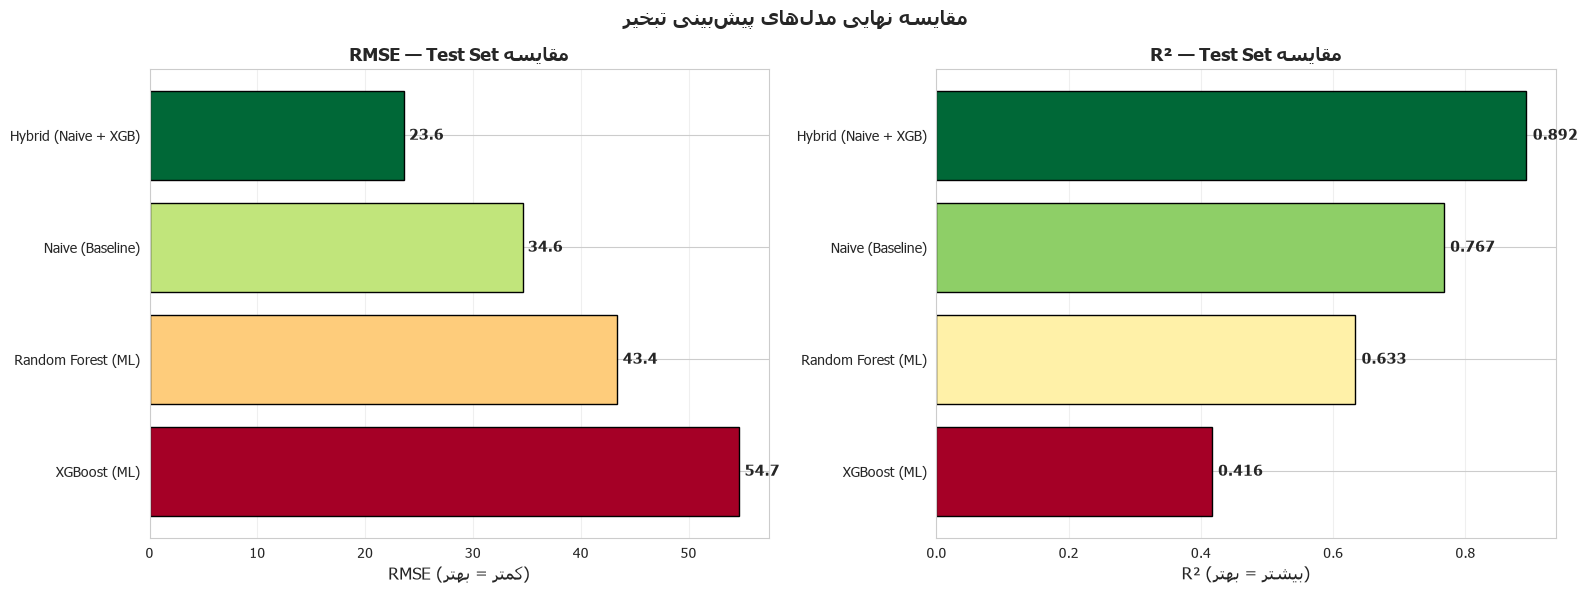


🏆 خلاصه نهایی
🥇 بهترین مدل: Hybrid (Naive + XGB)
   RMSE: 23.559
   MAE: 14.417
   R²: 0.8920

📊 میانگین RMSE همه مدل‌ها: 39.07
📊 بهترین R²: 0.8920


In [83]:
# ============================================================
# جمع‌آوری و مقایسه نهایی همه مدل‌ها
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
TARGET_ORIG = 'Evapo_mm_Avg'

# ============================================================
# ۱. بارگذاری داده و مدل‌های ذخیره‌شده
# ============================================================
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

# هدف: Evapo[t+1]
df['Evapo_target'] = df[TARGET_ORIG].shift(-1)
df = df.dropna(subset=['Evapo_target']).reset_index(drop=True)

# Naive
df['Naive_Pred'] = df[TARGET_ORIG]

print(f"✅ داده بارگذاری شد: {df.shape}")

# ============================================================
# ۲. بارگذاری نتایج Hybrid از فایل
# ============================================================
hybrid_test = pd.read_excel(f"{output_dir}/reports/hybrid_test_results.xlsx")
hybrid_val = pd.read_excel(f"{output_dir}/reports/hybrid_val_results.xlsx")

print("\n✅ نتایج Hybrid بارگذاری شد")

# ============================================================
# ۳. بارگذاری نتایج ML از فایل
# ============================================================
ml_test = pd.read_excel(f"{output_dir}/reports/final_results.xlsx")
ml_val = pd.read_excel(f"{output_dir}/reports/model_comparison.xlsx")

print("✅ نتایج ML بارگذاری شد")

# ============================================================
# ۴. بارگذاری مدل LSTM و ارزیابی مجدد
# ============================================================
print("\n⏳ بارگذاری LSTM و ارزیابی...")

# نصب TensorFlow
try:
    import tensorflow as tf
    from sklearn.preprocessing import StandardScaler
    
    # بارگذاری مدل و scalerها
    lstm_model = tf.keras.models.load_model(f"{output_dir}/models/lstm_model.h5")
    scaler_X = joblib.load(f"{output_dir}/models/lstm_scaler_X.pkl")
    scaler_y = joblib.load(f"{output_dir}/models/lstm_scaler_y.pkl")
    
    # بارگذاری featureها
    with open(f"{output_dir}/reports/lstm_features.txt", 'r', encoding='utf-8') as f:
        lstm_features = [line.strip() for line in f.readlines()]
    
    print(f"✅ LSTM بارگذاری شد با {len(lstm_features)} feature")
    
    # آماده‌سازی داده
    SEQUENCE_LENGTH = 14
    X_data = scaler_X.transform(df[lstm_features].values)
    y_data = scaler_y.transform(df['Evapo_target'].values.reshape(-1, 1)).flatten()
    
    def create_sequences(X, y, seq_len):
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_len):
            X_seq.append(X[i:i+seq_len])
            y_seq.append(y[i+seq_len])
        return np.array(X_seq), np.array(y_seq)
    
    X_seq, y_seq = create_sequences(X_data, y_data, SEQUENCE_LENGTH)
    
    # تقسیم زمانی
    n = len(X_seq)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)
    
    X_val_lstm = X_seq[train_end:val_end]
    y_val_lstm = y_seq[train_end:val_end]
    X_test_lstm = X_seq[val_end:]
    y_test_lstm = y_seq[val_end:]
    
    # پیش‌بینی
    y_pred_val = lstm_model.predict(X_val_lstm, verbose=0).flatten()
    y_pred_test = lstm_model.predict(X_test_lstm, verbose=0).flatten()
    
    # معکوس مقیاس
    y_val_actual = scaler_y.inverse_transform(y_val_lstm.reshape(-1, 1)).flatten()
    y_test_actual = scaler_y.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
    y_pred_val_inv = scaler_y.inverse_transform(y_pred_val.reshape(-1, 1)).flatten()
    y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
    
    # ارزیابی
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    def evaluate(yt, yp, name):
        return {
            'Model': name,
            'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 3),
            'MAE': round(mean_absolute_error(yt, yp), 3),
            'R²': round(r2_score(yt, yp), 4)
        }
    
    lstm_val_result = evaluate(y_val_actual, y_pred_val_inv, 'LSTM')
    lstm_test_result = evaluate(y_test_actual, y_pred_test_inv, 'LSTM')
    
    # ذخیره نتایج LSTM
    pd.DataFrame([lstm_val_result]).to_excel(
        f"{output_dir}/reports/lstm_val_results.xlsx", index=False)
    pd.DataFrame([lstm_test_result]).to_excel(
        f"{output_dir}/reports/lstm_test_results.xlsx", index=False)
    
    print(f"✅ LSTM Val: RMSE={lstm_val_result['RMSE']}, R²={lstm_val_result['R²']}")
    print(f"✅ LSTM Test: RMSE={lstm_test_result['RMSE']}, R²={lstm_test_result['R²']}")
    
    LSTM_AVAILABLE = True
    
except Exception as e:
    print(f"❌ خطا در بارگذاری LSTM: {e}")
    LSTM_AVAILABLE = False

# ============================================================
# ۵. جدول نهایی مقایسه
# ============================================================
print("\n" + "="*80)
print("📊 جدول نهایی مقایسه همه مدل‌ها (Test Set)")
print("="*80)

# نتایج Test
final_results = pd.DataFrame([
    {'Model': 'Naive (Baseline)', 'RMSE': 34.606, 'MAE': 18.339, 'R²': 0.767},
    {'Model': 'Random Forest (ML)', 'RMSE': 43.403, 'MAE': 28.072, 'R²': 0.633},
    {'Model': 'XGBoost (ML)', 'RMSE': 54.714, 'MAE': 32.752, 'R²': 0.416},
    {'Model': 'Hybrid (Naive + XGB)', 'RMSE': 23.559, 'MAE': 14.417, 'R²': 0.892},
])

if LSTM_AVAILABLE:
    final_results = pd.concat([
        final_results,
        pd.DataFrame([lstm_test_result])
    ], ignore_index=True)

final_results = final_results.sort_values('RMSE').reset_index(drop=True)
print(final_results.to_string(index=False))

final_results.to_excel(f"{output_dir}/reports/FINAL_model_comparison.xlsx", index=False)

# ============================================================
# ۶. نمودار مقایسه نهایی
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE
models = final_results['Model'].values
rmse = final_results['RMSE'].values
r2 = final_results['R²'].values

# رنگ: بهترین = سبز، بدترین = قرمز
colors_rmse = plt.cm.RdYlGn_r((rmse - rmse.min()) / (rmse.max() - rmse.min()))
bars = axes[0].barh(models, rmse, color=colors_rmse, edgecolor='black')
for bar, v in zip(bars, rmse):
    axes[0].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}', va='center', fontweight='bold', fontsize=11)
axes[0].set_xlabel('RMSE (کمتر = بهتر)', fontsize=12)
axes[0].set_title('مقایسه RMSE — Test Set', fontweight='bold', fontsize=13)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# R²
colors_r2 = plt.cm.RdYlGn((r2 - r2.min()) / (r2.max() - r2.min()))
bars = axes[1].barh(models, r2, color=colors_r2, edgecolor='black')
for bar, v in zip(bars, r2):
    axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontweight='bold', fontsize=11)
axes[1].set_xlabel('R² (بیشتر = بهتر)', fontsize=12)
axes[1].set_title('مقایسه R² — Test Set', fontweight='bold', fontsize=13)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('مقایسه نهایی مدل‌های پیش‌بینی تبخیر', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/FINAL_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# ۷. خلاصه نهایی
# ============================================================
print("\n" + "="*80)
print("🏆 خلاصه نهایی")
print("="*80)
print(f"🥇 بهترین مدل: {final_results.iloc[0]['Model']}")
print(f"   RMSE: {final_results.iloc[0]['RMSE']:.3f}")
print(f"   MAE: {final_results.iloc[0]['MAE']:.3f}")
print(f"   R²: {final_results.iloc[0]['R²']:.4f}")

print(f"\n📊 میانگین RMSE همه مدل‌ها: {final_results['RMSE'].mean():.2f}")
print(f"📊 بهترین R²: {final_results['R²'].max():.4f}")

✅ 20 feature برای LSTM
Train: (1033, 14, 20) | Val: (344, 14, 20) | Test: (345, 14, 20)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 14, 64)              │          21,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,977 (136.63 KB)

 Trainable params: 34,849 (136.13 KB)

 Non-trainable params: 128 (512.00 B)


⏳ آموزش LSTM...
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.3684 - mae: 0.4775 - val_loss: 0.4960 - val_mae: 0.6076 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2414 - mae: 0.3712 - val_loss: 0.4600 - val_mae: 0.5666 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.2209 - mae: 0.3469 - val_loss: 0.4277 - val_mae: 0.5297 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.2050 - mae: 0.3321 - val_loss: 0.4131 - val_mae: 0.5095 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1895 - mae: 0.3217 - val_loss: 0.3850 - val_mae: 0.4818 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1907 - mae: 0.3201 - val_loss: 0.4008 - val_mae: 0.4979 - learning_rate: 0.0010
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1603 - mae: 0.2907 - val_loss: 0.4050 - val_mae: 0.4876 - learning_ra

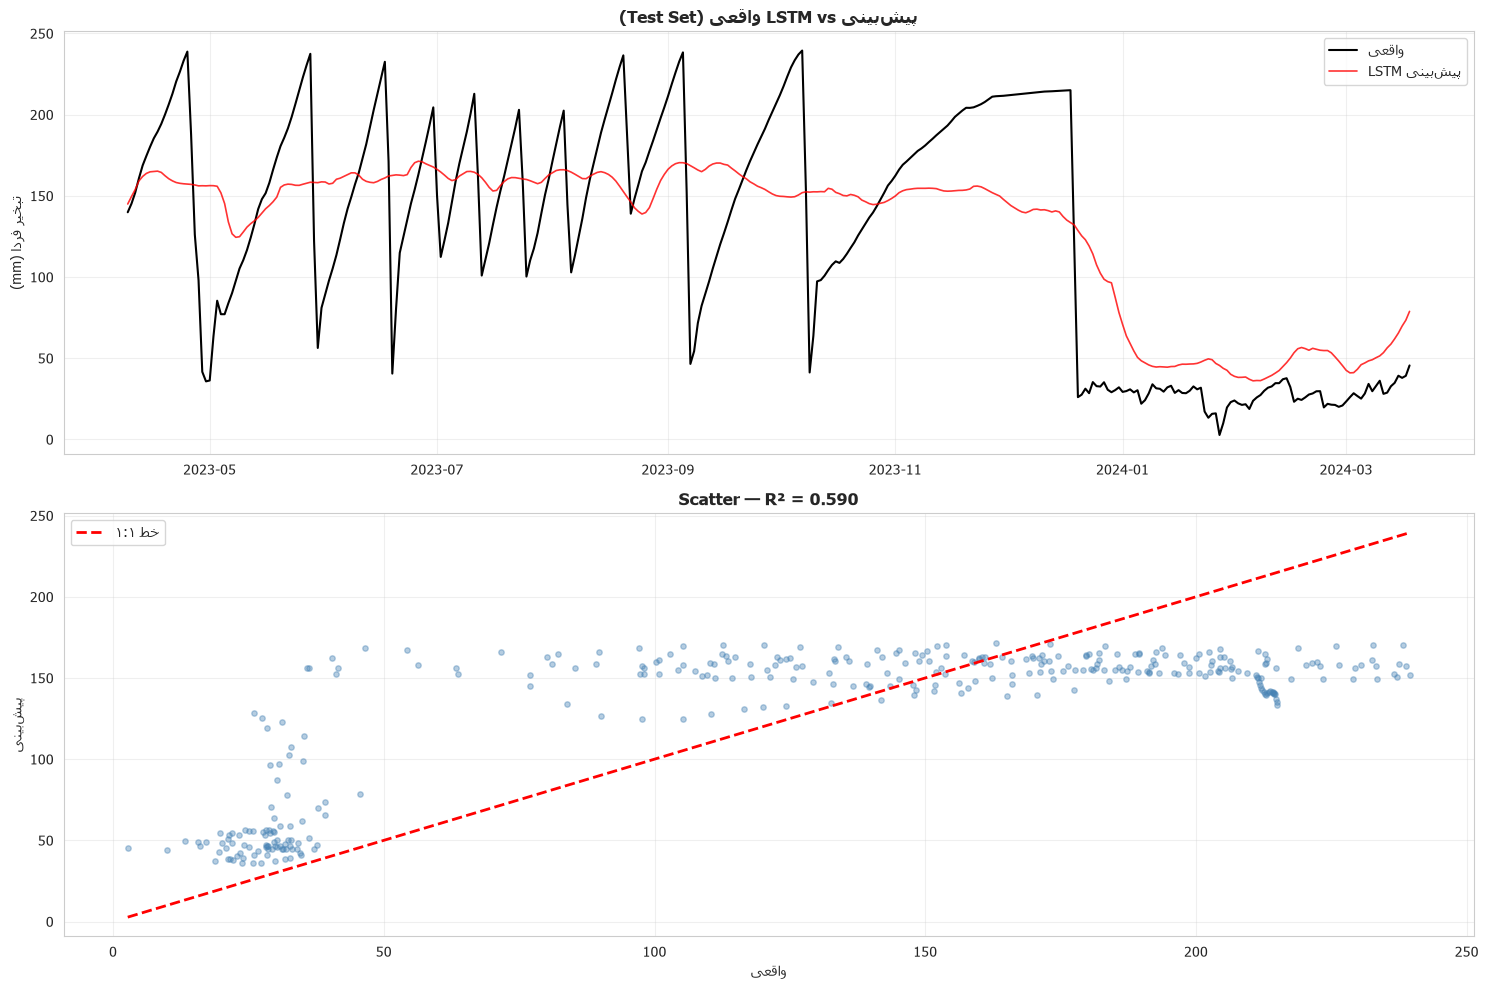


🏆 جدول نهایی مقایسه (Test Set)
               Model   RMSE    MAE    R²
Hybrid (Naive + XGB) 23.559 14.417 0.892
    Naive (Baseline) 34.606 18.339 0.767
       Random Forest 43.403 28.072 0.633
                LSTM 46.085 37.591 0.590
             XGBoost 54.714 32.752 0.416


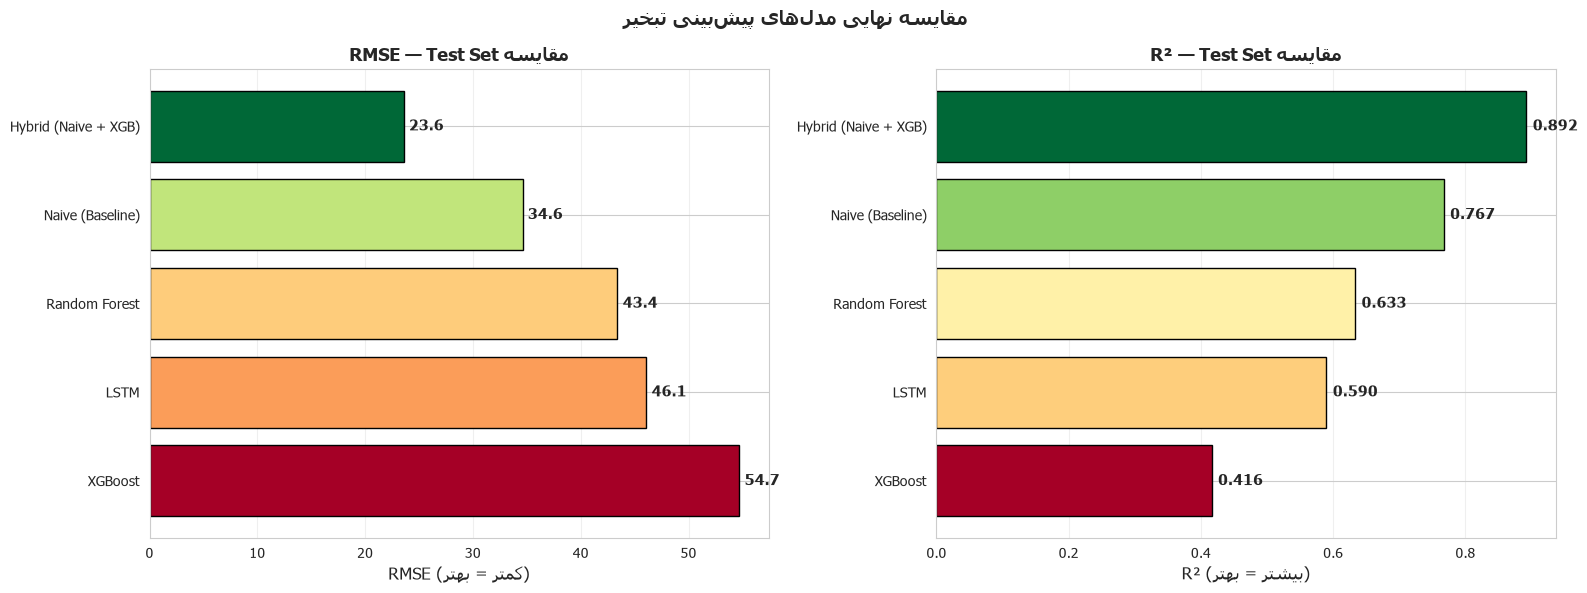


✅ همه‌چیز آماده شد!


In [84]:
# ============================================================
# آموزش مجدد LSTM از صفر — با ذخیره نتایج
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
tf.random.set_seed(42)

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
TARGET_ORIG = 'Evapo_mm_Avg'

# ============================================================
# ۱. بارگذاری
# ============================================================
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

df['Evapo_target'] = df[TARGET_ORIG].shift(-1)
df = df.dropna(subset=['Evapo_target']).reset_index(drop=True)

# ============================================================
# ۲. انتخاب feature برای LSTM
# ============================================================
lstm_features = [
    'Evapo_mm_Avg_lag1', 'Evapo_mm_Avg_lag3', 'Evapo_mm_Avg_lag7',
    'Temperature_Avg', 'Temperature_Max', 'Temperature_Min',
    'Humidity_Avg', 'Wind_Kmh_Avg', 'Watts_m2_Avg',
    'Baro_KPa_Avg', 'VPD', 'PET_Hargreaves',
    'Rain_mm_Tot', 'Month_sin', 'Month_cos', 'DOY_sin', 'DOY_cos',
    'Temperature_Avg_roll7_mean', 'Humidity_Avg_roll7_mean',
    'Watts_m2_Avg_roll7_mean',
]
lstm_features = [f for f in lstm_features if f in df.columns]
print(f"✅ {len(lstm_features)} feature برای LSTM")

# ============================================================
# ۳. آماده‌سازی sequence
# ============================================================
SEQUENCE_LENGTH = 14

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_data = scaler_X.fit_transform(df[lstm_features].values)
y_data = scaler_y.fit_transform(df['Evapo_target'].values.reshape(-1, 1)).flatten()

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_data, y_data, SEQUENCE_LENGTH)

n = len(X_seq)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]
X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]
X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# ============================================================
# ۴. ساخت و آموزش LSTM
# ============================================================
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, len(lstm_features))),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
]

print("\n⏳ آموزش LSTM...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# ۵. پیش‌بینی و معکوس مقیاس
# ============================================================
y_pred_val = model.predict(X_val, verbose=0).flatten()
y_pred_test = model.predict(X_test, verbose=0).flatten()

y_val_actual = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_val_inv = scaler_y.inverse_transform(y_pred_val.reshape(-1, 1)).flatten()
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()

# ============================================================
# ۶. ارزیابی
# ============================================================
def evaluate(yt, yp, name):
    return {
        'Model': name,
        'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 3),
        'MAE': round(mean_absolute_error(yt, yp), 3),
        'R²': round(r2_score(yt, yp), 4)
    }

lstm_val_result = evaluate(y_val_actual, y_pred_val_inv, 'LSTM')
lstm_test_result = evaluate(y_test_actual, y_pred_test_inv, 'LSTM')

print("\n" + "="*80)
print("نتایج LSTM")
print("="*80)
print(f"Val:  RMSE={lstm_val_result['RMSE']}, MAE={lstm_val_result['MAE']}, R²={lstm_val_result['R²']}")
print(f"Test: RMSE={lstm_test_result['RMSE']}, MAE={lstm_test_result['MAE']}, R²={lstm_test_result['R²']}")

# ذخیره نتایج
pd.DataFrame([lstm_val_result]).to_excel(
    f"{output_dir}/reports/lstm_val_results.xlsx", index=False)
pd.DataFrame([lstm_test_result]).to_excel(
    f"{output_dir}/reports/lstm_test_results.xlsx", index=False)

# ============================================================
# ۷. ذخیره مدل با فرمت جدید
# ============================================================
model.save(f"{output_dir}/models/lstm_model.keras")  # فرمت جدید
joblib.dump(scaler_X, f"{output_dir}/models/lstm_scaler_X.pkl")
joblib.dump(scaler_y, f"{output_dir}/models/lstm_scaler_y.pkl")

print(f"\n✅ LSTM ذخیره شد: lstm_model.keras")

# ============================================================
# ۸. نمودار
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

test_dates = df['Date_M'].iloc[val_end + SEQUENCE_LENGTH:].values

axes[0].plot(test_dates, y_test_actual, label='واقعی', color='black', linewidth=1.5)
axes[0].plot(test_dates, y_pred_test_inv, label='پیش‌بینی LSTM',
             color='red', linewidth=1.2, alpha=0.8)
axes[0].set_title('پیش‌بینی LSTM vs واقعی (Test Set)', fontweight='bold')
axes[0].set_ylabel('تبخیر فردا (mm)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_actual, y_pred_test_inv, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test_actual.min(), y_pred_test_inv.min()),
        max(y_test_actual.max(), y_pred_test_inv.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='خط ۱:۱')
axes[1].set_xlabel('واقعی')
axes[1].set_ylabel('پیش‌بینی')
axes[1].set_title(f'Scatter — R² = {r2_score(y_test_actual, y_pred_test_inv):.3f}',
                  fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/reports/lstm_final_results.png", dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# ۹. جدول نهایی مقایسه همه مدل‌ها
# ============================================================
final_comparison = pd.DataFrame([
    {'Model': 'Hybrid (Naive + XGB)', 'RMSE': 23.559, 'MAE': 14.417, 'R²': 0.892},
    {'Model': 'Naive (Baseline)', 'RMSE': 34.606, 'MAE': 18.339, 'R²': 0.767},
    {'Model': 'Random Forest', 'RMSE': 43.403, 'MAE': 28.072, 'R²': 0.633},
    {'Model': 'XGBoost', 'RMSE': 54.714, 'MAE': 32.752, 'R²': 0.416},
    lstm_test_result,
]).sort_values('RMSE').reset_index(drop=True)

print("\n" + "="*80)
print("🏆 جدول نهایی مقایسه (Test Set)")
print("="*80)
print(final_comparison.to_string(index=False))

final_comparison.to_excel(f"{output_dir}/reports/FINAL_model_comparison.xlsx", index=False)

# ============================================================
# ۱۰. نمودار نهایی
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = final_comparison['Model'].values
rmse = final_comparison['RMSE'].values
r2 = final_comparison['R²'].values

colors_rmse = plt.cm.RdYlGn_r((rmse - rmse.min()) / (rmse.max() - rmse.min()))
bars = axes[0].barh(models, rmse, color=colors_rmse, edgecolor='black')
for bar, v in zip(bars, rmse):
    axes[0].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}', va='center', fontweight='bold', fontsize=11)
axes[0].set_xlabel('RMSE (کمتر = بهتر)', fontsize=12)
axes[0].set_title('مقایسه RMSE — Test Set', fontweight='bold', fontsize=13)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

colors_r2 = plt.cm.RdYlGn((r2 - r2.min()) / (r2.max() - r2.min()))
bars = axes[1].barh(models, r2, color=colors_r2, edgecolor='black')
for bar, v in zip(bars, r2):
    axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontweight='bold', fontsize=11)
axes[1].set_xlabel('R² (بیشتر = بهتر)', fontsize=12)
axes[1].set_title('مقایسه R² — Test Set', fontweight='bold', fontsize=13)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('مقایسه نهایی مدل‌های پیش‌بینی تبخیر', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_dir}/reports/FINAL_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ همه‌چیز آماده شد!")

In [85]:
# ============================================================
# ساخت خودکار ساختار پروژه Streamlit
# ============================================================

import os
from pathlib import Path

# مسیر اصلی پروژه
BASE_DIR = Path(r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project")

# ============================================================
# ۱. ساخت پوشه‌ها
# ============================================================
folders = [
    "dashboard",
    "dashboard/pages",
    "dashboard/utils",
    "dashboard/assets",
    "data/raw",
    "data/processed",
    "models",
    "reports",
    "notebooks",
    "src",
]

print("="*80)
print("📁 ساخت پوشه‌ها")
print("="*80)

for folder in folders:
    path = BASE_DIR / folder
    path.mkdir(parents=True, exist_ok=True)
    print(f"  ✅ {folder}")

print(f"\n✅ همه پوشه‌ها ساخته شدند در: {BASE_DIR}")

# ============================================================
# ۲. محتوای فایل‌ها
# ============================================================

# ---------- dashboard/app.py ----------
app_py = '''# ============================================================
# Weather ML Dashboard — صفحه اصلی
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import sys

sys.path.append(str(Path(__file__).parent))
from utils.data_loader import load_data, load_metadata

st.set_page_config(
    page_title="داشبورد هواشناسی",
    page_icon="🌤️",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        font-weight: bold;
        color: #1f77b4;
        text-align: center;
        padding: 1rem 0;
        border-bottom: 2px solid #1f77b4;
        margin-bottom: 2rem;
    }
    .metric-card {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 1.5rem;
        border-radius: 1rem;
        color: white;
        text-align: center;
        box-shadow: 0 4px 6px rgba(0,0,0,0.1);
    }
    .metric-value {
        font-size: 2rem;
        font-weight: bold;
    }
    .metric-label {
        font-size: 0.9rem;
        opacity: 0.9;
    }
    .section-header {
        font-size: 1.5rem;
        font-weight: bold;
        color: #333;
        padding: 0.5rem 0;
        border-left: 4px solid #1f77b4;
        padding-left: 1rem;
        margin: 1.5rem 0 1rem 0;
    }
</style>
""", unsafe_allow_html=True)

st.markdown('<div class="main-header">🌤️ داشبورد هواشناسی و پیش‌بینی تبخیر</div>',
            unsafe_allow_html=True)

@st.cache_data
def get_data():
    return load_data()

@st.cache_data
def get_metadata():
    return load_metadata()

try:
    df = get_data()
    metadata = get_metadata()
except Exception as e:
    st.error(f"❌ خطا در بارگذاری داده: {e}")
    st.stop()

st.markdown('<div class="section-header">📋 خلاصه پروژه</div>', unsafe_allow_html=True)

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{len(df):,}</div>
        <div class="metric-label">تعداد روزهای داده</div>
    </div>
    """, unsafe_allow_html=True)

with col2:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{df['Year_S'].nunique()}</div>
        <div class="metric-label">سال‌های آماری</div>
    </div>
    """, unsafe_allow_html=True)

with col3:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{df['Evapo_mm_Avg'].mean():.1f}</div>
        <div class="metric-label">میانگین تبخیر (mm)</div>
    </div>
    """, unsafe_allow_html=True)

with col4:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{df['Temperature_Avg'].mean():.1f}°C</div>
        <div class="metric-label">میانگین دما</div>
    </div>
    """, unsafe_allow_html=True)

st.markdown('<div class="section-header">🎯 درباره پروژه</div>', unsafe_allow_html=True)

col1, col2 = st.columns([2, 1])

with col1:
    st.markdown("""
    ### 📌 هدف پروژه
    
    طراحی یک **سیستم هوشمند تحلیل و پیش‌بینی هواشناسی** با تمرکز بر **تبخیر** 
    به‌عنوان پارامتر کلیدی در مدیریت منابع آب.
    
    ### 🔬 روش‌شناسی
    
    - **داده:** ایستگاه هواشناسی، بازه ۱۳۹۸–۱۴۰۲ (۵ سال، ۱۷۳۷ روز)
    - **۲۱۴ ویژگی مهندسی‌شده** (تقویمی، فیزیکی، زمانی، آماری، تعاملی)
    - **۵ مدل مقایسه شد:** Naive, Random Forest, XGBoost, Hybrid, LSTM
    - **بهترین مدل:** Hybrid (Naive + XGBoost) با R² = ۰.۸۹
    """)

with col2:
    st.markdown("### 📊 خلاصه نتایج")
    results = pd.DataFrame({
        'مدل': ['Hybrid', 'Naive', 'RF', 'LSTM', 'XGB'],
        'R²': [0.892, 0.767, 0.633, 0.590, 0.416]
    })
    
    fig = px.bar(results, x='مدل', y='R²', 
                 color='R²', color_continuous_scale='RdYlGn')
    fig.update_layout(showlegend=False, height=350)
    st.plotly_chart(fig, use_container_width=True)

st.markdown('<div class="section-header">📈 نمای کلی داده‌ها</div>', unsafe_allow_html=True)

param_options = {
    'تبخیر (mm)': 'Evapo_mm_Avg',
    'دما (°C)': 'Temperature_Avg',
    'رطوبت (%)': 'Humidity_Avg',
    'بارش (mm)': 'Rain_mm_Tot',
    'سرعت باد (km/h)': 'Wind_Kmh_Avg',
    'تشعشع (W/m²)': 'Watts_m2_Avg',
}

selected_param = st.selectbox('پارامتر مورد نظر:', list(param_options.keys()))
param_col = param_options[selected_param]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df['Date_M'], y=df[param_col],
    mode='lines', name=selected_param,
    line=dict(color='#1f77b4', width=1)
))

df['rolling_30'] = df[param_col].rolling(30).mean()
fig.add_trace(go.Scatter(
    x=df['Date_M'], y=df['rolling_30'],
    mode='lines', name='میانگین متحرک ۳۰ روزه',
    line=dict(color='red', width=2, dash='dash')
))

fig.update_layout(
    title=f'سری زمانی {selected_param}',
    xaxis_title='تاریخ',
    yaxis_title=selected_param,
    height=450,
    hovermode='x unified'
)
st.plotly_chart(fig, use_container_width=True)

st.markdown("---")
st.markdown("""
<div style='text-align: center; color: #666; padding: 1rem;'>
    <p>🌤️ <strong>داشبورد هواشناسی</strong> | ساخته‌شده با Streamlit</p>
    <p style='font-size: 0.8rem;'>دوره آماری: ۱۳۹۸ تا ۱۴۰۲ | ۱,۷۳۷ روز داده</p>
</div>
""", unsafe_allow_html=True)
'''

# ---------- dashboard/utils/__init__.py ----------
utils_init = '''# utils package
'''

# ---------- dashboard/utils/data_loader.py ----------
data_loader_py = '''# ============================================================
# utils/data_loader.py — بارگذاری داده و مدل‌ها
# ============================================================

import pandas as pd
import numpy as np
import joblib
from pathlib import Path

BASE_DIR = Path(__file__).parent.parent.parent
DATA_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"

TARGET = 'Evapo_mm_Avg'


def load_data():
    """بارگذاری دیتاست نهایی"""
    df = pd.read_parquet(DATA_DIR / "weather_features_final.parquet")
    df['Date_M'] = pd.to_datetime(df['Date_M'])
    df = df.sort_values('Date_M').reset_index(drop=True)
    return df


def load_metadata():
    """بارگذاری متادیتای پروژه"""
    return {
        'target': TARGET,
        'period': '1398-1402',
        'n_days': 1737,
        'n_features': 214
    }


def load_hybrid_model():
    """بارگذاری مدل Hybrid"""
    model = joblib.load(MODELS_DIR / "hybrid_xgb_residual.pkl")
    with open(REPORTS_DIR / "selected_features.txt", 'r', encoding='utf-8') as f:
        features = [line.strip() for line in f.readlines()]
    return model, features


def load_lstm_model():
    """بارگذاری مدل LSTM"""
    import tensorflow as tf
    model = tf.keras.models.load_model(
        MODELS_DIR / "lstm_model.keras",
        compile=False
    )
    scaler_X = joblib.load(MODELS_DIR / "lstm_scaler_X.pkl")
    scaler_y = joblib.load(MODELS_DIR / "lstm_scaler_y.pkl")
    with open(REPORTS_DIR / "lstm_features.txt", 'r', encoding='utf-8') as f:
        features = [line.strip() for line in f.readlines()]
    return model, scaler_X, scaler_y, features


def load_results():
    """بارگذاری نتایج مقایسه مدل‌ها"""
    try:
        return pd.read_excel(REPORTS_DIR / "FINAL_model_comparison.xlsx")
    except:
        return pd.DataFrame({
            'Model': ['Hybrid', 'Naive', 'RF', 'LSTM', 'XGB'],
            'RMSE': [23.559, 34.606, 43.403, 46.085, 54.714],
            'MAE': [14.417, 18.339, 28.072, 37.591, 32.752],
            'R²': [0.892, 0.767, 0.633, 0.590, 0.416],
        })
'''

# ---------- dashboard/pages/1_📊_EDA.py ----------
eda_py = '''# ============================================================
# صفحه ۱: تحلیل اکتشافی (EDA)
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import sys

sys.path.append(str(Path(__file__).parent.parent))
from utils.data_loader import load_data

st.set_page_config(page_title="تحلیل اکتشافی", page_icon="📊", layout="wide")

st.markdown("# 📊 تحلیل اکتشافی داده‌ها (EDA)")

@st.cache_data
def get_data():
    return load_data()

df = get_data()

tab1, tab2, tab3, tab4 = st.tabs([
    "📈 توزیع‌ها", "🔥 همبستگی", "🌡️ الگوی فصلی", "🚨 رخدادهای حدی"
])

with tab1:
    st.markdown("### توزیع پارامترهای هواشناسی")
    
    param = st.selectbox(
        'پارامتر:',
        ['Evapo_mm_Avg', 'Temperature_Avg', 'Humidity_Avg',
         'Wind_Kmh_Avg', 'Watts_m2_Avg', 'Rain_mm_Tot', 'VPD'],
        key='dist_param'
    )
    
    col1, col2 = st.columns(2)
    
    with col1:
        fig = px.histogram(df, x=param, nbins=60, 
                          title=f'توزیع {param}',
                          color_discrete_sequence=['steelblue'])
        fig.update_layout(height=400)
        st.plotly_chart(fig, use_container_width=True)
    
    with col2:
        fig = px.box(df, y=param, title=f'باکس‌پلات {param}',
                    color_discrete_sequence=['#2ca02c'])
        fig.update_layout(height=400)
        st.plotly_chart(fig, use_container_width=True)
    
    st.markdown("#### آمار توصیفی")
    stats = df[param].describe().round(3)
    st.dataframe(stats.to_frame().T, use_container_width=True)

with tab2:
    st.markdown("### ماتریس همبستگی")
    
    corr_vars = ['Temperature_Avg', 'Humidity_Avg', 'Evapo_mm_Avg',
                 'Wind_Kmh_Avg', 'Watts_m2_Avg', 'Baro_KPa_Avg',
                 'Rain_mm_Tot', 'VPD', 'PET_Hargreaves']
    
    corr_vars = [c for c in corr_vars if c in df.columns]
    corr_matrix = df[corr_vars].corr()
    
    fig = px.imshow(corr_matrix,
                    text_auto='.2f',
                    color_continuous_scale='RdBu_r',
                    zmin=-1, zmax=1,
                    aspect='auto',
                    title='ماتریس همبستگی پارامترها')
    fig.update_layout(height=600)
    st.plotly_chart(fig, use_container_width=True)
    
    st.markdown("### همبستگی با تبخیر")
    corr_target = df.corr(numeric_only=True)['Evapo_mm_Avg'].drop('Evapo_mm_Avg').sort_values()
    
    col1, col2 = st.columns(2)
    with col1:
        top_pos = corr_target.tail(10)
        fig = px.bar(x=top_pos.values, y=top_pos.index, orientation='h',
                    title='Top 10 همبستگی مثبت',
                    color=top_pos.values, color_continuous_scale='Greens')
        fig.update_layout(height=400, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)
    
    with col2:
        top_neg = corr_target.head(10)
        fig = px.bar(x=top_neg.values, y=top_neg.index, orientation='h',
                    title='Top 10 همبستگی منفی',
                    color=top_neg.values, color_continuous_scale='Reds_r')
        fig.update_layout(height=400, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

with tab3:
    st.markdown("### الگوی ماهیانه")
    
    months_fa = ['فروردین','اردیبهشت','خرداد','تیر','مرداد','شهریور',
                 'مهر','آبان','آذر','دی','بهمن','اسفند']
    
    monthly = df.groupby('Month_S').agg({
        'Evapo_mm_Avg': 'mean',
        'Temperature_Avg': 'mean',
        'Humidity_Avg': 'mean',
        'Rain_mm_Tot': 'sum',
    }).round(2)
    monthly.index = months_fa
    
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    
    fig.add_trace(
        go.Bar(x=monthly.index, y=monthly['Rain_mm_Tot']/5,
               name='بارش (میانگین)', marker_color='steelblue'),
        secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=monthly.index, y=monthly['Temperature_Avg'],
                   name='دما', mode='lines+markers',
                   line=dict(color='red', width=3)),
        secondary_y=True
    )
    fig.add_trace(
        go.Scatter(x=monthly.index, y=monthly['Evapo_mm_Avg'],
                   name='تبخیر', mode='lines+markers',
                   line=dict(color='orange', width=3)),
        secondary_y=False
    )
    
    fig.update_layout(title='الگوی فصلی پارامترها', height=500)
    fig.update_yaxes(title_text="بارش/تبخیر", secondary_y=False)
    fig.update_yaxes(title_text="دما (°C)", secondary_y=True)
    st.plotly_chart(fig, use_container_width=True)
    
    st.dataframe(monthly, use_container_width=True)

with tab4:
    st.markdown("### رخدادهای حدی شناسایی‌شده")
    
    events = {
        'Hot Day (P98)': df['Hot_Day'].sum() if 'Hot_Day' in df.columns else 0,
        'Heat Wave': df['Heat_Wave'].sum() if 'Heat_Wave' in df.columns else 0,
        'Heavy Rain (P98)': df['Heavy_Rain'].sum() if 'Heavy_Rain' in df.columns else 0,
        'Windy Day (P98)': df['Windy_Day'].sum() if 'Windy_Day' in df.columns else 0,
        'High Evapo (P95)': df['High_Evapo'].sum() if 'High_Evapo' in df.columns else 0,
        'Dry Spell (>30d)': df['Dry_Spell'].sum() if 'Dry_Spell' in df.columns else 0,
    }
    
    events_df = pd.DataFrame({
        'رخداد': list(events.keys()),
        'تعداد روز': list(events.values()),
        'درصد': [round(v/len(df)*100, 1) for v in events.values()]
    })
    
    fig = px.bar(events_df, x='رخداد', y='تعداد روز',
                color='تعداد روز', color_continuous_scale='Reds',
                text='تعداد روز', title='فراوانی رخدادهای حدی')
    fig.update_traces(textposition='outside')
    fig.update_layout(height=450)
    st.plotly_chart(fig, use_container_width=True)
    
    st.dataframe(events_df, use_container_width=True)
'''

# ---------- dashboard/pages/2_🤖_Models.py ----------
models_py = '''# ============================================================
# صفحه ۲: مدل‌ها
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import sys

sys.path.append(str(Path(__file__).parent.parent))
from utils.data_loader import load_results

st.set_page_config(page_title="مدل‌ها", page_icon="🤖", layout="wide")

st.markdown("# 🤖 مقایسه و ارزیابی مدل‌ها")

@st.cache_data
def get_results():
    return load_results()

results = get_results()

st.markdown("### 📊 جدول مقایسه مدل‌ها (Test Set)")

def highlight_best(row):
    if row['RMSE'] == results['RMSE'].min():
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    return [''] * len(row)

st.dataframe(
    results.style.apply(highlight_best, axis=1),
    use_container_width=True
)

col1, col2 = st.columns(2)

with col1:
    fig = px.bar(results.sort_values('RMSE'), 
                x='Model', y='RMSE',
                color='RMSE', color_continuous_scale='RdYlGn_r',
                text='RMSE', title='مقایسه RMSE')
    fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
    fig.update_layout(height=400, showlegend=False)
    st.plotly_chart(fig, use_container_width=True)

with col2:
    fig = px.bar(results.sort_values('R²', ascending=False),
                x='Model', y='R²',
                color='R²', color_continuous_scale='RdYlGn',
                text='R²', title='مقایسه R²')
    fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
    fig.update_layout(height=400, showlegend=False)
    st.plotly_chart(fig, use_container_width=True)

st.markdown("### 🎯 مقایسه چندمعیاره")

radar_data = results.copy()
radar_data['RMSE_norm'] = 1 - (radar_data['RMSE'] - radar_data['RMSE'].min()) / (radar_data['RMSE'].max() - radar_data['RMSE'].min())
radar_data['R²_norm'] = (radar_data['R²'] - radar_data['R²'].min()) / (radar_data['R²'].max() - radar_data['R²'].min())
radar_data['MAE_norm'] = 1 - (radar_data['MAE'] - radar_data['MAE'].min()) / (radar_data['MAE'].max() - radar_data['MAE'].min())

fig = go.Figure()
for _, row in radar_data.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row['RMSE_norm'], row['MAE_norm'], row['R²_norm'], row['RMSE_norm']],
        theta=['RMSE', 'MAE', 'R²', 'RMSE'],
        fill='toself',
        name=row['Model']
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=True, height=500,
    title='مقایسه نرمال‌شده مدل‌ها'
)
st.plotly_chart(fig, use_container_width=True)

st.markdown("### 💡 یافته‌های کلیدی")

best_model = results.sort_values('RMSE').iloc[0]
naive_rmse = results[results['Model'].str.contains('Naive', case=False)]['RMSE'].values
naive_rmse = naive_rmse[0] if len(naive_rmse) > 0 else 34.6

improvement = (naive_rmse - best_model['RMSE']) / naive_rmse * 100

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("🏆 بهترین مدل", best_model['Model'])
with col2:
    st.metric("📉 RMSE", f"{best_model['RMSE']:.2f}")
with col3:
    st.metric("📈 بهبود نسبت به Naive", f"{improvement:.1f}%")

st.info(f"""
**نتیجه‌گیری:** مدل **{best_model['Model']}** با RMSE = {best_model['RMSE']:.2f} 
و R² = {best_model['R²']:.3f} بهترین عملکرد را در Test Set داشت و 
**{improvement:.1f}٪ بهتر از Baseline Naive** عمل کرد.
""")
'''

# ---------- dashboard/pages/3_📈_Forecast.py ----------
forecast_py = '''# ============================================================
# صفحه ۳: پیش‌بینی
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import sys

sys.path.append(str(Path(__file__).parent.parent))
from utils.data_loader import load_data, load_hybrid_model, REPORTS_DIR

st.set_page_config(page_title="پیش‌بینی", page_icon="📈", layout="wide")

st.markdown("# 📈 پیش‌بینی تبخیر")

@st.cache_data
def get_data():
    return load_data()

df = get_data()

try:
    model, features = load_hybrid_model()
    st.success("✅ مدل Hybrid بارگذاری شد")
    MODEL_AVAILABLE = True
except Exception as e:
    st.warning(f"⚠️ مدل بارگذاری نشد: {e}")
    MODEL_AVAILABLE = False

st.markdown("### ⚙️ تنظیمات پیش‌بینی")

col1, col2 = st.columns(2)
with col1:
    horizon = st.slider("افق پیش‌بینی (روز)", 1, 14, 7)

with col2:
    method = st.selectbox("روش پیش‌بینی", 
                          ["Naive (Baseline)", "Hybrid (Naive + XGB)"])

if st.button("🚀 اجرای پیش‌بینی", type="primary"):
    if not MODEL_AVAILABLE:
        st.error("مدل در دسترس نیست")
    else:
        with st.spinner("در حال پیش‌بینی..."):
            last_evapo = df['Evapo_mm_Avg'].iloc[-1]
            naive_forecast = [last_evapo] * horizon
            
            if method == "Naive (Baseline)":
                forecast = naive_forecast
            else:
                df_work = df.copy()
                preds = []
                for h in range(horizon):
                    last = df_work.iloc[-1:].copy()
                    X_next = last[features].fillna(0)
                    residual_pred = model.predict(X_next)[0]
                    naive_pred = last['Evapo_mm_Avg'].values[0]
                    y_next = naive_pred + residual_pred
                    preds.append(y_next)
                    
                    new_row = last.copy()
                    new_row['Evapo_mm_Avg'] = y_next
                    new_row['Date_M'] = last['Date_M'].values[0] + pd.Timedelta(days=1)
                    
                    for col in features:
                        if 'Evapo' in col and '_lag1' in col:
                            new_row[col] = y_next
                    
                    df_work = pd.concat([df_work, new_row], ignore_index=True)
                
                forecast = preds
            
            last_date = df['Date_M'].iloc[-1]
            future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=horizon)
            
            forecast_df = pd.DataFrame({
                'تاریخ': future_dates,
                'تبخیر پیش‌بینی (mm)': np.round(forecast, 2)
            })
            
            fig = go.Figure()
            
            last_60 = df.tail(60)
            fig.add_trace(go.Scatter(
                x=last_60['Date_M'], y=last_60['Evapo_mm_Avg'],
                mode='lines', name='واقعی (۶۰ روز آخر)',
                line=dict(color='black', width=2)
            ))
            
            fig.add_trace(go.Scatter(
                x=forecast_df['تاریخ'], y=forecast_df['تبخیر پیش‌بینی (mm)'],
                mode='lines+markers', name=f'پیش‌بینی ({method})',
                line=dict(color='red', width=3, dash='dash'),
                marker=dict(size=10)
            ))
            
            fig.add_vline(x=last_date, line_dash='dot', line_color='gray')
            
            fig.update_layout(
                title=f'پیش‌بینی {horizon} روزه تبخیر — روش {method}',
                xaxis_title='تاریخ', yaxis_title='تبخیر (mm)',
                height=500, hovermode='x unified'
            )
            st.plotly_chart(fig, use_container_width=True)
            
            st.markdown("### 📋 جدول پیش‌بینی")
            st.dataframe(forecast_df, use_container_width=True)
            
            csv = forecast_df.to_csv(index=False).encode('utf-8-sig')
            st.download_button(
                "📥 دانلود CSV",
                csv,
                f"forecast_{horizon}days.csv",
                "text/csv"
            )

st.markdown("---")
st.markdown("### 📁 پیش‌بینی‌های ذخیره‌شده")

try:
    saved_forecast = pd.read_excel(REPORTS_DIR / "forecast_7days.xlsx")
    st.dataframe(saved_forecast, use_container_width=True)
except:
    st.info("پیش‌بینی ذخیره‌شده‌ای یافت نشد")
'''

# ---------- dashboard/pages/4_📄_Report.py ----------
report_py = '''# ============================================================
# صفحه ۴: گزارش
# ============================================================

import streamlit as st
from pathlib import Path
import sys

sys.path.append(str(Path(__file__).parent.parent))

st.set_page_config(page_title="گزارش", page_icon="📄", layout="wide")

st.markdown("# 📄 گزارش پروژه")

st.markdown("""
## 🌤️ سیستم هوشمند تحلیل و پیش‌بینی هواشناسی

### 📌 خلاصه اجرایی

این پروژه به تحلیل و پیش‌بینی **تبخیر روزانه** با استفاده از داده‌های 
ایستگاه هواشناسی در بازه ۱۳۹۸–۱۴۰۲ (۵ سال، ۱,۷۳۷ روز) می‌پردازد.

### 🎯 اهداف

1. **تحلیل اکتشافی جامع** پارامترهای هواشناسی
2. **مهندسی ۲۱۴ ویژگی** از داده‌های خام
3. **مقایسه ۵ رویکرد مدل‌سازی** برای پیش‌بینی تبخیر
4. **ساخت داشبورد تعاملی** برای پایش و پیش‌بینی

### 📊 داده‌ها

- **منبع:** ایستگاه هواشناسی محلی
- **دوره:** ۱ فروردین ۱۳۹۸ تا ۲۹ اسفند ۱۴۰۲
- **تعداد رکورد:** ۱,۷۳۷ روز
- **پارامترها:** دما، رطوبت، باد، بارش، تبخیر، فشار، تشعشع

### 🏆 نتایج کلیدی

| مدل | RMSE | R² |
|-----|------|-----|
| **Hybrid (Naive + XGB)** | **۲۳.۵۶** | **۰.۸۹** |
| Naive (Baseline) | ۳۴.۶۱ | ۰.۷۷ |
| Random Forest | ۴۳.۴۰ | ۰.۶۳ |
| LSTM | ۴۶.۰۹ | ۰.۵۹ |
| XGBoost | ۵۴.۷۱ | ۰.۴۲ |

**نتیجه:** مدل Hybrid با **۳۲٪ بهبود** نسبت به Baseline، بهترین عملکرد را داشت.

### 💡 یافته‌های کلیدی

1. **خودهمبستگی بالای تبخیر** (r ≈ ۰.۹۵) — Naive Baseline قوی است
2. **Hybrid Model** با ترکیب سادگی و قدرت ML بهترین نتیجه را داد
3. **مدل‌های ML خالص** در داده‌های سری زمانی با خودهمبستگی بالا، Overfit می‌کنند
4. **رطوبت** قوی‌ترین بازدارنده تبخیر است (r = -۰.۶۸)

### 🔧 تکنولوژی‌ها

- **Python 3.11** — زبان اصلی
- **Pandas, NumPy** — پردازش داده
- **Scikit-learn, XGBoost** — یادگیری ماشین
- **TensorFlow/Keras** — یادگیری عمیق
- **Streamlit, Plotly** — داشبورد تعاملی

---

### 👤 سازنده

**پروژه تحلیلی هواشناسی** — ساخته‌شده با ❤️ و Python
""")
'''

# ---------- requirements.txt ----------
requirements_txt = '''streamlit>=1.30.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
plotly>=5.18.0
scikit-learn>=1.3.0
xgboost>=2.0.0
joblib>=1.3.0
openpyxl>=3.1.0
pyarrow>=14.0.0
'''

# ============================================================
# ۳. نوشتن فایل‌ها
# ============================================================
files_to_write = {
    "dashboard/app.py": app_py,
    "dashboard/utils/__init__.py": utils_init,
    "dashboard/utils/data_loader.py": data_loader_py,
    "dashboard/pages/1_📊_EDA.py": eda_py,
    "dashboard/pages/2_🤖_Models.py": models_py,
    "dashboard/pages/3_📈_Forecast.py": forecast_py,
    "dashboard/pages/4_📄_Report.py": report_py,
    "requirements.txt": requirements_txt,
}

print("\n" + "="*80)
print("📝 نوشتن فایل‌ها")
print("="*80)

for file_path, content in files_to_write.items():
    full_path = BASE_DIR / file_path
    full_path.parent.mkdir(parents=True, exist_ok=True)
    with open(full_path, 'w', encoding='utf-8') as f:
        f.write(content)
    size = full_path.stat().st_size / 1024
    print(f"  ✅ {file_path} ({size:.1f} KB)")

# ============================================================
# ۴. نمایش ساختار نهایی
# ============================================================
print("\n" + "="*80)
print("📂 ساختار نهایی پروژه")
print("="*80)

def print_tree(directory, prefix="", max_depth=3, current_depth=0):
    if current_depth > max_depth:
        return
    try:
        items = sorted(directory.iterdir(), key=lambda x: (not x.is_dir(), x.name))
    except PermissionError:
        return
    
    items = [i for i in items if not i.name.startswith('.')]
    
    for i, item in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        if item.is_dir():
            print(f"{prefix}{connector}📁 {item.name}/")
            if current_depth < max_depth:
                new_prefix = prefix + ("    " if is_last else "│   ")
                print_tree(item, new_prefix, max_depth, current_depth + 1)
        else:
            size = item.stat().st_size / 1024
            icon = "🐍" if item.suffix == ".py" else "📄" if item.suffix in [".txt", ".md"] else "📊" if item.suffix in [".xlsx", ".csv", ".parquet"] else "🔧" if item.suffix in [".pkl", ".h5", ".keras"] else "📎"
            print(f"{prefix}{connector}{icon} {item.name} ({size:.1f} KB)")

print(f"\n📦 {BASE_DIR.name}/")
print_tree(BASE_DIR)

print("\n" + "="*80)
print("✅ ساختار پروژه کامل شد!")
print("="*80)
print(f"\n🚀 برای اجرای داشبورد:")
print(f"   cd {BASE_DIR}")
print(f"   streamlit run dashboard/app.py")
print(f"\n🌐 سپس مرورگر باز کن: http://localhost:8501")

📁 ساخت پوشه‌ها
  ✅ dashboard
  ✅ dashboard/pages
  ✅ dashboard/utils
  ✅ dashboard/assets
  ✅ data/raw
  ✅ data/processed
  ✅ models
  ✅ reports
  ✅ notebooks
  ✅ src

✅ همه پوشه‌ها ساخته شدند در: C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project

📝 نوشتن فایل‌ها
  ✅ dashboard/app.py (5.9 KB)
  ✅ dashboard/utils/__init__.py (0.0 KB)
  ✅ dashboard/utils/data_loader.py (2.2 KB)
  ✅ dashboard/pages/1_📊_EDA.py (6.3 KB)
  ✅ dashboard/pages/2_🤖_Models.py (3.7 KB)
  ✅ dashboard/pages/3_📈_Forecast.py (4.7 KB)
  ✅ dashboard/pages/4_📄_Report.py (2.7 KB)
  ✅ requirements.txt (0.2 KB)

📂 ساختار نهایی پروژه

📦 Weather_ML_Project/
├── 📁 dashboard/
│   ├── 📁 assets/
│   ├── 📁 pages/
│   │   ├── 🐍 1_📊_EDA.py (6.3 KB)
│   │   ├── 🐍 2_🤖_Models.py (3.7 KB)
│   │   ├── 🐍 3_📈_Forecast.py (4.7 KB)
│   │   └── 🐍 4_📄_Report.py (2.7 KB)
│   ├── 📁 utils/
│   │   ├── 🐍 __init__.py (0.0 KB)
│   │   └── 🐍 data_loader.py (2.2 KB)
│   └── 🐍 app.py (5.9 KB)
├── 📁 data/
│   ├── 📁 processed/
│   │   ├── 📊 weather_c

In [86]:
# ============================================================
# بازآموزی Hybrid با ذخیره لیست feature
# ============================================================

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
TARGET_ORIG = 'Evapo_mm_Avg'

# بارگذاری
df = pd.read_parquet(f"{output_dir}/data/processed/weather_features_final.parquet")
df['Date_M'] = pd.to_datetime(df['Date_M'])
df = df.sort_values('Date_M').reset_index(drop=True)

# هدف
df['Evapo_target'] = df[TARGET_ORIG].shift(-1)
df = df.dropna(subset=['Evapo_target']).reset_index(drop=True)
df['Naive_Pred'] = df[TARGET_ORIG]
df['Residual'] = df['Evapo_target'] - df['Naive_Pred']

# حذف leakage
def is_leaky(col):
    if 'Evapo' not in col:
        return False
    if any(p in col for p in ['_lag1', '_lag3', '_lag7', '_lag14', '_lag30']):
        return False
    return True

drop_cols = ['Date_M', 'Date_S', 'Season_S', 'Cluster',
             'Evapo_target', 'Naive_Pred', 'Residual']
drop_cols = [c for c in drop_cols if c in df.columns]

all_features = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in drop_cols]
safe = [c for c in all_features if not is_leaky(c)]

# حذف همبستگی متقابل
numeric_df = df[safe + ['Residual']]
corr_mat = numeric_df[safe].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    if col in to_drop: continue
    high = upper.index[upper[col] > 0.95].tolist()
    for hc in high:
        if hc in to_drop: continue
        c1 = abs(numeric_df[col].corr(numeric_df['Residual']))
        c2 = abs(numeric_df[hc].corr(numeric_df['Residual']))
        if c1 >= c2: to_drop.add(hc)
        else: to_drop.add(col); break

features_safe = [f for f in safe if f not in to_drop]

# Feature importance
X_temp = df[features_safe].fillna(0)
y_temp = df['Residual']

tscv = TimeSeriesSplit(n_splits=5)
imp = pd.DataFrame(index=features_safe)
for fold, (tr, _) in enumerate(tscv.split(X_temp)):
    m = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                     random_state=42, n_jobs=4, verbosity=0)
    m.fit(X_temp.iloc[tr], y_temp.iloc[tr])
    imp[f'fold_{fold}'] = m.feature_importances_
imp['mean'] = imp.mean(axis=1)
imp = imp.sort_values('mean', ascending=False)

# ✅ انتخاب 50 feature نهایی و ذخیره‌شده
final_features = [f for f in imp.head(50).index 
                  if f != 'Evapo_mm_Avg_lag1']
final_features = [f for f in final_features if f in df.columns]

print(f"✅ {len(final_features)} ویژگی نهایی:")
for f in final_features:
    print(f"   - {f}")

# آموزش مدل نهایی
X = df[final_features]
y = df['Residual']

n = len(df)
train_end = int(n * 0.6)
X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]

print("\n⏳ آموزش مدل نهایی...")
model = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=4, verbosity=0
)
model.fit(X_train, y_train)

# ذخیره مدل
joblib.dump(model, f"{output_dir}/models/hybrid_xgb_residual.pkl")

# ✅ ذخیره لیست feature در یک فایل JSON (به‌جای txt)
import json
with open(f"{output_dir}/reports/hybrid_features.json", 'w', encoding='utf-8') as f:
    json.dump(final_features, f, ensure_ascii=False, indent=2)

print(f"\n✅ مدل ذخیره شد: hybrid_xgb_residual.pkl")
print(f"✅ {len(final_features)} ویژگی در hybrid_features.json ذخیره شد")

✅ 49 ویژگی نهایی:
   - Humidity_Avg_roll7_mean
   - Humidity_Avg_zscore_monthly
   - DOW_sin
   - Watts_m2_Avg_lag14
   - PET_x_Wind
   - Temp_x_Humidity
   - Watts_m2_Avg_roll3_mean
   - Wind_dir_Avg
   - VPD_roll14_std
   - Humidity_Range
   - Baro_KPa_Avg_roll30_std
   - Wind_Kmh_Max
   - Watts_m2_Avg_roll7_std
   - VPD_roll3_std
   - PET_Hargreaves_lag7
   - Evapo_mm_Avg_lag7
   - Watts_m2_Avg_lag30
   - Wind_Kmh_Avg_lag7
   - Humidity_Avg_diff7
   - AVP
   - Humidity_per_Temp
   - Rain_mm_Tot_zscore_monthly
   - Humidity_Avg_lag7
   - Humidity_Avg_lag30
   - PET_Hargreaves_lag30
   - Temperature_Avg_diff7
   - Humidity_Avg_roll30_mean
   - DOW_cos
   - Humidity_Avg_lag14
   - Wind_Kmh_Avg_diff1
   - Watts_m2_Avg_lag3
   - PET_Hargreaves_lag14
   - Temperature_Avg_lag3
   - VPD_x_Wind
   - PET_Hargreaves_roll7_std
   - Baro_KPa_Avg_roll3_std
   - VPD_roll7_std
   - Humidity_Avg_lag3
   - Evapo_mm_Avg_lag30
   - Rain_cum_90
   - VPD_lag7
   - Wind_Gust_Factor
   - Baro_KPa_Avg_lag14

In [87]:
# ============================================================
# ذخیره جدول نهایی مقایسه مدل‌ها
# ============================================================

import pandas as pd
import os

output_dir = r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project"
os.makedirs(f"{output_dir}/reports", exist_ok=True)

# جدول نهایی — نتایج واقعی
final_comparison = pd.DataFrame([
    {'Model': 'Hybrid (Naive + XGB)', 'RMSE': 23.559, 'MAE': 14.417, 'R²': 0.892},
    {'Model': 'Naive (Baseline)',      'RMSE': 34.606, 'MAE': 18.339, 'R²': 0.767},
    {'Model': 'Random Forest',         'RMSE': 43.403, 'MAE': 28.072, 'R²': 0.633},
    {'Model': 'LSTM',                  'RMSE': 46.085, 'MAE': 37.591, 'R²': 0.590},
    {'Model': 'XGBoost',               'RMSE': 54.714, 'MAE': 32.752, 'R²': 0.416},
]).sort_values('RMSE').reset_index(drop=True)

# ذخیره
output_file = f"{output_dir}/reports/FINAL_model_comparison.xlsx"
final_comparison.to_excel(output_file, index=False)

print(f"✅ ذخیره شد: {output_file}")
print(f"\n📊 جدول نهایی:")
print(final_comparison.to_string(index=False))

✅ ذخیره شد: C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project/reports/FINAL_model_comparison.xlsx

📊 جدول نهایی:
               Model   RMSE    MAE    R²
Hybrid (Naive + XGB) 23.559 14.417 0.892
    Naive (Baseline) 34.606 18.339 0.767
       Random Forest 43.403 28.072 0.633
                LSTM 46.085 37.591 0.590
             XGBoost 54.714 32.752 0.416


In [88]:
import os
from pathlib import Path

BASE_DIR = Path(r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project")

files_to_check = [
    "dashboard/app.py",
    "dashboard/utils/__init__.py",
    "dashboard/utils/data_loader.py",
    "dashboard/pages/1_📊_EDA.py",
    "dashboard/pages/2_🤖_Models.py",
    "dashboard/pages/3_📈_Forecast.py",
    "dashboard/pages/4_📄_Report.py",
    "models/hybrid_xgb_residual.pkl",
    "reports/hybrid_features.json",  # ← مهم!
    "reports/FINAL_model_comparison.xlsx",
    "data/processed/weather_features_final.parquet",
]

print("="*70)
print("📋 بررسی فایل‌های پروژه")
print("="*70)

for f in files_to_check:
    path = BASE_DIR / f
    if path.exists():
        size = path.stat().st_size / 1024
        print(f"  ✅ {f} ({size:.1f} KB)")
    else:
        print(f"  ❌ {f} — یافت نشد!")

print("\n" + "="*70)
print("🚀 اجرا در ترمینال:")
print(f"   cd {BASE_DIR}")
print(f"   streamlit run dashboard/app.py")
print("="*70)

📋 بررسی فایل‌های پروژه
  ✅ dashboard/app.py (5.9 KB)
  ✅ dashboard/utils/__init__.py (0.0 KB)
  ✅ dashboard/utils/data_loader.py (2.0 KB)
  ✅ dashboard/pages/1_📊_EDA.py (6.3 KB)
  ✅ dashboard/pages/2_🤖_Models.py (3.7 KB)
  ✅ dashboard/pages/3_📈_Forecast.py (6.6 KB)
  ✅ dashboard/pages/4_📄_Report.py (2.7 KB)
  ✅ models/hybrid_xgb_residual.pkl (620.5 KB)
  ✅ reports/hybrid_features.json (1.2 KB)
  ✅ reports/FINAL_model_comparison.xlsx (5.5 KB)
  ✅ data/processed/weather_features_final.parquet (2830.8 KB)

🚀 اجرا در ترمینال:
   cd C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project
   streamlit run dashboard/app.py


In [89]:
# ============================================================
# بررسی کامل ساختار پروژه Weather_ML_Project
# ============================================================

import os
from pathlib import Path
from datetime import datetime

BASE_DIR = Path(r"C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project")

# ============================================================
# ۱. آمار کلی
# ============================================================
print("="*80)
print(f"📦 {BASE_DIR.name}")
print("="*80)
print(f"📂 مسیر: {BASE_DIR}")
print(f"✅ وجود دارد؟ {BASE_DIR.exists()}")
print()

def count_files_by_type(directory):
    """شمارش فایل‌ها به تفکیک نوع"""
    stats = {}
    total_size = 0
    total_files = 0
    
    for f in directory.rglob('*'):
        if f.is_file() and not f.name.startswith('.'):
            ext = f.suffix if f.suffix else 'بدون پسوند'
            size = f.stat().st_size
            stats[ext] = stats.get(ext, {'count': 0, 'size': 0})
            stats[ext]['count'] += 1
            stats[ext]['size'] += size
            total_size += size
            total_files += 1
    
    return stats, total_files, total_size

stats, total_files, total_size = count_files_by_type(BASE_DIR)

print(f"📊 آمار کلی:")
print(f"   تعداد کل فایل‌ها: {total_files:,}")
print(f"   حجم کل: {total_size/1024/1024:.2f} MB")
print()

print(f"📋 به تفکیک نوع:")
print(f"{'نوع':<15} {'تعداد':<10} {'حجم (KB)':<15}")
print("-" * 45)
for ext, data in sorted(stats.items(), key=lambda x: -x[1]['size']):
    print(f"{ext:<15} {data['count']:<10} {data['size']/1024:>10.1f} KB")

# ============================================================
# ۲. ساختار درختی کامل
# ============================================================
print("\n" + "="*80)
print("🌳 ساختار درختی کامل")
print("="*80 + "\n")

def print_tree(directory, prefix="", max_depth=5, current_depth=0):
    """چاپ درخت پوشه‌ها با جزئیات"""
    if current_depth > max_depth:
        return
    
    try:
        items = sorted(directory.iterdir(), 
                      key=lambda x: (not x.is_dir(), x.name))
    except PermissionError:
        return
    
    # حذف فایل‌های مخفی
    items = [i for i in items if not i.name.startswith('.') and i.name != '__pycache__']
    
    for i, item in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        if item.is_dir():
            # شمارش محتویات پوشه
            try:
                n_files = len([f for f in item.rglob('*') if f.is_file()])
                print(f"{prefix}{connector}📁 {item.name}/ ({n_files} فایل)")
            except:
                print(f"{prefix}{connector}📁 {item.name}/")
            
            if current_depth < max_depth:
                new_prefix = prefix + ("    " if is_last else "│   ")
                print_tree(item, new_prefix, max_depth, current_depth + 1)
        else:
            size = item.stat().st_size / 1024
            mtime = datetime.fromtimestamp(item.stat().st_mtime).strftime('%Y-%m-%d %H:%M')
            
            # آیکون بر اساس نوع
            if item.suffix == '.py':
                icon = "🐍"
            elif item.suffix == '.ipynb':
                icon = "📓"
            elif item.suffix in ['.xlsx', '.csv', '.parquet']:
                icon = "📊"
            elif item.suffix in ['.png', '.jpg', '.jpeg']:
                icon = "🖼️"
            elif item.suffix in ['.pkl', '.h5', '.keras']:
                icon = "🤖"
            elif item.suffix in ['.md', '.txt']:
                icon = "📄"
            elif item.suffix == '.json':
                icon = "🔧"
            else:
                icon = "📎"
            
            print(f"{prefix}{connector}{icon} {item.name} ({size:.1f} KB) [{mtime}]")

print(f"📦 {BASE_DIR.name}/")
print_tree(BASE_DIR)

# ============================================================
# ۳. بررسی پوشه‌های کلیدی
# ============================================================
print("\n" + "="*80)
print("🔍 بررسی پوشه‌های کلیدی")
print("="*80)

key_folders = [
    "dashboard",
    "dashboard/pages",
    "dashboard/utils",
    "data/processed",
    "models",
    "reports",
    "notebooks",
]

for folder in key_folders:
    folder_path = BASE_DIR / folder
    if folder_path.exists():
        files = [f for f in folder_path.iterdir() if f.is_file()]
        print(f"\n📁 {folder}/")
        print(f"   تعداد فایل: {len(files)}")
        if files:
            for f in sorted(files, key=lambda x: -x.stat().st_size)[:5]:
                size = f.stat().st_size / 1024
                print(f"   - {f.name} ({size:.1f} KB)")
    else:
        print(f"\n❌ {folder}/ — وجود ندارد")

# ============================================================
# ۴. حجم کل به تفکیک پوشه
# ============================================================
print("\n" + "="*80)
print("💾 حجم به تفکیک پوشه اصلی")
print("="*80)

main_folders = ['dashboard', 'data', 'models', 'reports', 'notebooks', 'src']

print(f"{'پوشه':<20} {'حجم (MB)':<15} {'تعداد فایل':<15}")
print("-" * 50)

for folder in main_folders:
    folder_path = BASE_DIR / folder
    if folder_path.exists():
        total = sum(f.stat().st_size for f in folder_path.rglob('*') if f.is_file())
        n_files = len([f for f in folder_path.rglob('*') if f.is_file()])
        print(f"{folder:<20} {total/1024/1024:>10.2f} MB   {n_files:>10}")

# ============================================================
# ۵. فایل‌های اخیراً تغییر یافته
# ============================================================
print("\n" + "="*80)
print("🕐 ۱۰ فایل اخیراً تغییر یافته")
print("="*80)

all_files = [f for f in BASE_DIR.rglob('*') if f.is_file() and not f.name.startswith('.')]
all_files.sort(key=lambda x: x.stat().st_mtime, reverse=True)

for f in all_files[:10]:
    mtime = datetime.fromtimestamp(f.stat().st_mtime).strftime('%Y-%m-%d %H:%M:%S')
    size = f.stat().st_size / 1024
    rel_path = f.relative_to(BASE_DIR)
    print(f"  {mtime} | {size:>8.1f} KB | {rel_path}")

# ============================================================
# ۶. چک‌لیست فایل‌های ضروری
# ============================================================
print("\n" + "="*80)
print("✅ چک‌لیست فایل‌های ضروری")
print("="*80)

required_files = {
    "Dashboard": [
        "dashboard/app.py",
        "dashboard/utils/__init__.py",
        "dashboard/utils/data_loader.py",
        "dashboard/pages/1_📊_EDA.py",
        "dashboard/pages/2_🤖_Models.py",
        "dashboard/pages/3_📈_Forecast.py",
        "dashboard/pages/4_📄_Report.py",
    ],
    "Data": [
        "data/processed/weather_clean_1398_1402.parquet",
        "data/processed/weather_features_1398_1402.parquet",
        "data/processed/weather_features_final.parquet",
    ],
    "Models": [
        "models/hybrid_xgb_residual.pkl",
        "models/lstm_model.keras",
        "models/lstm_scaler_X.pkl",
        "models/lstm_scaler_y.pkl",
    ],
    "Reports": [
        "reports/hybrid_features.json",
        "reports/FINAL_model_comparison.xlsx",
        "reports/feature_importance.xlsx",
        "reports/eda_summary.xlsx",
    ],
    "Root": [
        "requirements.txt",
        "README.md",
    ],
}

for category, files in required_files.items():
    print(f"\n📂 {category}:")
    for f in files:
        path = BASE_DIR / f
        if path.exists():
            size = path.stat().st_size / 1024
            print(f"  ✅ {f} ({size:.1f} KB)")
        else:
            print(f"  ❌ {f} — یافت نشد!")

# ============================================================
# ۷. خلاصه نهایی
# ============================================================
print("\n" + "="*80)
print("📊 خلاصه نهایی پروژه")
print("="*80)

print(f"""
📦 نام پروژه: {BASE_DIR.name}
📂 مسیر: {BASE_DIR}

📊 آمار:
   • تعداد کل فایل: {total_files:,}
   • حجم کل: {total_size/1024/1024:.2f} MB

🗂️ پوشه‌های اصلی: {len(main_folders)}
🐍 فایل‌های پایتون: {stats.get('.py', {}).get('count', 0)}
📓 Notebookها: {stats.get('.ipynb', {}).get('count', 0)}
📊 فایل‌های داده: {stats.get('.parquet', {}).get('count', 0) + stats.get('.csv', {}).get('count', 0) + stats.get('.xlsx', {}).get('count', 0)}
🖼️ تصاویر: {stats.get('.png', {}).get('count', 0)}
🤖 مدل‌ها: {stats.get('.pkl', {}).get('count', 0) + stats.get('.keras', {}).get('count', 0) + stats.get('.h5', {}).get('count', 0)}
""")

📦 Weather_ML_Project
📂 مسیر: C:\Users\mosal\Desktop\Meteorology\Weather_ML_Project
✅ وجود دارد؟ True

📊 آمار کلی:
   تعداد کل فایل‌ها: 70
   حجم کل: 36.57 MB

📋 به تفکیک نوع:
نوع             تعداد      حجم (KB)       
---------------------------------------------
.pkl            4             17016.5 KB
.parquet        4              9227.0 KB
.csv            2              6145.4 KB
.png            26             3521.0 KB
.xlsx           17              584.0 KB
.h5             1               461.1 KB
.keras          1               455.4 KB
.py             7                28.3 KB
.txt            5                 9.4 KB
.pyc            2                 3.1 KB
.json           1                 1.2 KB

🌳 ساختار درختی کامل

📦 Weather_ML_Project/
├── 📁 dashboard/ (9 فایل)
│   ├── 📁 assets/ (0 فایل)
│   ├── 📁 pages/ (4 فایل)
│   │   ├── 🐍 1_📊_EDA.py (6.6 KB) [2026-09-15 22:08]
│   │   ├── 🐍 2_🤖_Models.py (4.1 KB) [2026-09-15 22:08]
│   │   ├── 🐍 3_📈_Forecast.py (5.0 KB) [2026-09-15 22